# Appendix Notebook: дополнительные материалы к ВКР

Ноутбук формирует дополнительные таблицы, графики и экспортируемые материалы для раздела «Приложения» ВКР. Он использует только готовые результаты из `results/nl2sql` и справочные данные из `data/nl2sql`, не запускает инференс и не изменяет исходные экспериментальные файлы.

Основной фокус — Приложение Г по режиму `Pass@K` и Приложение Д по анализу ошибок, экспертному слою, вычислительной эффективности и статистической устойчивости. Разделы А–В сохраняются как дополнительные справочные материалы по структуре стенда, набору SEB и примерам генерации SQL.

In [1]:
from __future__ import annotations

import json
import re
import shutil
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, Markdown, display

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_colwidth', 180)


def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent, cwd.parent.parent):
        if (candidate / 'nl2sql').exists() and (candidate / 'shared').exists():
            return candidate
    raise RuntimeError('Не удалось определить корень проекта.')


PROJECT_ROOT = find_project_root()
RESULTS_DIR = PROJECT_ROOT / 'results' / 'nl2sql'
DATA_DIR = PROJECT_ROOT / 'data' / 'nl2sql'
SEB_DIR = DATA_DIR / 'synthetic_ecommerce'
ASSETS_DIR = PROJECT_ROOT / 'reports' / 'appendix_assets'
NOTEBOOK_PATH = PROJECT_ROOT / 'nl2sql' / 'notebooks' / '06_appendix_materials.ipynb'

MAIN_REPORT_MODELS = [
    'ChatGPT 5.2',
    'DeepSeek V3.2',
    'Defog-Llama3-SQLCoder-8B q4_0',
    'Hrida-T2SQL q8_0',
    'Arctic-Text2SQL-R1-7B',
]
MODEL_ORDER = {name: idx for idx, name in enumerate(MAIN_REPORT_MODELS)}
RAW_FILE_PREFIXES = ('ChatGPT_', 'DeepSeek_', 'Defog-Llama3-SQLCoder-8B_', 'Hrida-T2SQL_', 'Arctic-Text2SQL-R1-7B_')

DIFFICULTY_LABELS = {
    'easy': 'простые',
    'medium': 'средние',
    'hard': 'сложные',
    'simple': 'простые',
    'moderate': 'средние',
    'challenging': 'сложные',
}
BENCHMARK_LABELS = {
    'bird': 'BIRD',
    'spider': 'Spider',
    'synthetic_ecommerce': 'SEB',
}
OUTCOME_LABELS = {
    'correct': 'корректный результат',
    'execution_error': 'ошибка выполнения',
    'wrong_result': 'некорректный результат',
    'syntax_error': 'синтаксическая ошибка',
    'timeout': 'тайм-аут',
    'empty_sql': 'пустой SQL',
    'other': 'прочее',
}

EXPORTED_TABLES: list[Path] = []
EXPORTED_FIGURES: list[Path] = []
CAPTIONS: list[str] = []
MISSING_DATA: list[str] = []
MANUAL_REVIEW: list[str] = []
FOUND_DATA_FILES: list[Path] = []


def ensure_assets_dir() -> Path:
    ASSETS_DIR.mkdir(parents=True, exist_ok=True)
    return ASSETS_DIR


def rel(path: Path) -> str:
    try:
        return str(path.relative_to(PROJECT_ROOT))
    except ValueError:
        return str(path)


def show_note(text: str) -> None:
    display(Markdown(f'> {text}'))


def show_missing_data_block(title: str, details: str) -> None:
    MISSING_DATA.append(f'{title}: {details}')
    display(Markdown(f'> **TODO: {title}.** {details}'))


def read_csv_or_empty(path: Path, label: str) -> pd.DataFrame:
    if path.exists():
        FOUND_DATA_FILES.append(path)
        return pd.read_csv(path)
    show_missing_data_block(label, f'Файл не найден: `{rel(path)}`.')
    return pd.DataFrame()


def read_json_or_empty(path: Path, label: str) -> dict:
    if path.exists():
        FOUND_DATA_FILES.append(path)
        with path.open('r', encoding='utf-8') as handle:
            return json.load(handle)
    show_missing_data_block(label, f'Файл не найден: `{rel(path)}`.')
    return {}


def validate_columns(df: pd.DataFrame, required: list[str], label: str) -> bool:
    missing = [col for col in required if col not in df.columns]
    if missing:
        show_missing_data_block(label, 'Отсутствуют обязательные колонки: ' + ', '.join(missing))
        return False
    return True


def filter_main_models(df: pd.DataFrame, model_col: str = 'model_display_name') -> pd.DataFrame:
    if df.empty or model_col not in df.columns:
        return df.copy()
    out = df[df[model_col].isin(MAIN_REPORT_MODELS)].copy()
    out[model_col] = pd.Categorical(out[model_col], categories=MAIN_REPORT_MODELS, ordered=True)
    return out


def classify_outcome(row: pd.Series) -> str:
    if bool(row.get('first_hit', False)):
        return 'correct'
    error_text = str(row.get('first_pred_error', '') or '').lower()
    pred_sql = str(row.get('first_pred_sql', '') or '').strip()
    if not pred_sql:
        return 'empty_sql'
    if 'timeout' in error_text or 'timed out' in error_text:
        return 'timeout'
    if 'syntax' in error_text or 'parse' in error_text:
        return 'syntax_error'
    if not bool(row.get('first_pred_success', True)):
        return 'execution_error'
    if bool(row.get('first_pred_success', False)):
        return 'wrong_result'
    return 'other'


def display_table(title: str, df: pd.DataFrame, round_digits: int | None = None) -> None:
    display(Markdown(f'**{title}**'))
    if df.empty:
        show_note('Нет данных для отображения.')
        return
    out = df.copy()
    if round_digits is not None:
        numeric_cols = out.select_dtypes(include='number').columns
        out[numeric_cols] = out[numeric_cols].round(round_digits)
    display(out.style.hide(axis='index'))


def save_table(df: pd.DataFrame, filename: str, caption: str, round_digits: int | None = None) -> Path | None:
    if df.empty:
        show_missing_data_block(caption, 'Таблица не экспортирована, потому что DataFrame пуст.')
        return None
    ensure_assets_dir()
    out = df.copy()
    if round_digits is not None:
        numeric_cols = out.select_dtypes(include='number').columns
        out[numeric_cols] = out[numeric_cols].round(round_digits)
    path = ASSETS_DIR / filename
    out.to_csv(path, index=False)
    EXPORTED_TABLES.append(path)
    add_caption(caption, path)
    return path


def save_figure(fig: plt.Figure, stem: str, caption: str) -> tuple[Path, Path]:
    ensure_assets_dir()
    png_path = ASSETS_DIR / f'{stem}.png'
    svg_path = ASSETS_DIR / f'{stem}.svg'
    fig.tight_layout()
    fig.savefig(png_path, dpi=300, bbox_inches='tight')
    fig.savefig(svg_path, bbox_inches='tight')
    EXPORTED_FIGURES.extend([png_path, svg_path])
    add_caption(caption, png_path)
    plt.show()
    return png_path, svg_path


def copy_existing_figure(src: Path, filename: str, caption: str) -> Path | None:
    if not src.exists():
        show_missing_data_block(caption, f'Готовый рисунок не найден: `{rel(src)}`.')
        return None
    ensure_assets_dir()
    dst = ASSETS_DIR / filename
    shutil.copy2(src, dst)
    EXPORTED_FIGURES.append(dst)
    add_caption(caption, dst)
    return dst


def add_caption(caption: str, path: Path) -> None:
    CAPTIONS.append(f'{caption}\nИсточник файла: `{rel(path)}`')


def display_png(title: str, path: Path, width: int = 980) -> None:
    display(Markdown(f'**{title}**'))
    if not path.exists():
        show_note(f'Файл изображения не найден: `{rel(path)}`.')
        return
    show_note(f'Источник: `{rel(path)}`')
    display(Image(filename=str(path), width=width))


def compact_metric_table(df: pd.DataFrame, metrics: list[str]) -> pd.DataFrame:
    cols = ['model_display_name', 'benchmark', 'n_samples', *metrics]
    source = filter_main_models(df)
    sort_cols = [col for col in ['benchmark', 'model_display_name'] if col in source.columns]
    if sort_cols:
        source = source.sort_values(sort_cols)
    out = source[[col for col in cols if col in source.columns]].copy()
    return out.rename(columns={
        'model_display_name': 'Модель',
        'benchmark': 'Бенчмарк',
        'n_samples': 'N',
        'execution_accuracy': 'Execution Accuracy',
        'execution_accuracy_q05': 'EA q05',
        'execution_accuracy_q50': 'EA q50',
        'execution_accuracy_q95': 'EA q95',
        'pass@1': 'Pass@1',
        'pass@3': 'Pass@3',
        'pass@5': 'Pass@5',
        'Tinf': 'Время инференса, мс',
        'Tok': 'Токены',
        'Cost': 'Стоимость, $',
        'Eff': 'Eff',
        'Eff_normalized': 'Eff normalized',
    })


def discover_data_files() -> pd.DataFrame:
    candidates = [
        RESULTS_DIR / 'metrics' / 'ea' / 'summary_metrics.csv',
        RESULTS_DIR / 'metrics' / 'ea' / 'sample_metrics.csv',
        RESULTS_DIR / 'metrics' / 'ea' / 'expert_scores.csv',
        RESULTS_DIR / 'metrics' / 'ea' / 'expert_scores_by_model.csv',
        RESULTS_DIR / 'metrics' / 'ea' / 'expert_interrater_agreement.csv',
        RESULTS_DIR / 'metrics' / 'ea' / 'expert_scores_template.csv',
        RESULTS_DIR / 'metrics' / 'pass_k' / 'summary_metrics.csv',
        RESULTS_DIR / 'metrics' / 'pass_k' / 'sample_metrics.csv',
        RESULTS_DIR / 'metrics' / 'pass_k' / 'expert_scores_template.csv',
        SEB_DIR / 'coverage_summary.json',
        SEB_DIR / 'dataset_v1.json',
        SEB_DIR / 'edge_cases_v1.json',
        SEB_DIR / 'snapshot.sqlite',
    ]
    candidates.extend(sorted(RESULTS_DIR.glob('synthetic_benchmark/*/results.json')))
    candidates.extend(sorted(RESULTS_DIR.glob('synthetic_benchmark/pass_k/*/results.json')))
    raw_files = [path for path in sorted((RESULTS_DIR / 'raw').glob('*.jsonl')) if path.name.startswith(RAW_FILE_PREFIXES)]
    candidates.extend(raw_files)
    rows = []
    for path in candidates:
        if path.exists():
            FOUND_DATA_FILES.append(path)
            rows.append({'Тип': path.suffix.lstrip('.').upper() or 'FILE', 'Путь': rel(path), 'Размер, байт': path.stat().st_size})
    return pd.DataFrame(rows).drop_duplicates('Путь').sort_values('Путь') if rows else pd.DataFrame()


def extract_passk_long(summary_df: pd.DataFrame) -> pd.DataFrame:
    source = filter_main_models(summary_df)
    pass_cols = sorted([col for col in source.columns if re.fullmatch(r'pass@\d+', col)], key=lambda c: int(c.split('@')[1]))
    if source.empty or not pass_cols:
        return pd.DataFrame()
    long_df = source.melt(
        id_vars=['model_display_name', 'benchmark'],
        value_vars=pass_cols,
        var_name='metric',
        value_name='pass_at_k',
    )
    long_df['k'] = long_df['metric'].str.extract(r'pass@(\d+)').astype(int)
    long_df['benchmark_ru'] = long_df['benchmark'].map(BENCHMARK_LABELS).fillna(long_df['benchmark'])
    return long_df.sort_values(['benchmark_ru', 'model_display_name', 'k'])


def parse_candidate_hits(value) -> list[bool]:
    if isinstance(value, list):
        return [bool(item) for item in value]
    if pd.isna(value):
        return []
    text = str(value).strip()
    try:
        payload = json.loads(text)
        if isinstance(payload, list):
            return [bool(item) for item in payload]
    except json.JSONDecodeError:
        pass
    return [item.strip().lower() == 'true' for item in text.strip('[]').split(',') if item.strip()]


def compute_passk_by_difficulty(samples_df: pd.DataFrame) -> pd.DataFrame:
    source = filter_main_models(samples_df)
    required = ['model_display_name', 'benchmark', 'difficulty', 'candidate_hits']
    if source.empty or not validate_columns(source, required, 'Pass@K по сложности'):
        return pd.DataFrame()
    rows = []
    for _, row in source.iterrows():
        hits = parse_candidate_hits(row['candidate_hits'])
        for k in [1, 3, 5]:
            if len(hits) >= k:
                rows.append({
                    'Модель': row['model_display_name'],
                    'Бенчмарк': BENCHMARK_LABELS.get(row['benchmark'], row['benchmark']),
                    'Сложность': DIFFICULTY_LABELS.get(row['difficulty'], row['difficulty']),
                    'K': k,
                    'hit_at_k': any(hits[:k]),
                })
    if not rows:
        return pd.DataFrame()
    return (
        pd.DataFrame(rows)
        .groupby(['Модель', 'Бенчмарк', 'Сложность', 'K'], observed=True)['hit_at_k']
        .mean()
        .reset_index(name='Pass@K')
        .sort_values(['Бенчмарк', 'Сложность', 'Модель', 'K'])
    )


def make_error_summary(samples_df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    source = filter_main_models(samples_df)
    required = ['model_display_name', 'benchmark', 'first_hit', 'first_pred_success']
    if source.empty or not validate_columns(source, required, 'Анализ ошибок'):
        return pd.DataFrame(), pd.DataFrame()
    errors = source.copy()
    errors['outcome'] = errors.apply(classify_outcome, axis=1)
    errors['Исход'] = errors['outcome'].map(OUTCOME_LABELS).fillna(errors['outcome'])
    errors['Бенчмарк'] = errors['benchmark'].map(BENCHMARK_LABELS).fillna(errors['benchmark'])
    errors['Модель'] = errors['model_display_name']
    summary = (
        errors.groupby(['Модель', 'Бенчмарк', 'Исход'], observed=True)
        .size()
        .reset_index(name='Количество')
        .sort_values(['Бенчмарк', 'Модель', 'Исход'])
    )
    totals = summary.groupby(['Модель', 'Бенчмарк'], observed=True)['Количество'].transform('sum')
    summary['Доля'] = summary['Количество'] / totals.clip(lower=1)
    return errors, summary


def make_pairwise_delta_matrix(samples_df: pd.DataFrame) -> pd.DataFrame:
    source = filter_main_models(samples_df)
    if source.empty or not {'benchmark', 'sample_id', 'model_display_name', 'first_hit'}.issubset(source.columns):
        return pd.DataFrame()
    pivot = source.pivot_table(index=['benchmark', 'sample_id'], columns='model_display_name', values='first_hit', aggfunc='first')
    models = [model for model in MAIN_REPORT_MODELS if model in pivot.columns]
    matrix = pd.DataFrame(index=models, columns=models, dtype=float)
    for left in models:
        for right in models:
            if left == right:
                matrix.at[left, right] = 0.0
                continue
            pair = pivot[[left, right]].dropna().astype(bool)
            matrix.at[left, right] = np.nan if pair.empty else float(pair[left].mean() - pair[right].mean())
    return matrix


def write_captions() -> Path:
    ensure_assets_dir()
    path = ASSETS_DIR / 'appendix_captions.md'
    content = '# Подписи к материалам приложений\n\n' + '\n\n'.join(f'- {caption}' for caption in CAPTIONS)
    path.write_text(content + '\n', encoding='utf-8')
    return path


ensure_assets_dir()
ea_summary = read_csv_or_empty(RESULTS_DIR / 'metrics' / 'ea' / 'summary_metrics.csv', 'EA summary')
ea_samples = read_csv_or_empty(RESULTS_DIR / 'metrics' / 'ea' / 'sample_metrics.csv', 'EA sample metrics')
pass_summary = read_csv_or_empty(RESULTS_DIR / 'metrics' / 'pass_k' / 'summary_metrics.csv', 'Pass@K summary')
pass_samples = read_csv_or_empty(RESULTS_DIR / 'metrics' / 'pass_k' / 'sample_metrics.csv', 'Pass@K sample metrics')
ea_expert = read_csv_or_empty(RESULTS_DIR / 'metrics' / 'ea' / 'expert_scores.csv', 'Экспертная разметка EA')
ea_expert_by_model = read_csv_or_empty(RESULTS_DIR / 'metrics' / 'ea' / 'expert_scores_by_model.csv', 'Сводка Expert Score по моделям')
ea_expert_agreement = read_csv_or_empty(RESULTS_DIR / 'metrics' / 'ea' / 'expert_interrater_agreement.csv', 'Согласие экспертов EA')
pass_expert = read_csv_or_empty(RESULTS_DIR / 'metrics' / 'pass_k' / 'expert_scores_template.csv', 'Шаблон экспертной разметки Pass@K')
coverage = read_json_or_empty(SEB_DIR / 'coverage_summary.json', 'SEB coverage summary')
dataset = read_json_or_empty(SEB_DIR / 'dataset_v1.json', 'SEB dataset')
edge_cases = read_json_or_empty(SEB_DIR / 'edge_cases_v1.json', 'SEB edge cases')

for df, label, cols in [
    (ea_summary, 'EA summary', ['model_display_name', 'benchmark', 'execution_accuracy', 'Tinf', 'Tok', 'Cost', 'Eff_normalized']),
    (ea_samples, 'EA sample metrics', ['model_display_name', 'benchmark', 'sample_id', 'first_hit', 'first_pred_success']),
    (pass_summary, 'Pass@K summary', ['model_display_name', 'benchmark', 'pass@1', 'pass@5']),
    (pass_samples, 'Pass@K sample metrics', ['model_display_name', 'benchmark', 'sample_id', 'candidate_hits']),
]:
    if not df.empty:
        validate_columns(df, cols, label)

data_registry_df = discover_data_files()
display(Markdown('## 1. Назначение notebook'))
show_note('Notebook формирует дополнительные материалы для приложений ВКР и экспортирует их в `reports/appendix_assets`.')
display(Markdown('## 2. Загрузка данных'))
display_table('Таблица 1 — Найденные реальные файлы данных NL2SQL', data_registry_df)
show_note(f'Каталог экспорта: `{rel(ASSETS_DIR)}`')


## 1. Назначение notebook

> Notebook формирует дополнительные материалы для приложений ВКР и экспортирует их в `reports/appendix_assets`.

## 2. Загрузка данных

**Таблица 1 — Найденные реальные файлы данных NL2SQL**

Тип,Путь,"Размер, байт"
JSON,data/nl2sql/synthetic_ecommerce/coverage_summary.json,17703
JSON,data/nl2sql/synthetic_ecommerce/dataset_v1.json,9741
JSON,data/nl2sql/synthetic_ecommerce/edge_cases_v1.json,2420
SQLITE,data/nl2sql/synthetic_ecommerce/snapshot.sqlite,217088
CSV,results/nl2sql/metrics/ea/expert_interrater_agreement.csv,194
CSV,results/nl2sql/metrics/ea/expert_scores.csv,57881
CSV,results/nl2sql/metrics/ea/expert_scores_by_model.csv,866
CSV,results/nl2sql/metrics/ea/expert_scores_template.csv,502051
CSV,results/nl2sql/metrics/ea/sample_metrics.csv,11415238
CSV,results/nl2sql/metrics/ea/summary_metrics.csv,9590


> Каталог экспорта: `reports/appendix_assets`

## Приложение А. Структура программной реализации экспериментального стенда


In [2]:
display_table('Таблица А.1 — Структура каталогов экспериментального стенда', pd.DataFrame([
    {'Раздел': 'shared/', 'Назначение': 'Общая инфраструктура: конфигурации, API/Ollama backend, статистика, logging/progress.'},
    {'Раздел': 'nl2sql/', 'Назначение': 'Домен NL2SQL: подготовка, inference, execution-based оценка, аналитические ноутбуки.'},
    {'Раздел': 'data/nl2sql/', 'Назначение': 'Входные данные Spider, BIRD и локальный synthetic_ecommerce benchmark.'},
    {'Раздел': 'results/nl2sql/raw/', 'Назначение': 'Сырые JSONL-ответы моделей и служебные данные inference.'},
    {'Раздел': 'results/nl2sql/metrics/', 'Назначение': 'Агрегированные и sample-level метрики для режимов ea и pass_k.'},
    {'Раздел': 'results/nl2sql/figures/', 'Назначение': 'Готовые графики для анализа и переноса в текст ВКР.'},
    {'Раздел': 'results/nl2sql/synthetic_benchmark/', 'Назначение': 'Результаты локального SEB-сценария.'},
]))

display_table('Таблица А.2 — Основные исполняемые компоненты стенда', pd.DataFrame([
    {'Компонент': 'nl2sql/scripts/02_run_inference.py', 'Назначение': 'Генерация SQL-кандидатов выбранной моделью.'},
    {'Компонент': 'nl2sql/scripts/03_evaluate.py', 'Назначение': 'Execution-based оценка raw JSONL и сборка CSV-метрик.'},
    {'Компонент': 'nl2sql/scripts/04_archive_results.py', 'Назначение': 'Архивация результатов перед новыми запусками.'},
    {'Компонент': 'nl2sql/scripts/07_prepare_synthetic_ecommerce.py', 'Назначение': 'Подготовка локального synthetic_ecommerce набора.'},
    {'Компонент': 'nl2sql/scripts/08_validate_synthetic_ecommerce.py', 'Назначение': 'Валидация SEB-сценария и исполнимости SQL.'},
    {'Компонент': 'benchmark_nl2sql.py', 'Назначение': 'Локальный запуск synthetic benchmark в режимах ea/pass_k.'},
]))

display_table('Таблица А.3 — Конфигурационные файлы эксперимента', pd.DataFrame([
    {'Файл': 'shared/configs/models.yaml', 'Назначение': 'Единый каталог моделей, backend, pricing и доменные override-параметры.'},
    {'Файл': 'nl2sql/configs/experiment.yaml', 'Назначение': 'Пути, режимы, значения k и общие параметры эксперимента.'},
    {'Файл': 'nl2sql/configs/metrics.yaml', 'Назначение': 'Параметры статистики, bootstrap и расчёта метрик.'},
]))

display_table('Таблица А.4 — Форматы сохраняемых экспериментальных артефактов', pd.DataFrame([
    {'Путь': 'results/nl2sql/raw/*.jsonl', 'Содержимое': 'Сырые ответы моделей, кандидаты SQL, latency/tokens/cost metadata.'},
    {'Путь': 'results/nl2sql/metrics/ea/summary_metrics.csv', 'Содержимое': 'Сводные метрики режима Execution Accuracy.'},
    {'Путь': 'results/nl2sql/metrics/ea/sample_metrics.csv', 'Содержимое': 'Метрики и исходы на уровне отдельных примеров EA.'},
    {'Путь': 'results/nl2sql/metrics/pass_k/summary_metrics.csv', 'Содержимое': 'Сводные Pass@K-метрики.'},
    {'Путь': 'results/nl2sql/metrics/pass_k/sample_metrics.csv', 'Содержимое': 'Sample-level исходы для многократной генерации.'},
    {'Путь': 'results/nl2sql/figures/**/*.png', 'Содержимое': 'Готовые графики для отчёта.'},
    {'Путь': 'results/nl2sql/synthetic_benchmark/**/results.json', 'Содержимое': 'Результаты локального SEB-сценария.'},
]))


**Таблица А.1 — Структура каталогов экспериментального стенда**

Раздел,Назначение
shared/,"Общая инфраструктура: конфигурации, API/Ollama backend, статистика, logging/progress."
nl2sql/,"Домен NL2SQL: подготовка, inference, execution-based оценка, аналитические ноутбуки."
data/nl2sql/,"Входные данные Spider, BIRD и локальный synthetic_ecommerce benchmark."
results/nl2sql/raw/,Сырые JSONL-ответы моделей и служебные данные inference.
results/nl2sql/metrics/,Агрегированные и sample-level метрики для режимов ea и pass_k.
results/nl2sql/figures/,Готовые графики для анализа и переноса в текст ВКР.
results/nl2sql/synthetic_benchmark/,Результаты локального SEB-сценария.


**Таблица А.2 — Основные исполняемые компоненты стенда**

Компонент,Назначение
nl2sql/scripts/02_run_inference.py,Генерация SQL-кандидатов выбранной моделью.
nl2sql/scripts/03_evaluate.py,Execution-based оценка raw JSONL и сборка CSV-метрик.
nl2sql/scripts/04_archive_results.py,Архивация результатов перед новыми запусками.
nl2sql/scripts/07_prepare_synthetic_ecommerce.py,Подготовка локального synthetic_ecommerce набора.
nl2sql/scripts/08_validate_synthetic_ecommerce.py,Валидация SEB-сценария и исполнимости SQL.
benchmark_nl2sql.py,Локальный запуск synthetic benchmark в режимах ea/pass_k.


**Таблица А.3 — Конфигурационные файлы эксперимента**

Файл,Назначение
shared/configs/models.yaml,"Единый каталог моделей, backend, pricing и доменные override-параметры."
nl2sql/configs/experiment.yaml,"Пути, режимы, значения k и общие параметры эксперимента."
nl2sql/configs/metrics.yaml,"Параметры статистики, bootstrap и расчёта метрик."


**Таблица А.4 — Форматы сохраняемых экспериментальных артефактов**

Путь,Содержимое
results/nl2sql/raw/*.jsonl,"Сырые ответы моделей, кандидаты SQL, latency/tokens/cost metadata."
results/nl2sql/metrics/ea/summary_metrics.csv,Сводные метрики режима Execution Accuracy.
results/nl2sql/metrics/ea/sample_metrics.csv,Метрики и исходы на уровне отдельных примеров EA.
results/nl2sql/metrics/pass_k/summary_metrics.csv,Сводные Pass@K-метрики.
results/nl2sql/metrics/pass_k/sample_metrics.csv,Sample-level исходы для многократной генерации.
results/nl2sql/figures/**/*.png,Готовые графики для отчёта.
results/nl2sql/synthetic_benchmark/**/results.json,Результаты локального SEB-сценария.


## Приложение Б. Структура синтетического набора данных SEB


**Таблица Б.1 — Файлы синтетического набора SEB**

Файл,Назначение,Путь
dataset_v1.json,Основная схема и ядро SQL-запросов.,data/nl2sql/synthetic_ecommerce/dataset_v1.json
edge_cases_v1.json,Дополнительные edge-case SQL-сценарии.,data/nl2sql/synthetic_ecommerce/edge_cases_v1.json
seed.sql,SQL-скрипт заполнения SQLite snapshot.,data/nl2sql/synthetic_ecommerce/seed.sql
snapshot.sqlite,Готовая исполняемая SQLite-база.,data/nl2sql/synthetic_ecommerce/snapshot.sqlite
coverage_summary.json,"Сводка покрытия схемы, запросов и особенностей данных.",data/nl2sql/synthetic_ecommerce/coverage_summary.json


**Таблица Б.2 — Размер таблиц SEB**

Таблица,Количество строк
customers,420
categories,24
products,220
orders,720
order_items,1440
returns,180


**Таблица Б.3 — Реляционная схема SEB**

...

Пользовательское намерение,Количество запросов
aggregation,21
comparison,12
filtering,23
ranking,5
segmentation,20


**Таблица Б.10 — Использование таблиц в SQL-запросах SEB**

Таблица,Количество использований
orders,20
order_items,17
products,15
customers,15
returns,8
categories,3


**Рисунок Б.1 — Распределение SQL-запросов SEB по сложности**

> Источник: `results/nl2sql/synthetic_benchmark/figures/synthetic_analysis/seb_dataset_difficulty_ru.png`

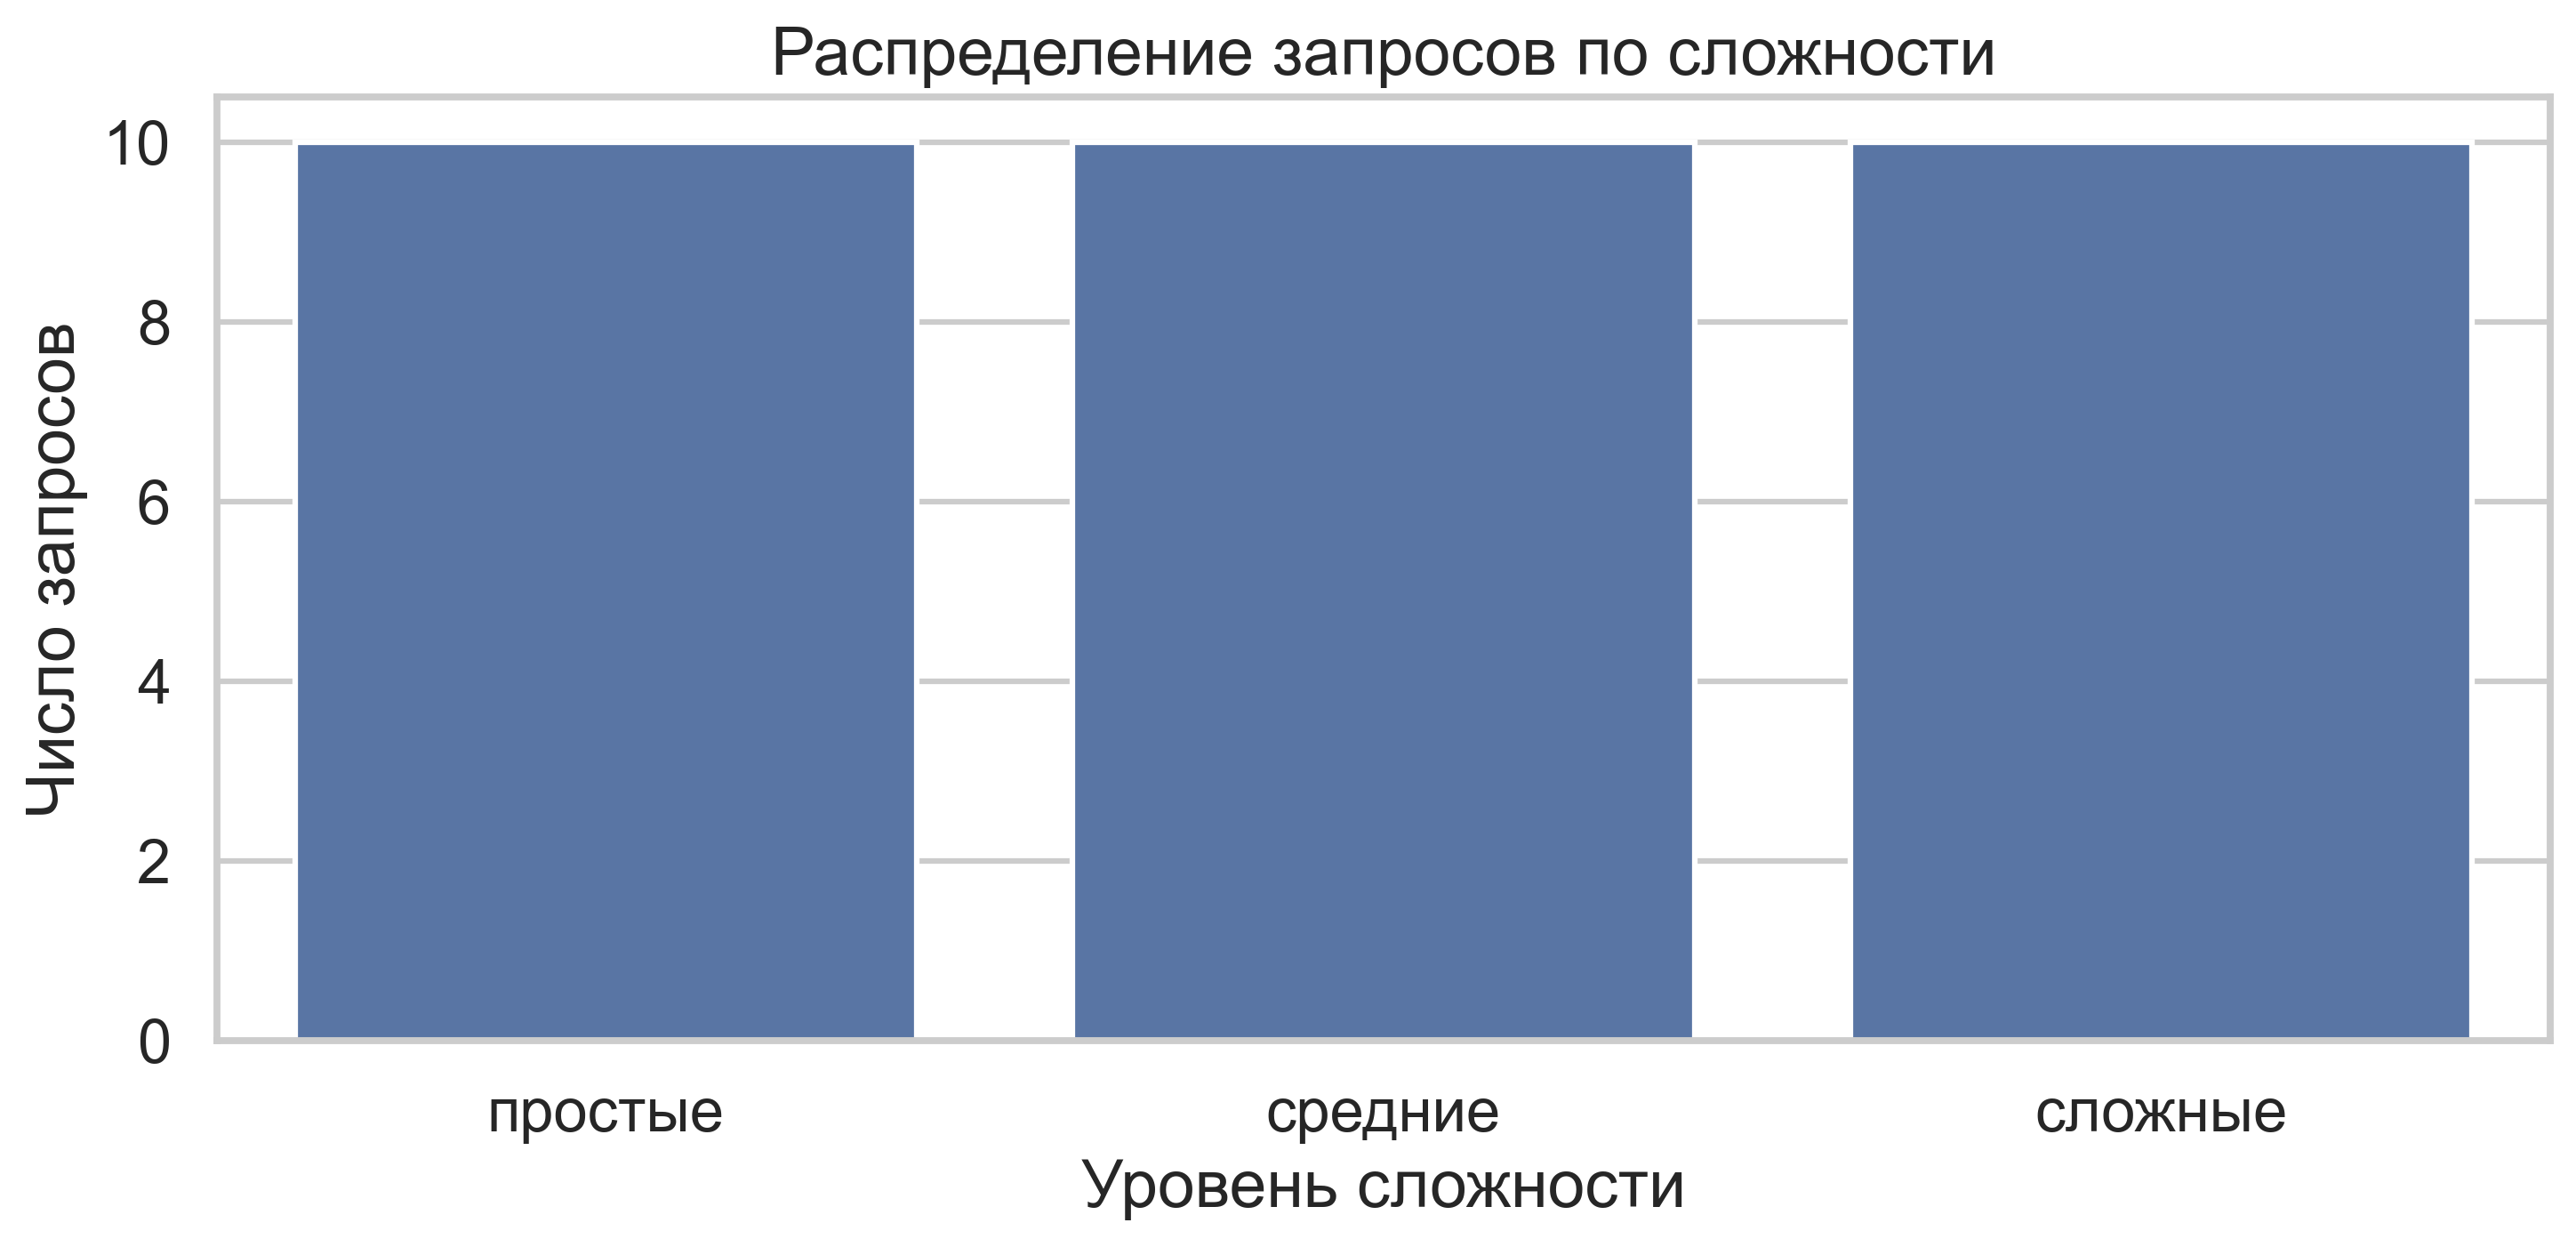

**Рисунок Б.2 — Распределение длины вопросов SEB**

> Источник: `results/nl2sql/synthetic_benchmark/figures/synthetic_analysis/seb_question_length_ru.png`

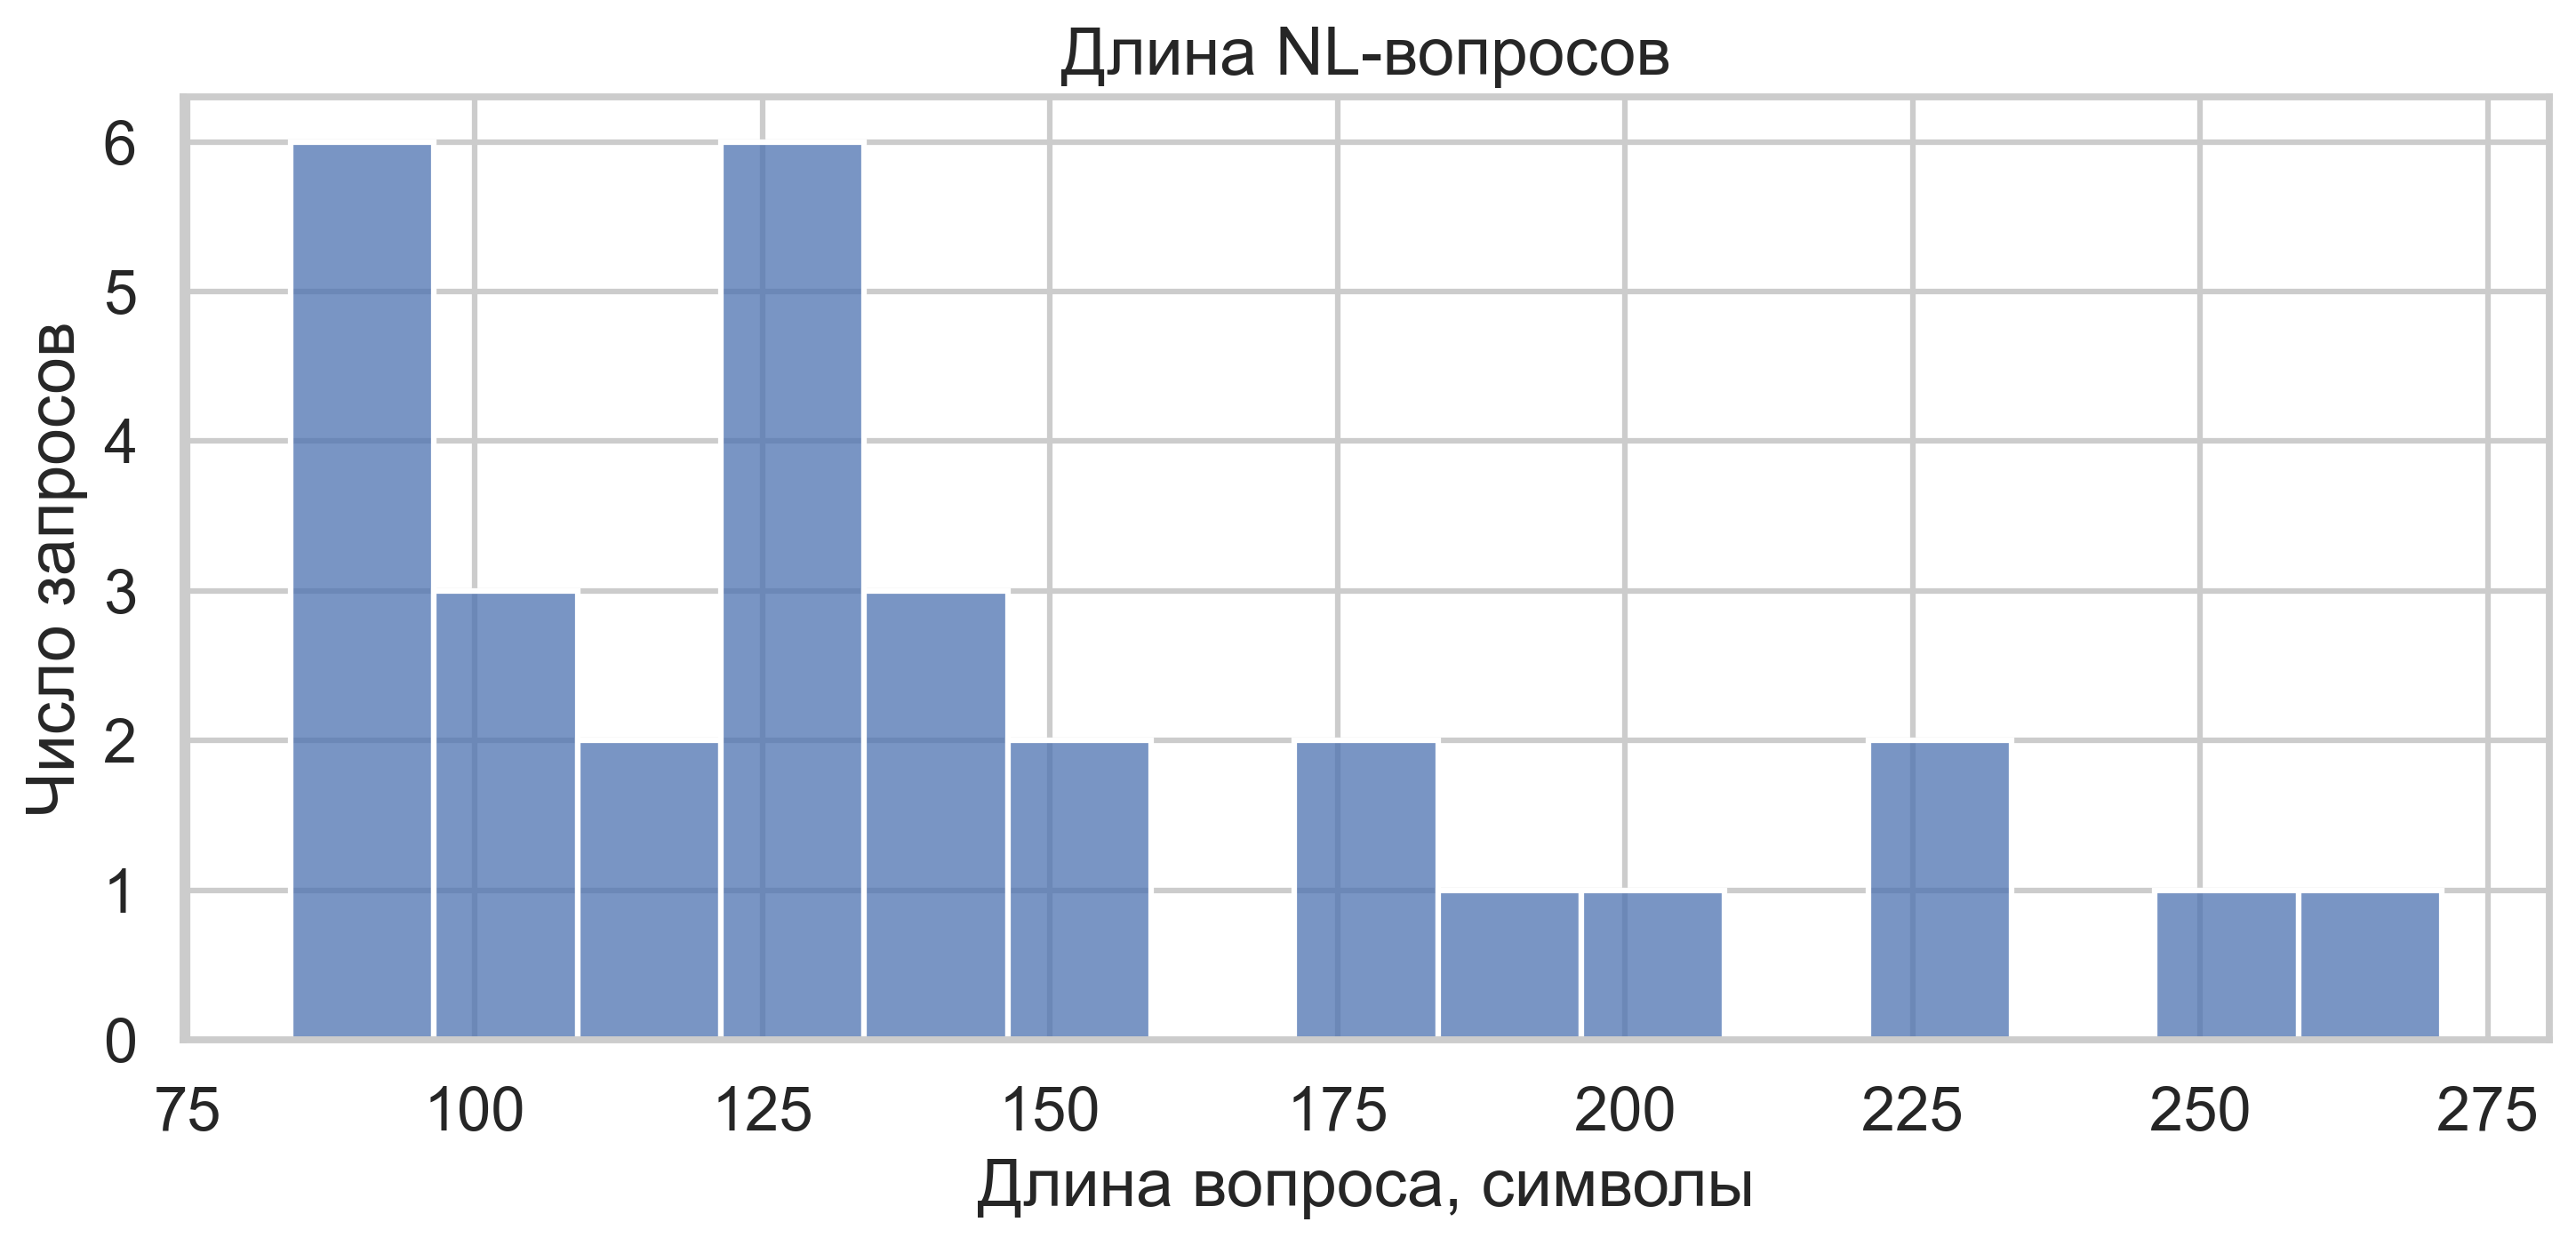

**Рисунок Б.3 — Распределение длины эталонных SQL-запросов SEB**

> Источник: `results/nl2sql/synthetic_benchmark/figures/synthetic_analysis/seb_gold_sql_length_ru.png`

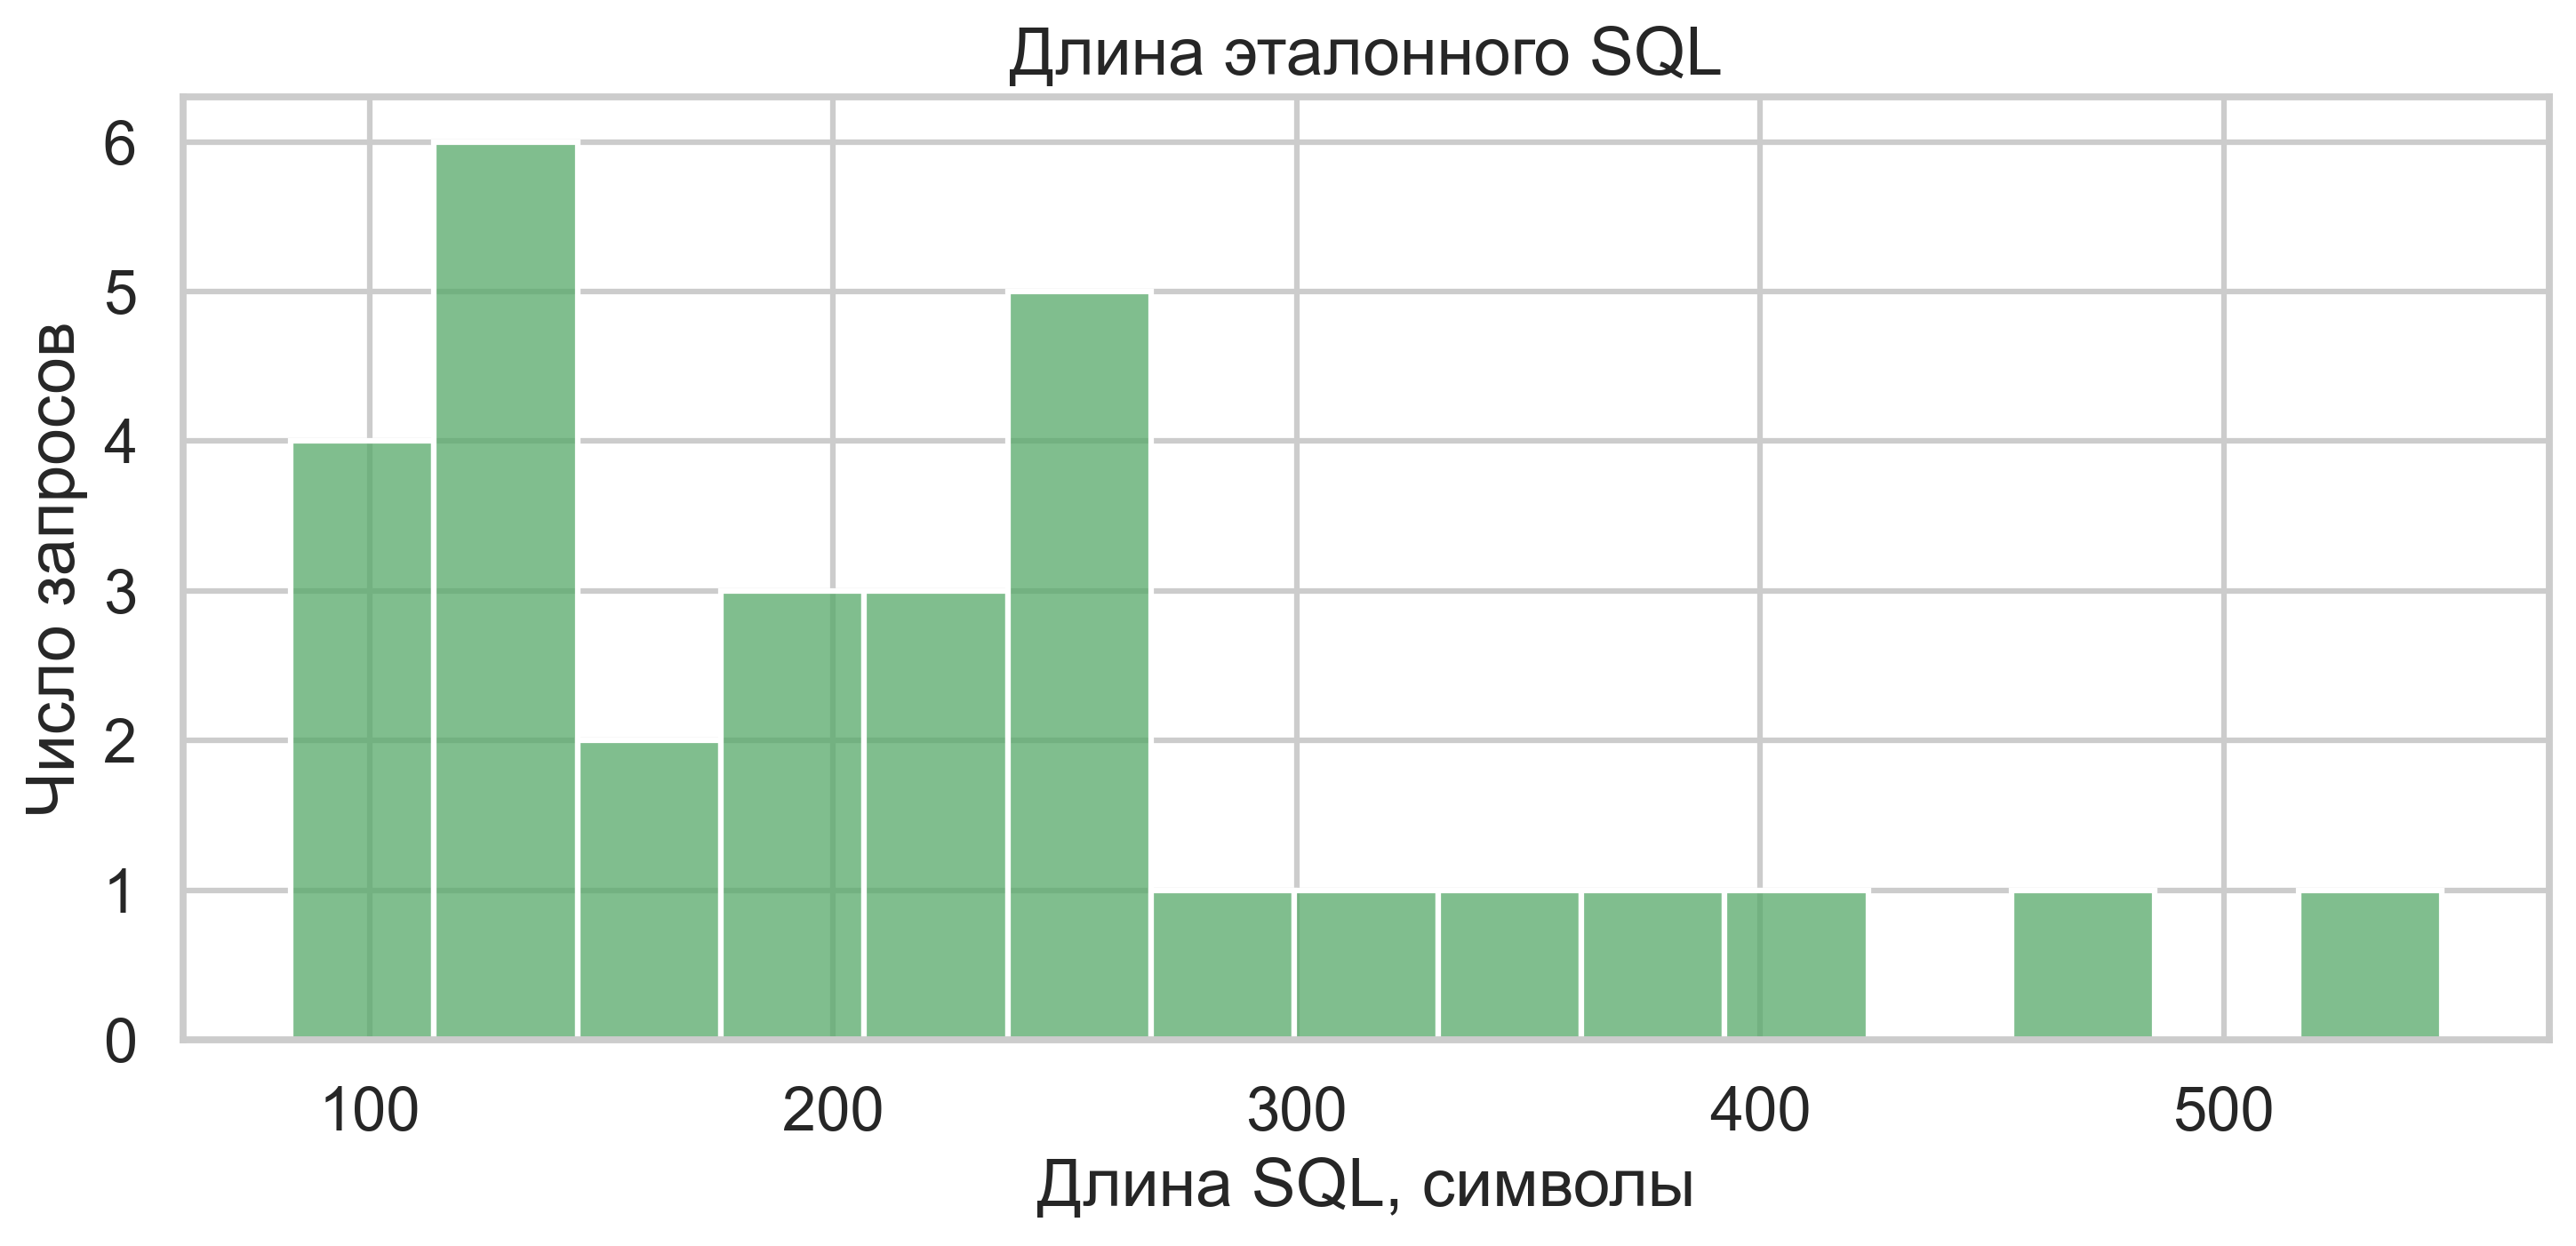

**Рисунок Б.4 — Execution Accuracy моделей на SEB**

> Источник: `results/nl2sql/synthetic_benchmark/figures/synthetic_analysis/seb_ea_overall_ru.png`

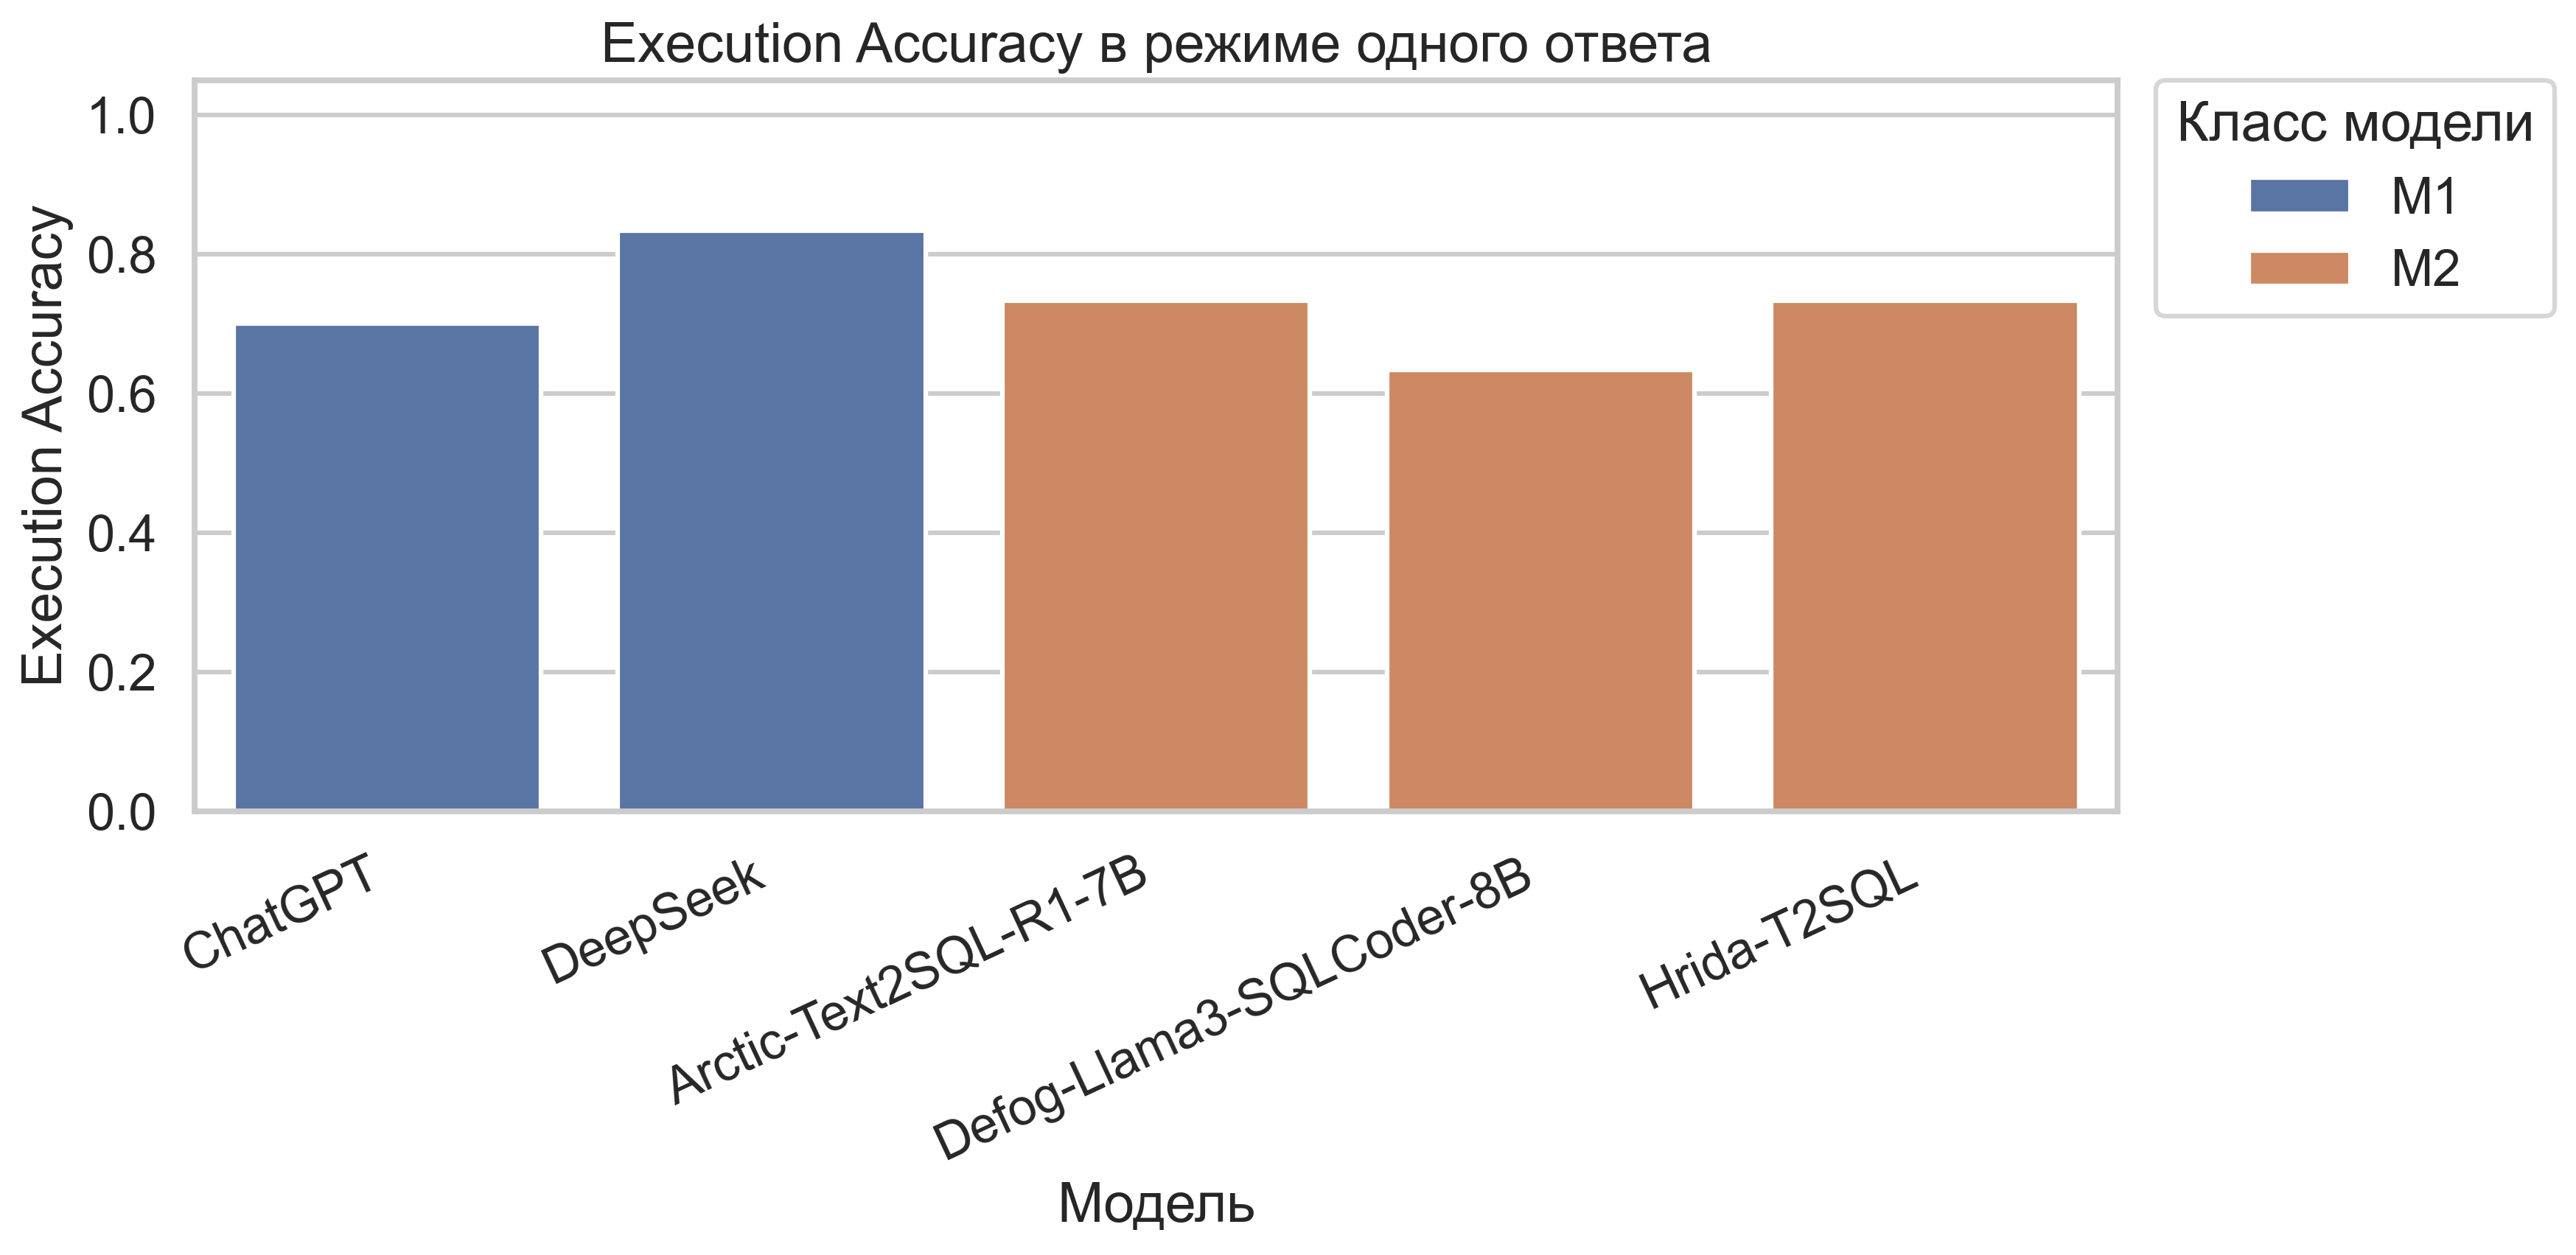

**Рисунок Б.5 — Execution Accuracy моделей SEB по сложности**

> Источник: `results/nl2sql/synthetic_benchmark/figures/synthetic_analysis/seb_ea_by_difficulty_ru.png`

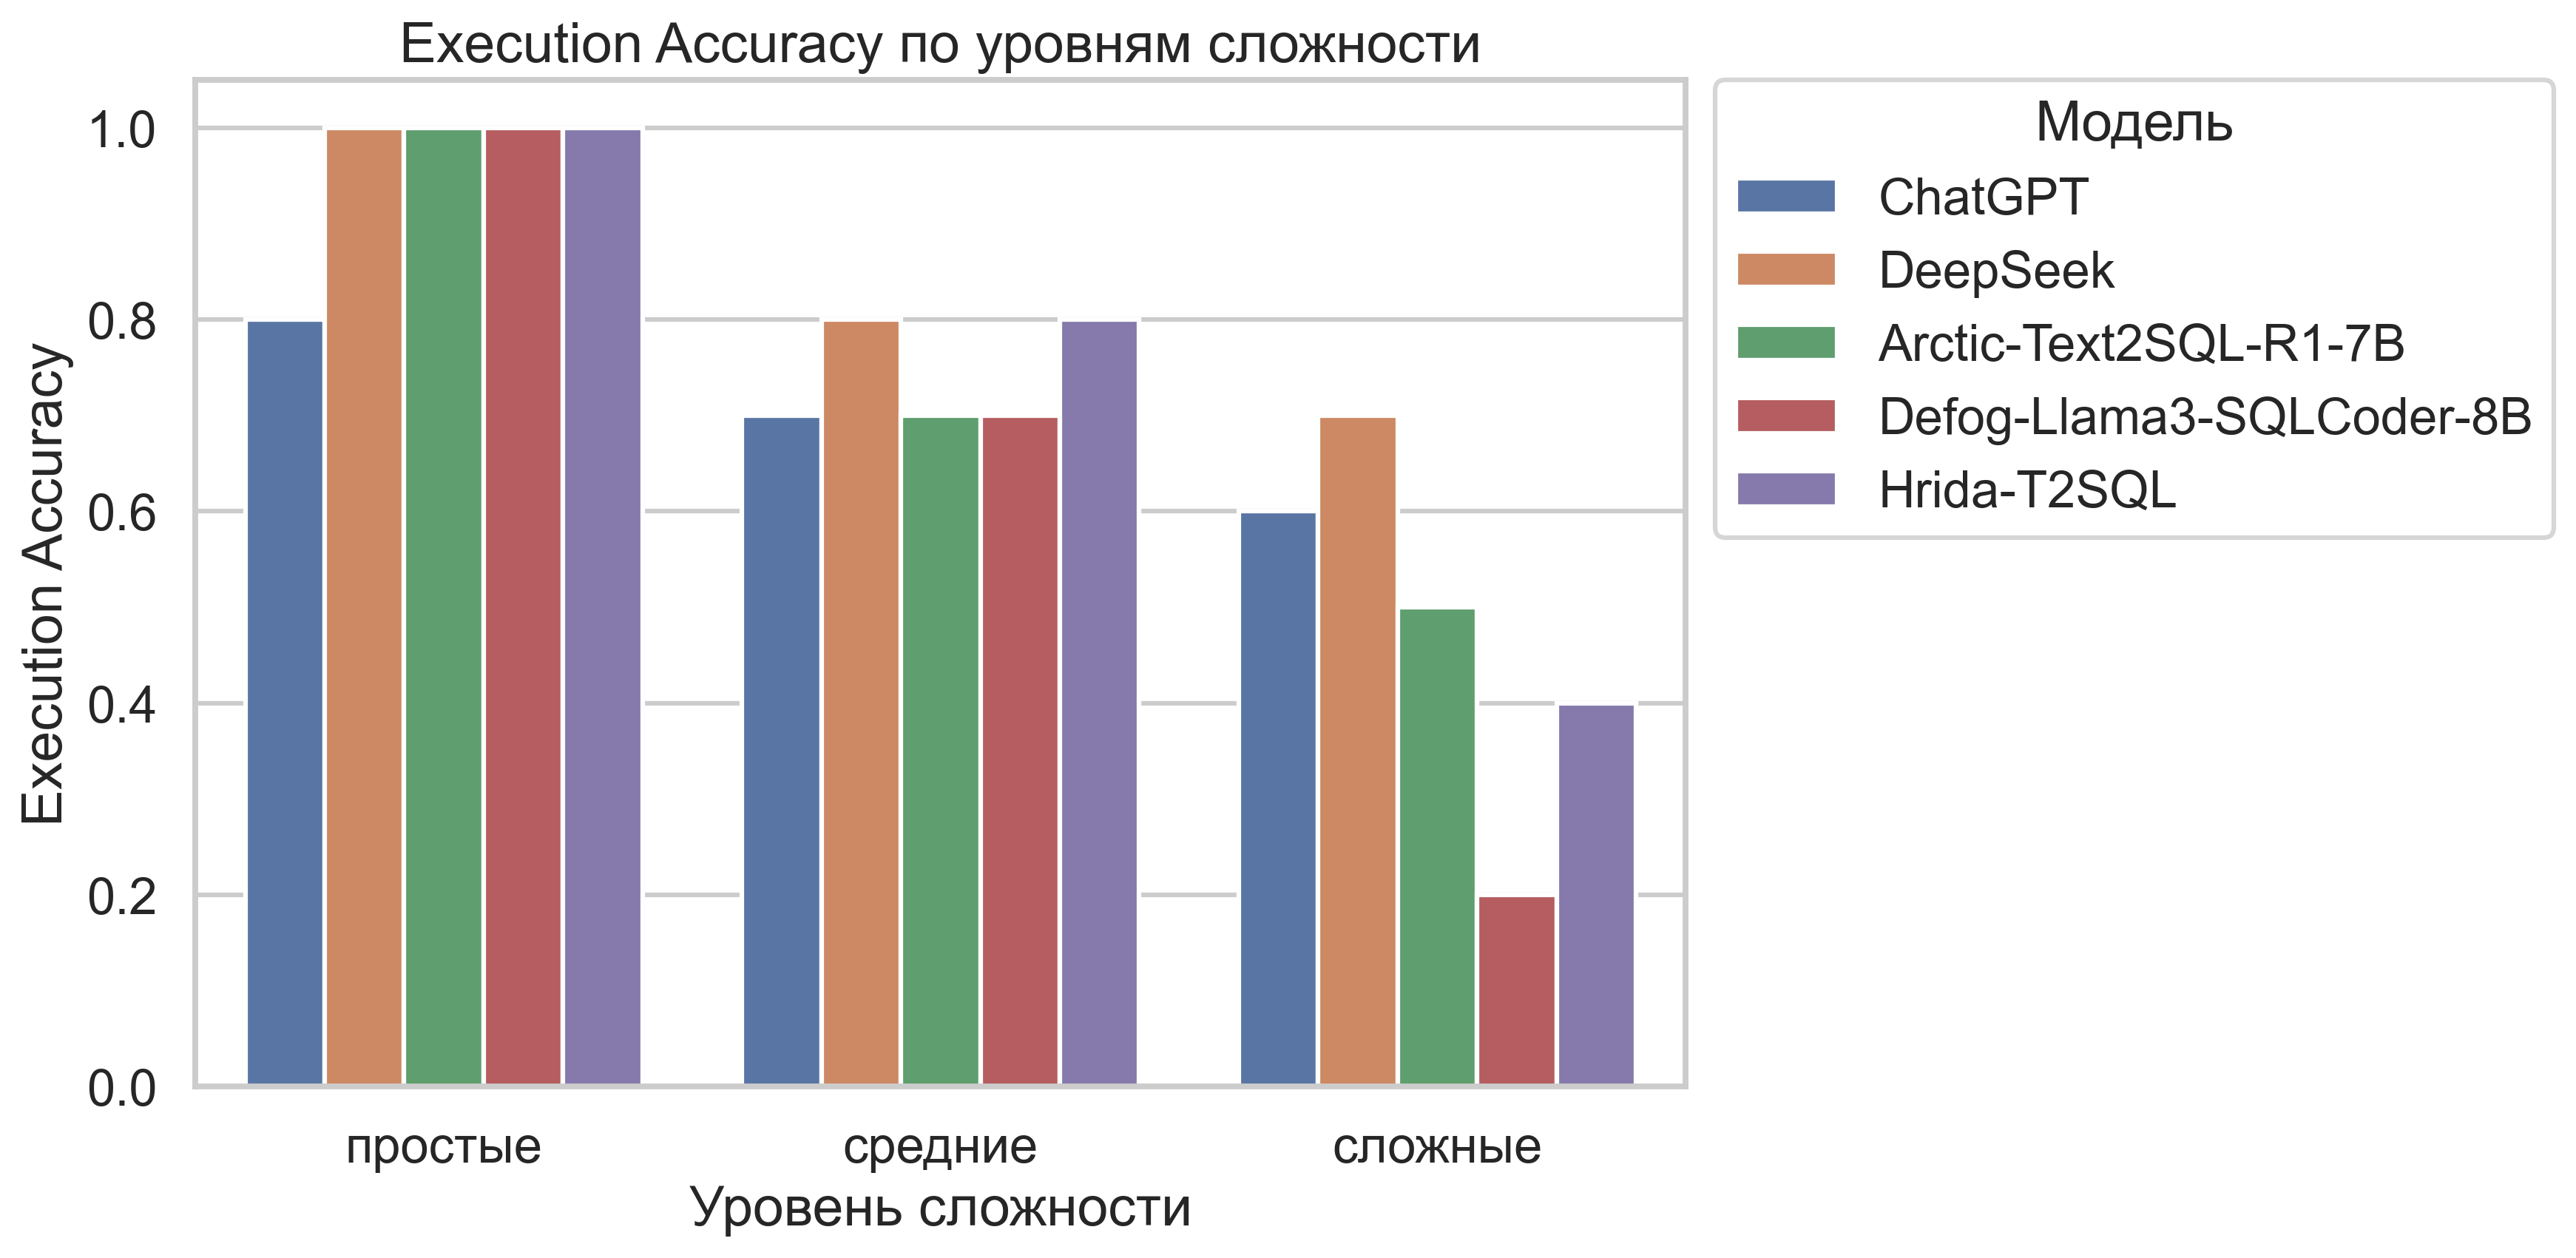

**Рисунок Б.6 — Тепловая карта EA по моделям и сложности SEB**

> Источник: `results/nl2sql/synthetic_benchmark/figures/synthetic_analysis/seb_ea_difficulty_heatmap_ru.png`

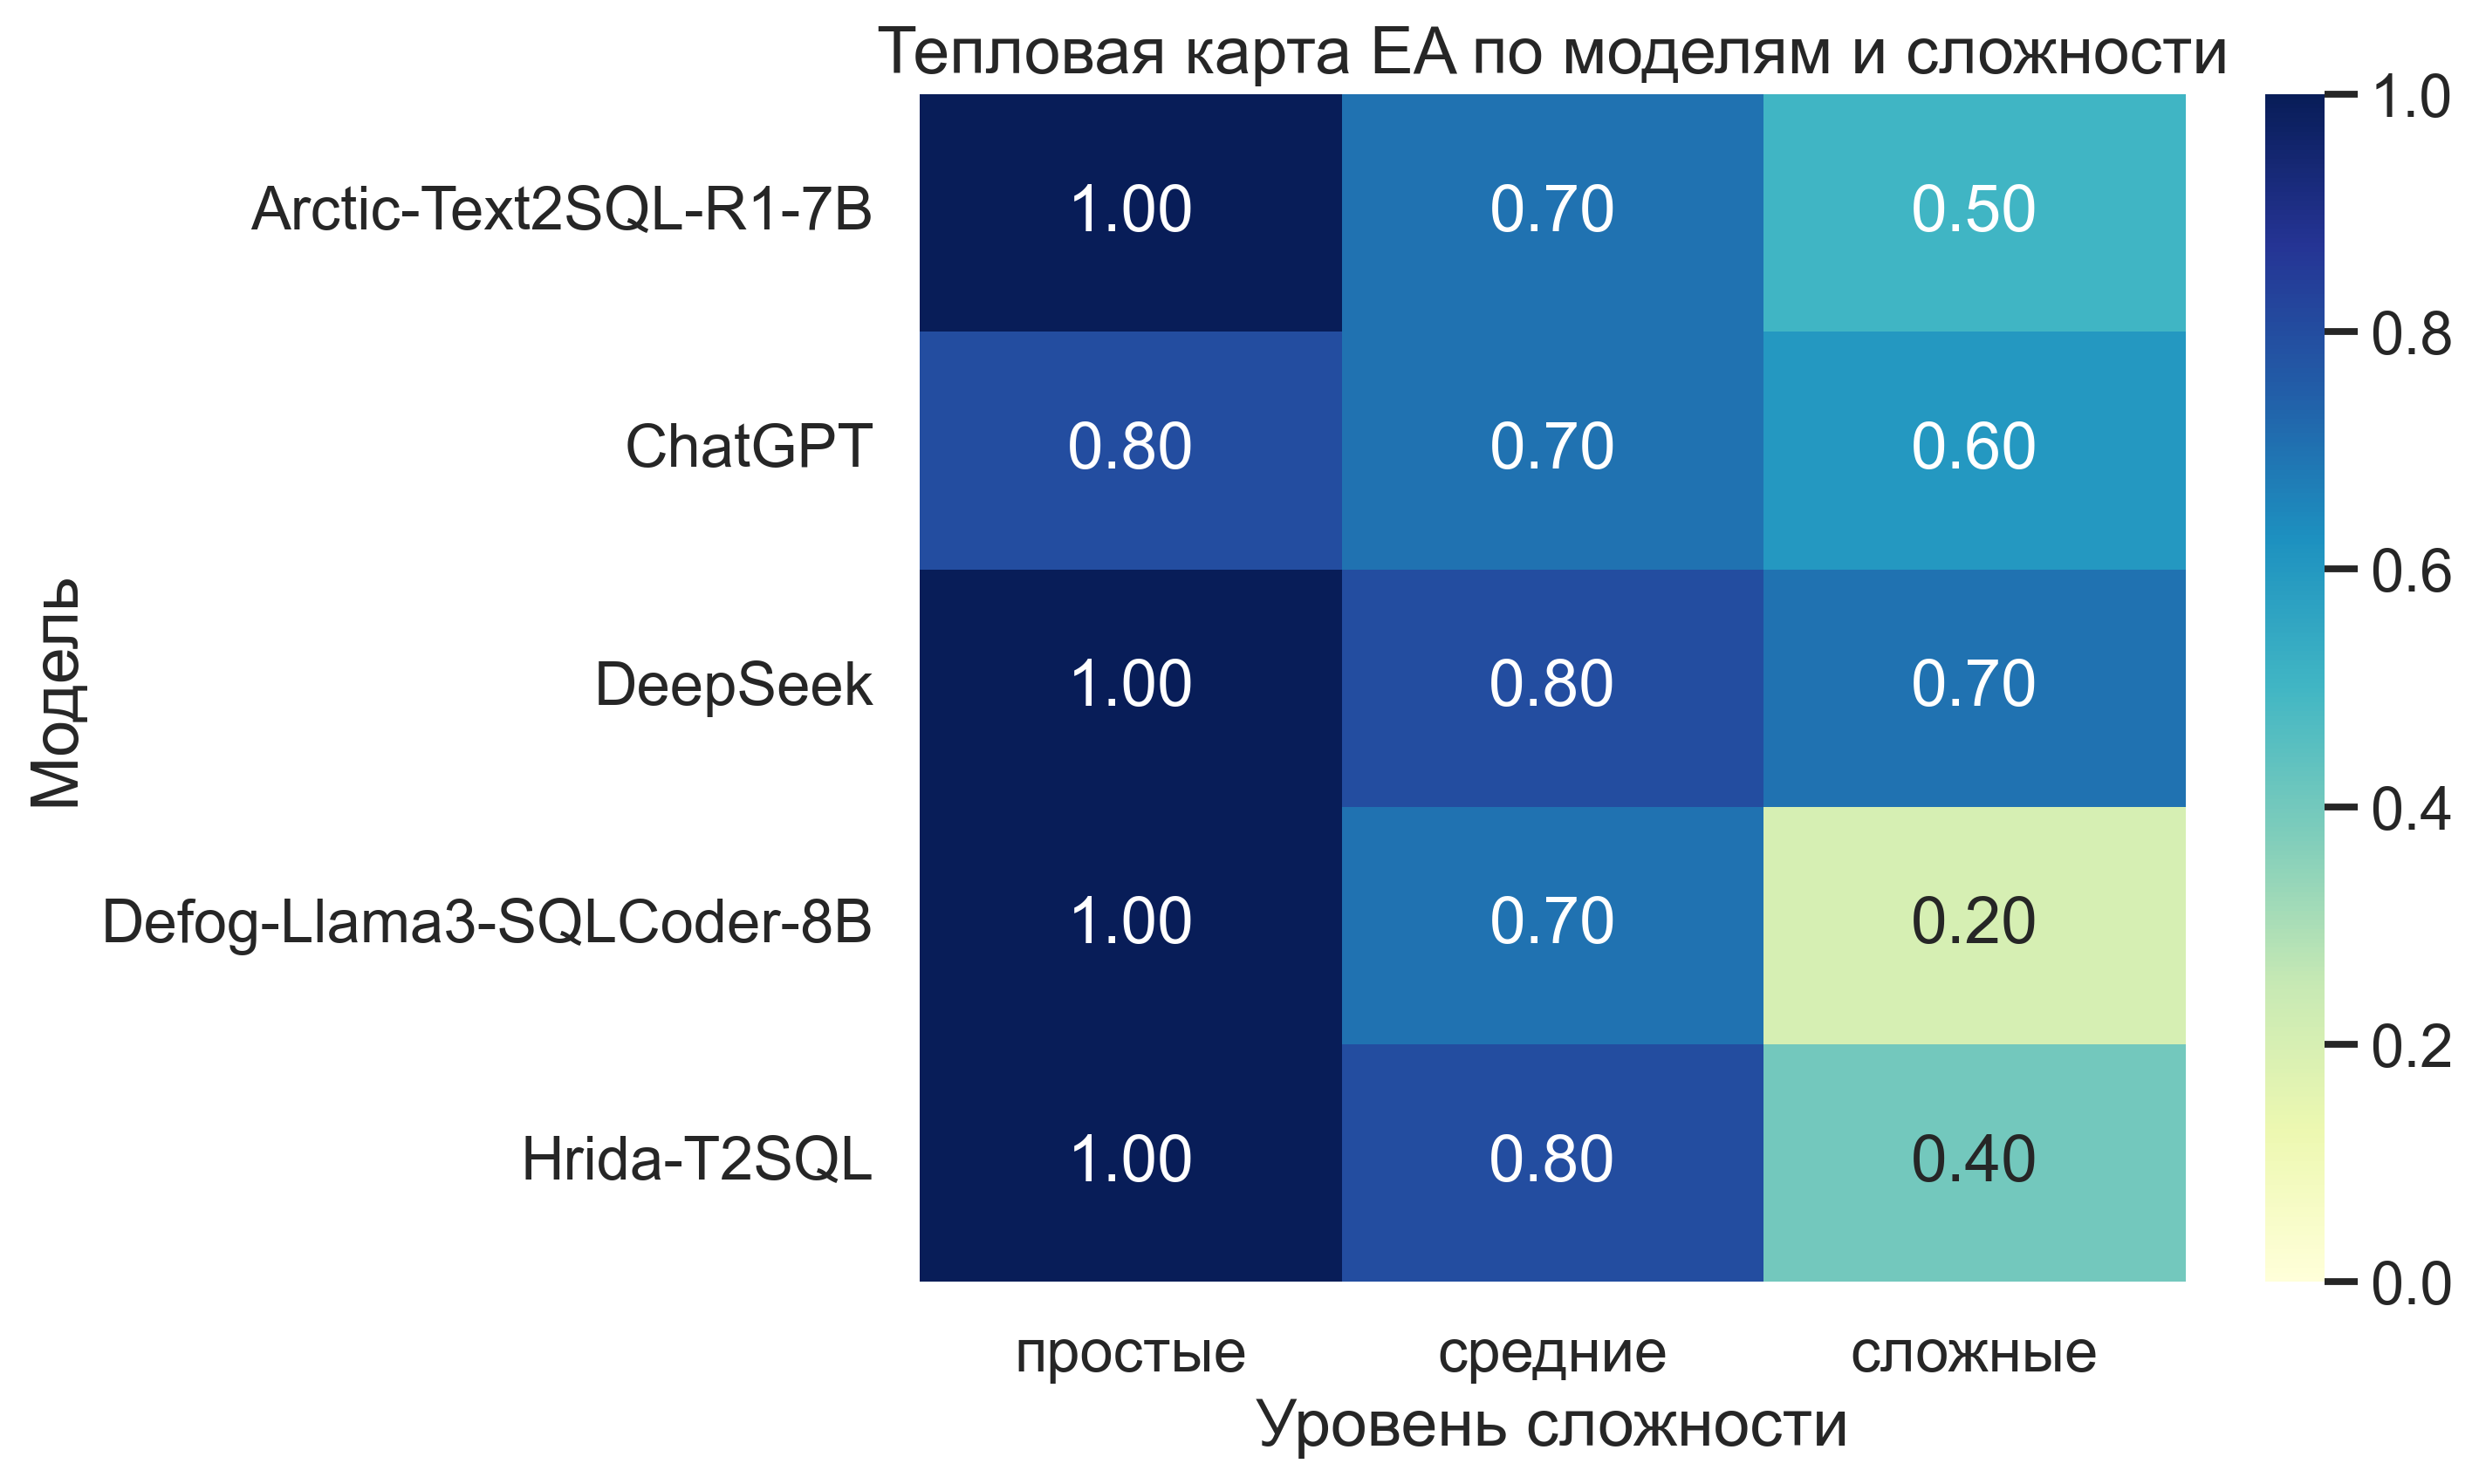

In [3]:
display_table('Таблица Б.1 — Файлы синтетического набора SEB', pd.DataFrame([
    {'Файл': 'dataset_v1.json', 'Назначение': 'Основная схема и ядро SQL-запросов.', 'Путь': rel(SEB_DIR / 'dataset_v1.json')},
    {'Файл': 'edge_cases_v1.json', 'Назначение': 'Дополнительные edge-case SQL-сценарии.', 'Путь': rel(SEB_DIR / 'edge_cases_v1.json')},
    {'Файл': 'seed.sql', 'Назначение': 'SQL-скрипт заполнения SQLite snapshot.', 'Путь': rel(SEB_DIR / 'seed.sql')},
    {'Файл': 'snapshot.sqlite', 'Назначение': 'Готовая исполняемая SQLite-база.', 'Путь': rel(SEB_DIR / 'snapshot.sqlite')},
    {'Файл': 'coverage_summary.json', 'Назначение': 'Сводка покрытия схемы, запросов и особенностей данных.', 'Путь': rel(SEB_DIR / 'coverage_summary.json')},
]))

row_counts_df = pd.DataFrame([{'Таблица': k, 'Количество строк': v} for k, v in coverage.get('row_counts', {}).items()])
display_table('Таблица Б.2 — Размер таблиц SEB', row_counts_df)

schema_rows = []
for item in dataset.get('schema', {}).get('tables', []):
    match = re.match(r'([^\(]+)\((.*)\)', item)
    schema_rows.append({'Таблица': match.group(1) if match else item, 'Описание колонок и ограничений': match.group(2) if match else ''})
display_table('Таблица Б.3 — Реляционная схема SEB', pd.DataFrame(schema_rows))

query_counts = coverage.get('query_counts', {})
display_table('Таблица Б.4 — Состав SQL-запросов SEB', pd.DataFrame([
    {'Группа': 'Основное ядро', 'Количество': query_counts.get('core')},
    {'Группа': 'Edge-case слой', 'Количество': query_counts.get('edge_case')},
    {'Группа': 'Всего', 'Количество': query_counts.get('total')},
]))

core_queries = pd.DataFrame(dataset.get('queries', []))
edge_queries = pd.DataFrame(edge_cases.get('queries', []))
if not core_queries.empty:
    difficulty_df = core_queries['difficulty'].map(DIFFICULTY_LABELS).fillna(core_queries['difficulty']).value_counts().rename_axis('Сложность').reset_index(name='Количество')
else:
    difficulty_df = pd.DataFrame()
display_table('Таблица Б.5 — Распределение core-запросов по сложности', difficulty_df)

edge_display_df = edge_queries.rename(columns={'difficulty': 'Сложность', 'group': 'Группа', 'edge_type': 'Тип edge-case', 'sql': 'SQL'}).copy()
if not edge_display_df.empty and 'Сложность' in edge_display_df.columns:
    edge_display_df['Сложность'] = edge_display_df['Сложность'].map(DIFFICULTY_LABELS).fillna(edge_display_df['Сложность'])
display_table('Таблица Б.6 — Edge-case SQL-сценарии', edge_display_df)

null_ratio_df = pd.DataFrame([
    {'Колонка': k, 'Доля NULL': v}
    for k, v in coverage.get('data_quality_summary', {}).get('null_ratio_by_column', {}).items()
    if v > 0
]).sort_values('Доля NULL', ascending=False)
display_table('Таблица Б.7 — Колонки SEB с ненулевой долей NULL', null_ratio_df, 4)

unusual_values_df = pd.DataFrame([{'Проверка': k, 'Количество': v} for k, v in coverage.get('data_quality_summary', {}).get('unusual_value_checks', {}).items()])
display_table('Таблица Б.8 — Контролируемые нестандартные значения SEB', unusual_values_df)

display_table('Таблица Б.9 — Покрытие пользовательских намерений SEB', pd.DataFrame([{'Пользовательское намерение': k, 'Количество запросов': v} for k, v in coverage.get('intent_distribution', {}).items()]))

table_usage_df = pd.DataFrame([{'Таблица': k, 'Количество использований': v} for k, v in coverage.get('table_usage', {}).items()]).sort_values('Количество использований', ascending=False)
display_table('Таблица Б.10 — Использование таблиц в SQL-запросах SEB', table_usage_df)

for title, fig in [
    ('Рисунок Б.1 — Распределение SQL-запросов SEB по сложности', RESULTS_DIR / 'synthetic_benchmark' / 'figures' / 'synthetic_analysis' / 'seb_dataset_difficulty_ru.png'),
    ('Рисунок Б.2 — Распределение длины вопросов SEB', RESULTS_DIR / 'synthetic_benchmark' / 'figures' / 'synthetic_analysis' / 'seb_question_length_ru.png'),
    ('Рисунок Б.3 — Распределение длины эталонных SQL-запросов SEB', RESULTS_DIR / 'synthetic_benchmark' / 'figures' / 'synthetic_analysis' / 'seb_gold_sql_length_ru.png'),
    ('Рисунок Б.4 — Execution Accuracy моделей на SEB', RESULTS_DIR / 'synthetic_benchmark' / 'figures' / 'synthetic_analysis' / 'seb_ea_overall_ru.png'),
    ('Рисунок Б.5 — Execution Accuracy моделей SEB по сложности', RESULTS_DIR / 'synthetic_benchmark' / 'figures' / 'synthetic_analysis' / 'seb_ea_by_difficulty_ru.png'),
    ('Рисунок Б.6 — Тепловая карта EA по моделям и сложности SEB', RESULTS_DIR / 'synthetic_benchmark' / 'figures' / 'synthetic_analysis' / 'seb_ea_difficulty_heatmap_ru.png'),
]:
    display_png(title, fig)


## Приложение В. Примеры результатов генерации SQL


In [4]:
def pick_example(df: pd.DataFrame, mask: pd.Series, preferred_sample_id: str | None = None) -> pd.Series | None:
    subset = df[mask].copy()
    if subset.empty:
        return None
    if preferred_sample_id and preferred_sample_id in set(subset['sample_id']):
        return subset[subset['sample_id'] == preferred_sample_id].iloc[0]
    return subset.sort_values([c for c in ['benchmark', 'model_display_name', 'sample_id'] if c in subset.columns]).iloc[0]


def render_sql_example(title: str, row: pd.Series | None, result_type: str) -> None:
    display(Markdown(f'**{title}**'))
    if row is None:
        show_note('Подходящий пример не найден в sample_metrics.csv.')
        return
    display(pd.DataFrame([{
        'Тип примера': result_type,
        'Бенчмарк': row.get('benchmark'),
        'Модель': row.get('model_display_name'),
        'sample_id': row.get('sample_id'),
        'Сложность': row.get('difficulty'),
        'Gold success': row.get('gold_success'),
        'Prediction success': row.get('first_pred_success'),
        'Hit': row.get('first_hit'),
        'Ошибка выполнения': row.get('first_pred_error'),
    }]).style.hide(axis='index'))
    md_text = (
        f"**Вопрос:** {row.get('question', '')}\n\n"
        f"**Evidence:** {row.get('evidence', '') if pd.notna(row.get('evidence', '')) else ''}\n\n"
        f"**Эталонный SQL:**\n```sql\n{row.get('gold_sql', '')}\n```\n\n"
        f"**Сгенерированный SQL:**\n```sql\n{row.get('first_pred_sql', '')}\n```"
    )
    display(Markdown(md_text))

examples_df = filter_main_models(ea_samples)
if examples_df.empty:
    show_note('Файл sample_metrics.csv отсутствует или пуст для основного корпуса моделей. Примеры генерации SQL не показаны.')
else:
    correct_row = pick_example(examples_df, examples_df['first_hit'].fillna(False).astype(bool), 'bird_0')
    exec_error_row = pick_example(examples_df, (~examples_df['first_pred_success'].fillna(False).astype(bool)) & examples_df['first_pred_error'].notna())
    wrong_executable_row = pick_example(examples_df, examples_df['first_pred_success'].fillna(False).astype(bool) & (~examples_df['first_hit'].fillna(False).astype(bool)))
    render_sql_example('В.1 — Корректная генерация', correct_row, 'Корректный результат')
    render_sql_example('В.2 — Ошибка выполнения SQL', exec_error_row, 'Ошибка выполнения')
    render_sql_example('В.3 — Исполнимый SQL с некорректным результатом', wrong_executable_row, 'Исполнимо, но неверный результат')


**В.1 — Корректная генерация**

Тип примера,Бенчмарк,Модель,sample_id,Сложность,Gold success,Prediction success,Hit,Ошибка выполнения
Корректный результат,bird,Arctic-Text2SQL-R1-7B,bird_0,simple,True,True,True,nan


**Вопрос:** What is the highest eligible free rate for K-12 students in the schools in Alameda County?

**Evidence:** Eligible free rate for K-12 = `Free Meal Count (K-12)` / `Enrollment (K-12)`

**Эталонный SQL:**
```sql
SELECT `Free Meal Count (K-12)` / `Enrollment (K-12)` FROM frpm WHERE `County Name` = 'Alameda' ORDER BY (CAST(`Free Meal Count (K-12)` AS REAL) / `Enrollment (K-12)`) DESC LIMIT 1
```

**Сгенерированный SQL:**
```sql
SELECT MAX(`Percent (%) Eligible Free (K-12)`) AS HighestEligibleFreeRate
FROM frpm
WHERE `County Name` = 'Alameda'
```

**В.2 — Ошибка выполнения SQL**

Тип примера,Бенчмарк,Модель,sample_id,Сложность,Gold success,Prediction success,Hit,Ошибка выполнения
Ошибка выполнения,bird,ChatGPT 5.2,bird_1013,simple,True,False,False,no such column: r.raceId


**Вопрос:** What is the lap record for the Austrian Grand Prix Circuit?

**Evidence:** lap record means the fastest time recorded which refers to time

**Эталонный SQL:**
```sql
WITH fastest_lap_times AS ( SELECT T1.raceId, T1.fastestLapTime FROM results AS T1 WHERE T1.FastestLapTime IS NOT NULL) SELECT MIN(fastest_lap_times.fastestLapTime) as lap_record FROM fastest_lap_times INNER JOIN races AS T2 on fastest_lap_times.raceId = T2.raceId INNER JOIN circuits AS T3 on T2.circuitId = T3.circuitId WHERE T2.name = 'Austrian Grand Prix'
```

**Сгенерированный SQL:**
```sql
SELECT r.raceId, ra.year, ra.name AS raceName, c.name AS circuitName, d.forename || ' ' || d.surname AS driverName, res.fastestLapTime AS lapRecord, res.fastestLapSpeed, res.fastestLap AS lapNumber FROM results res JOIN races ra ON ra.raceId = res.raceId JOIN circuits c ON c.circuitId = ra.circuitId JOIN drivers d ON d.driverId = res.driverId JOIN status s ON s.statusId = res.statusId WHERE ra.name = 'Austrian Grand Prix' AND res.fastestLapTime IS NOT NULL ORDER BY res.fastestLapTime ASC LIMIT 1
```

**В.3 — Исполнимый SQL с некорректным результатом**

Тип примера,Бенчмарк,Модель,sample_id,Сложность,Gold success,Prediction success,Hit,Ошибка выполнения
"Исполнимо, но неверный результат",bird,ChatGPT 5.2,bird_1,moderate,True,True,False,nan


**Вопрос:** Please list the lowest three eligible free rates for students aged 5-17 in continuation schools.

**Evidence:** Eligible free rates for students aged 5-17 = `Free Meal Count (Ages 5-17)` / `Enrollment (Ages 5-17)`

**Эталонный SQL:**
```sql
SELECT `Free Meal Count (Ages 5-17)` / `Enrollment (Ages 5-17)` FROM frpm WHERE `Educational Option Type` = 'Continuation School' AND `Free Meal Count (Ages 5-17)` / `Enrollment (Ages 5-17)` IS NOT NULL ORDER BY `Free Meal Count (Ages 5-17)` / `Enrollment (Ages 5-17)` ASC LIMIT 3
```

**Сгенерированный SQL:**
```sql
SELECT `School Name`, `District Name`, `County Name`, `Percent (%) Eligible Free (Ages 5-17)` AS eligible_free_rate_5_17 FROM frpm WHERE `School Type` = 'Continuation High Schools' AND `Percent (%) Eligible Free (Ages 5-17)` IS NOT NULL ORDER BY `Percent (%) Eligible Free (Ages 5-17)` ASC LIMIT 3
```

## Приложение Г. Дополнительные материалы по режиму Pass@K

В приложении `Pass@K` приводится отдельно от графиков `EA` в режиме одного ответа. Диаграммы показывают зависимость качества от числа попыток генерации и эффект нескольких кандидатов на SEB. Старые сгруппированные столбчатые диаграммы, где `EA`, `pass@1`, `pass@3` и `pass@5` отображались как равноправные категории, больше не используются.


### Материалы для ПРИЛОЖЕНИЯ Г: Pass@K

**Таблица Г.1 — Агрегированные значения Pass@K по моделям и наборам данных**

Модель,Бенчмарк,N,Execution Accuracy,Pass@1,Pass@3,Pass@5,"Время инференса, мс",Токены,"Стоимость, $"
ChatGPT 5.2,bird,1534,0.286800,0.287500,0.352400,0.373500,2186.995100,1020.665300,0.001900
DeepSeek V3.2,bird,1534,0.317500,0.320100,0.348200,0.361100,2950.705600,1051.619200,0.000300
Arctic-Text2SQL-R1-7B,bird,1534,0.213200,0.211600,0.225300,0.234700,1937.288300,1071.072200,0.000000
Defog-Llama3-SQLCoder-8B q4_0,bird,1534,0.125800,0.127900,0.145600,0.157100,1625.685300,1010.058300,0.000000
Hrida-T2SQL q8_0,bird,1534,0.037800,0.034200,0.037500,0.040400,1344.523100,1403.713800,0.000000
ChatGPT 5.2,spider,1034,0.741800,0.742400,0.763700,0.771800,1988.885600,479.015700,0.000900
DeepSeek V3.2,spider,1034,0.737900,0.739500,0.761900,0.769800,2284.473900,514.880300,0.000100
Arctic-Text2SQL-R1-7B,spider,1034,0.552200,0.553800,0.575000,0.589000,1494.257000,554.780100,0.000000
Defog-Llama3-SQLCoder-8B q4_0,spider,1034,0.432300,0.430000,0.468300,0.494200,1235.264300,483.047600,0.000000
Hrida-T2SQL q8_0,spider,1034,0.341400,0.346800,0.365600,0.377200,704.045000,720.338300,0.000000


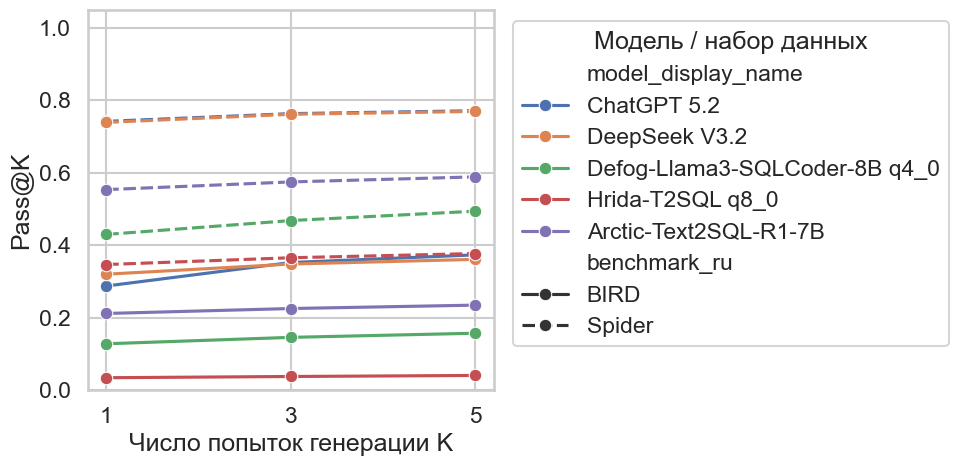

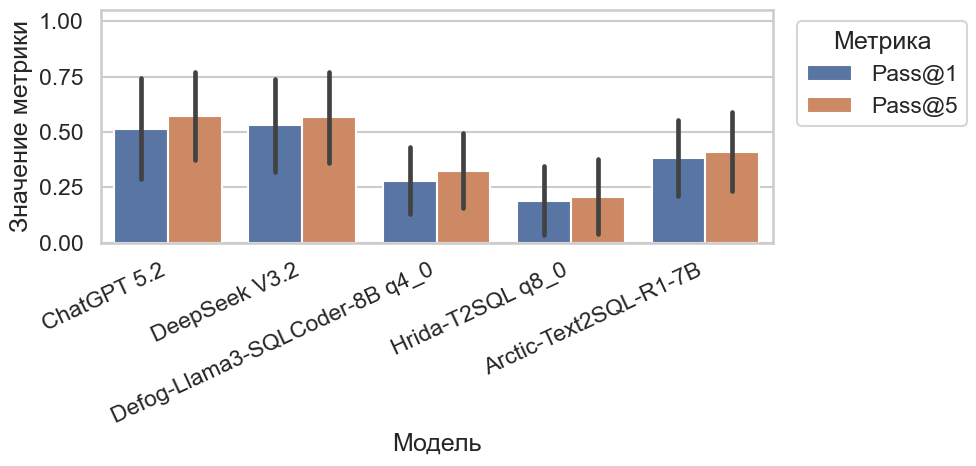

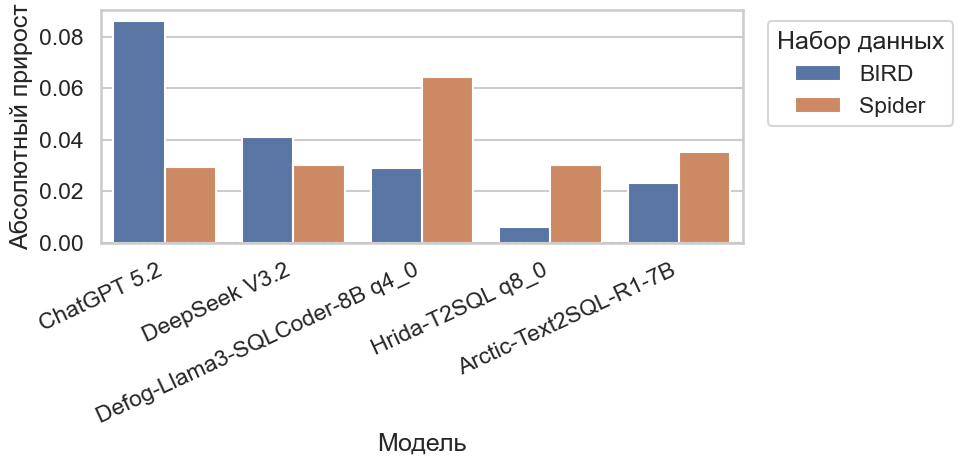

**Таблица Г.2 — Значения Pass@K по уровням сложности**

Модель,Бенчмарк,Сложность,K,Pass@K
Arctic-Text2SQL-R1-7B,BIRD,простые,1,0.299500
Arctic-Text2SQL-R1-7B,BIRD,простые,3,0.325400
Arctic-Text2SQL-R1-7B,BIRD,простые,5,0.325400
ChatGPT 5.2,BIRD,простые,1,0.361100
ChatGPT 5.2,BIRD,простые,3,0.428100
ChatGPT 5.2,BIRD,простые,5,0.450800
DeepSeek V3.2,BIRD,простые,1,0.394600
DeepSeek V3.2,BIRD,простые,3,0.420500
DeepSeek V3.2,BIRD,простые,5,0.440000
Defog-Llama3-SQLCoder-8B q4_0,BIRD,простые,1,0.187000


**Рисунок Г.4 — Время инференса в режиме Pass@K**

> Источник: `reports/appendix_assets/appendix_g_fig_4_passk_latency.png`

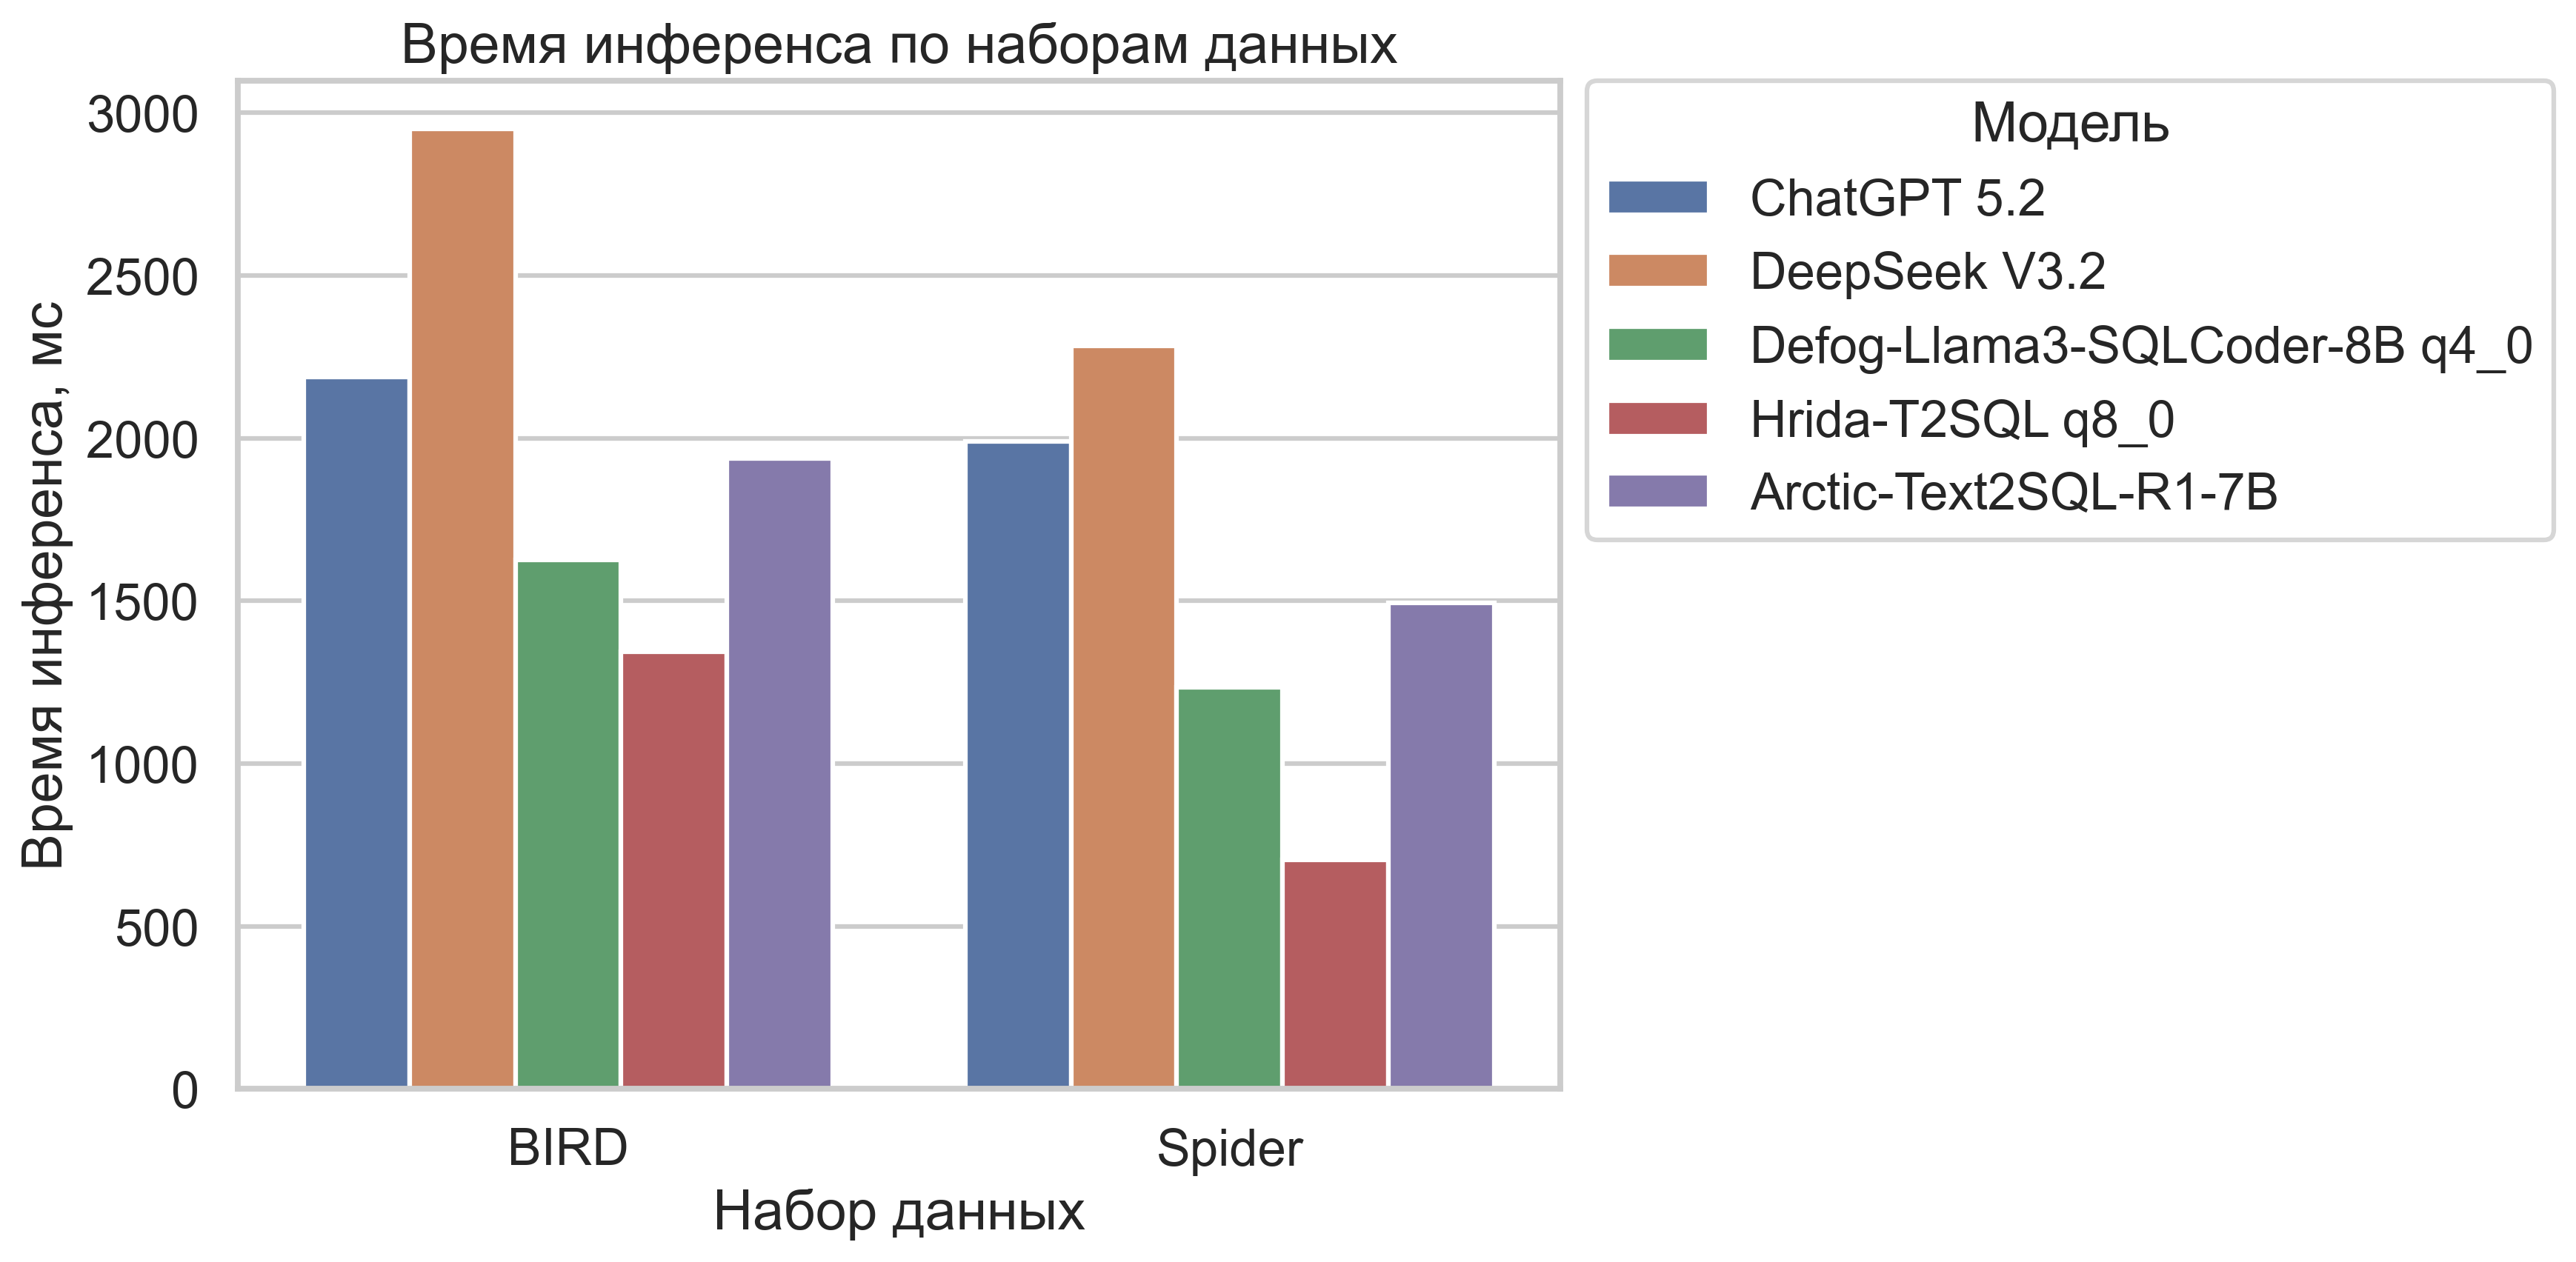

**Рисунок Г.5 — Парные различия качества в режиме Pass@K**

> Источник: `reports/appendix_assets/appendix_g_fig_5_passk_pairwise_delta.png`

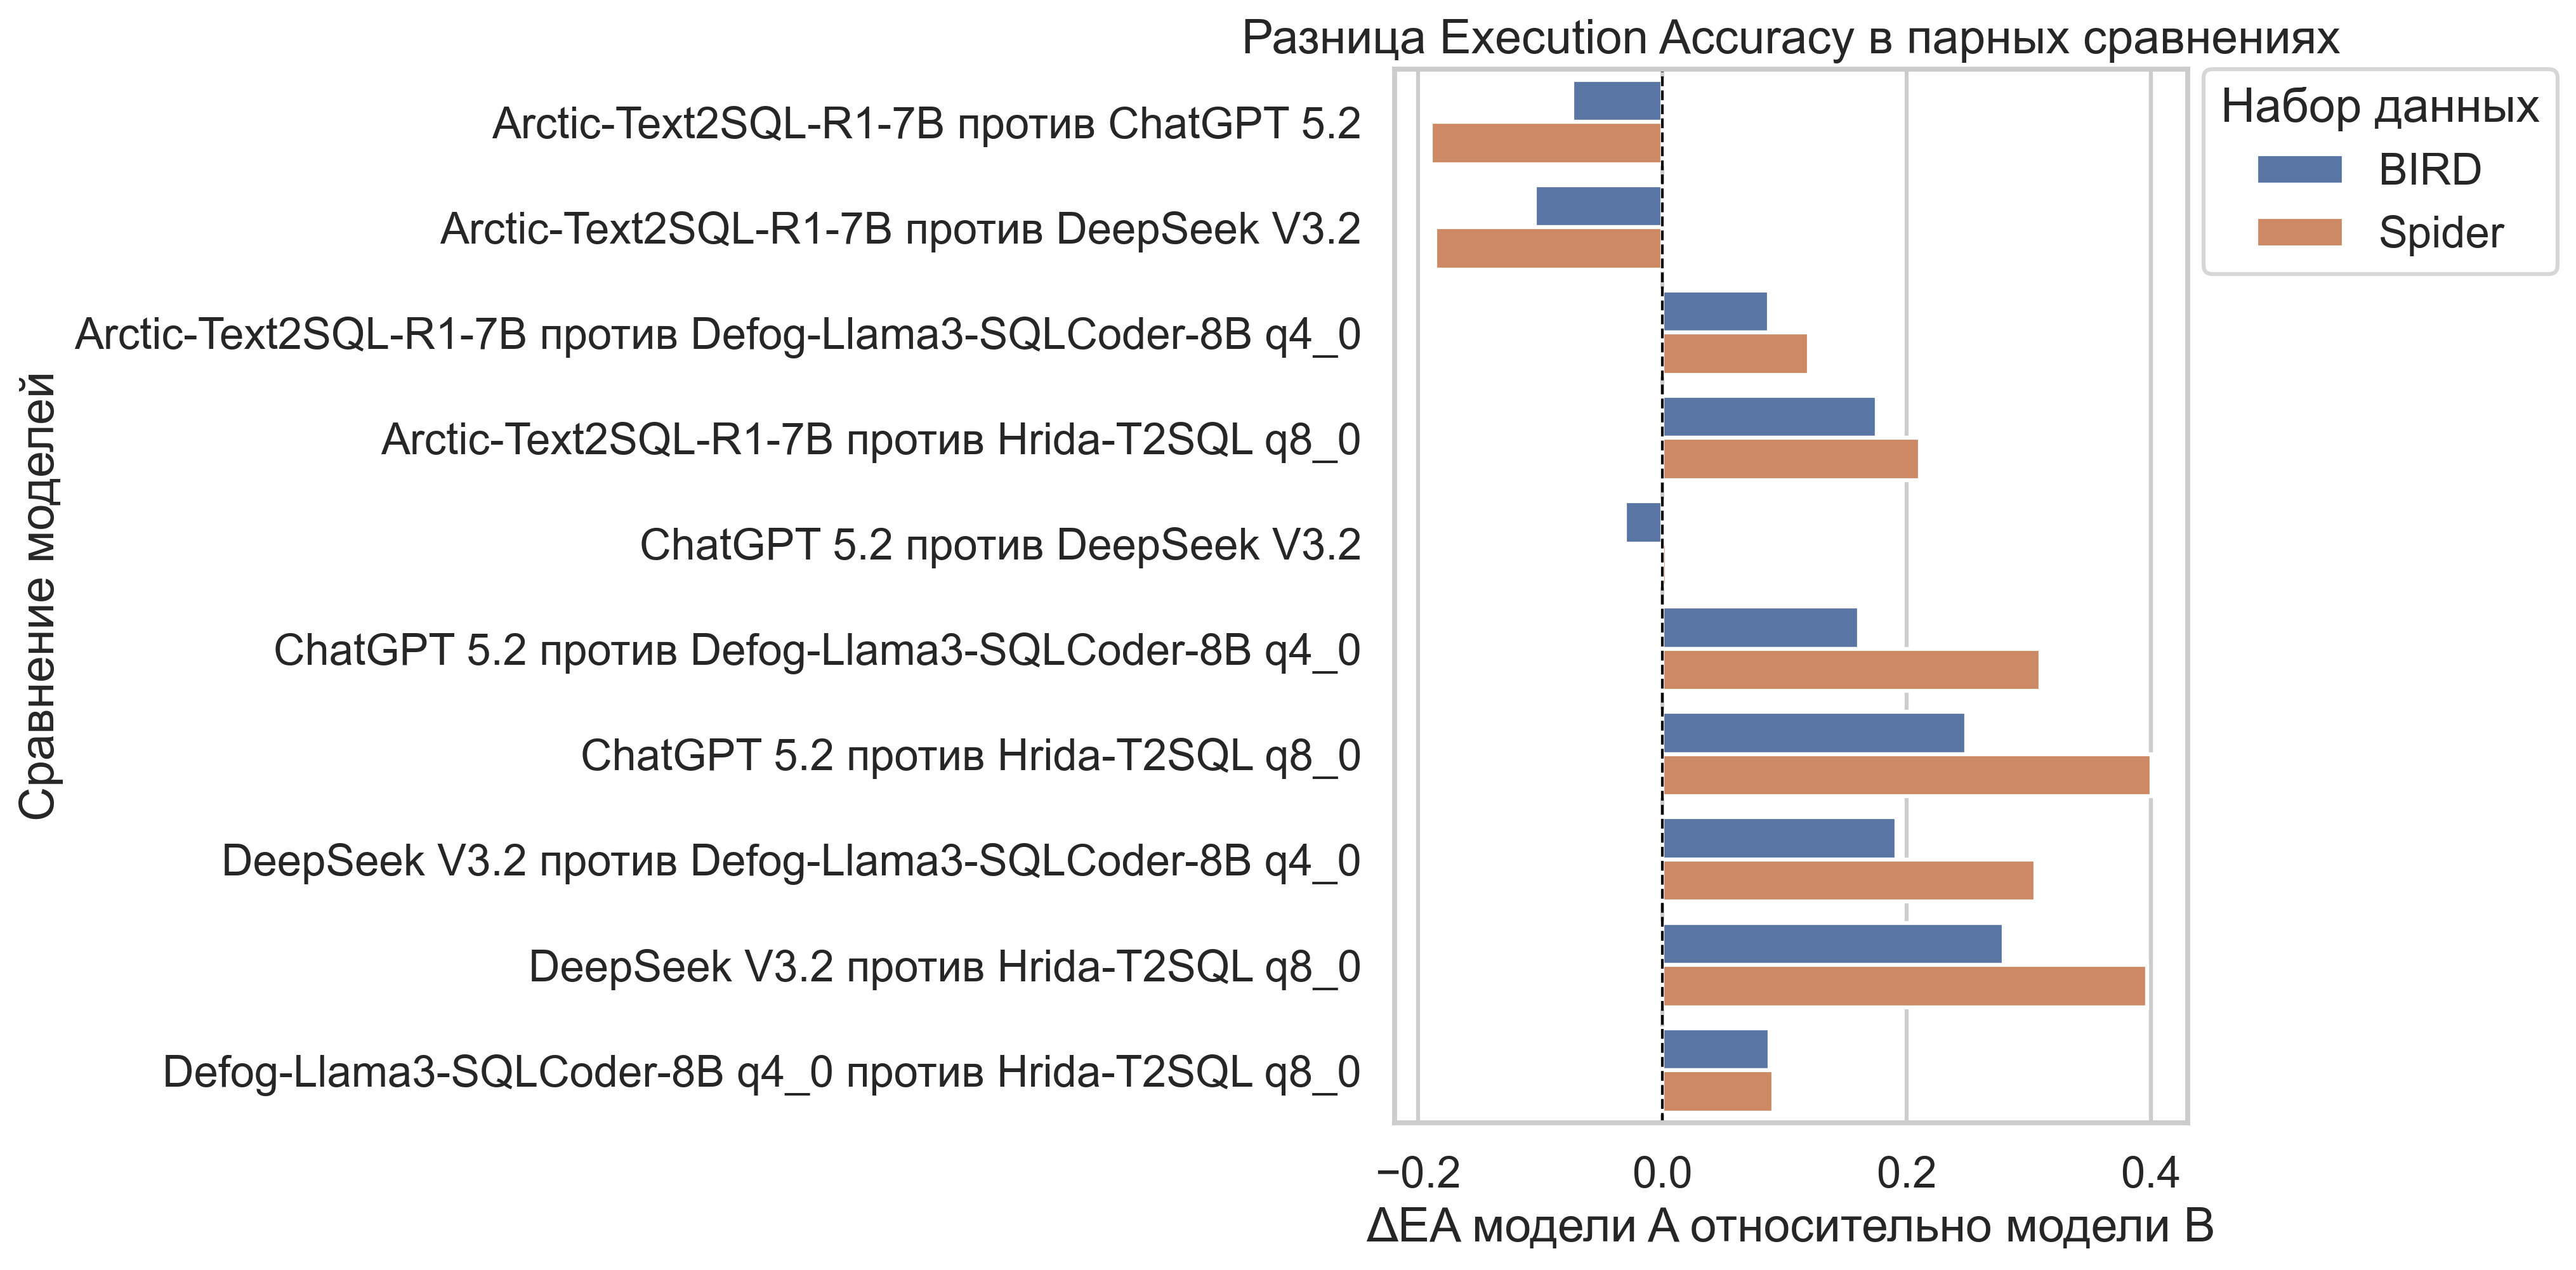

**Рисунок Г.6 — Pass@K и прирост Pass@5 относительно EA в SEB**

> Источник: `reports/appendix_assets/appendix_g_fig_6_seb_passk_and_gain.png`

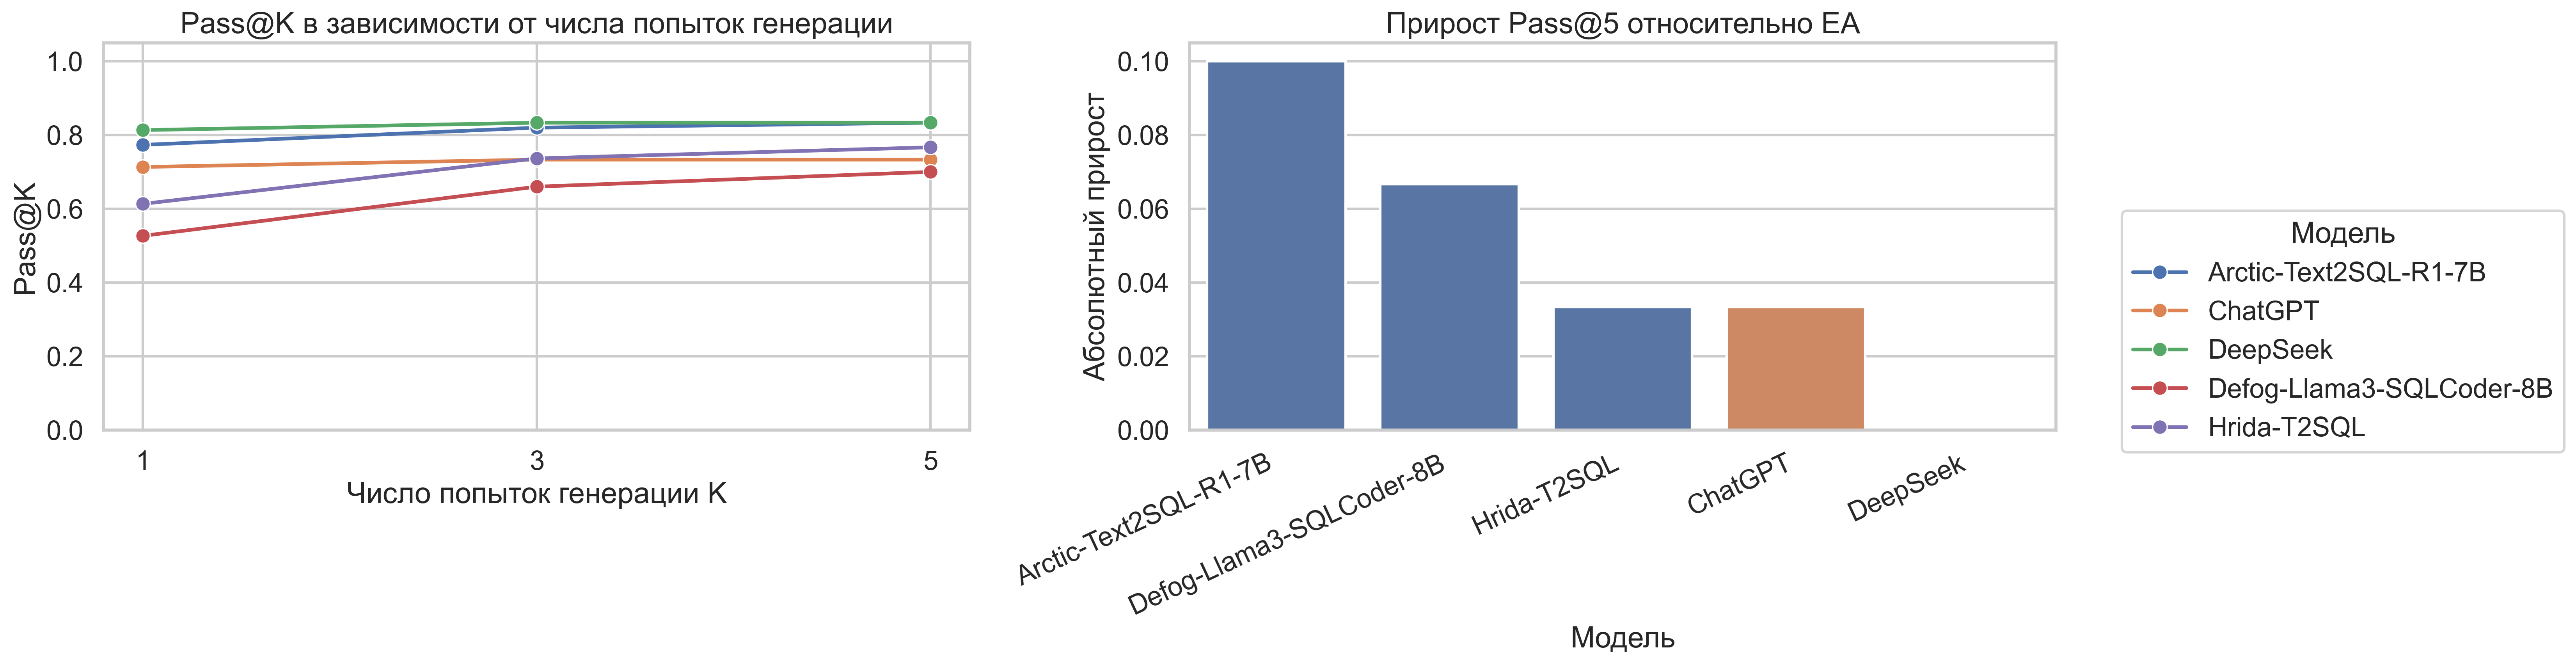

**Рисунок Г.7 — Pass@K по уровням сложности SEB**

> Источник: `reports/appendix_assets/appendix_g_fig_7_seb_passk_by_difficulty.png`

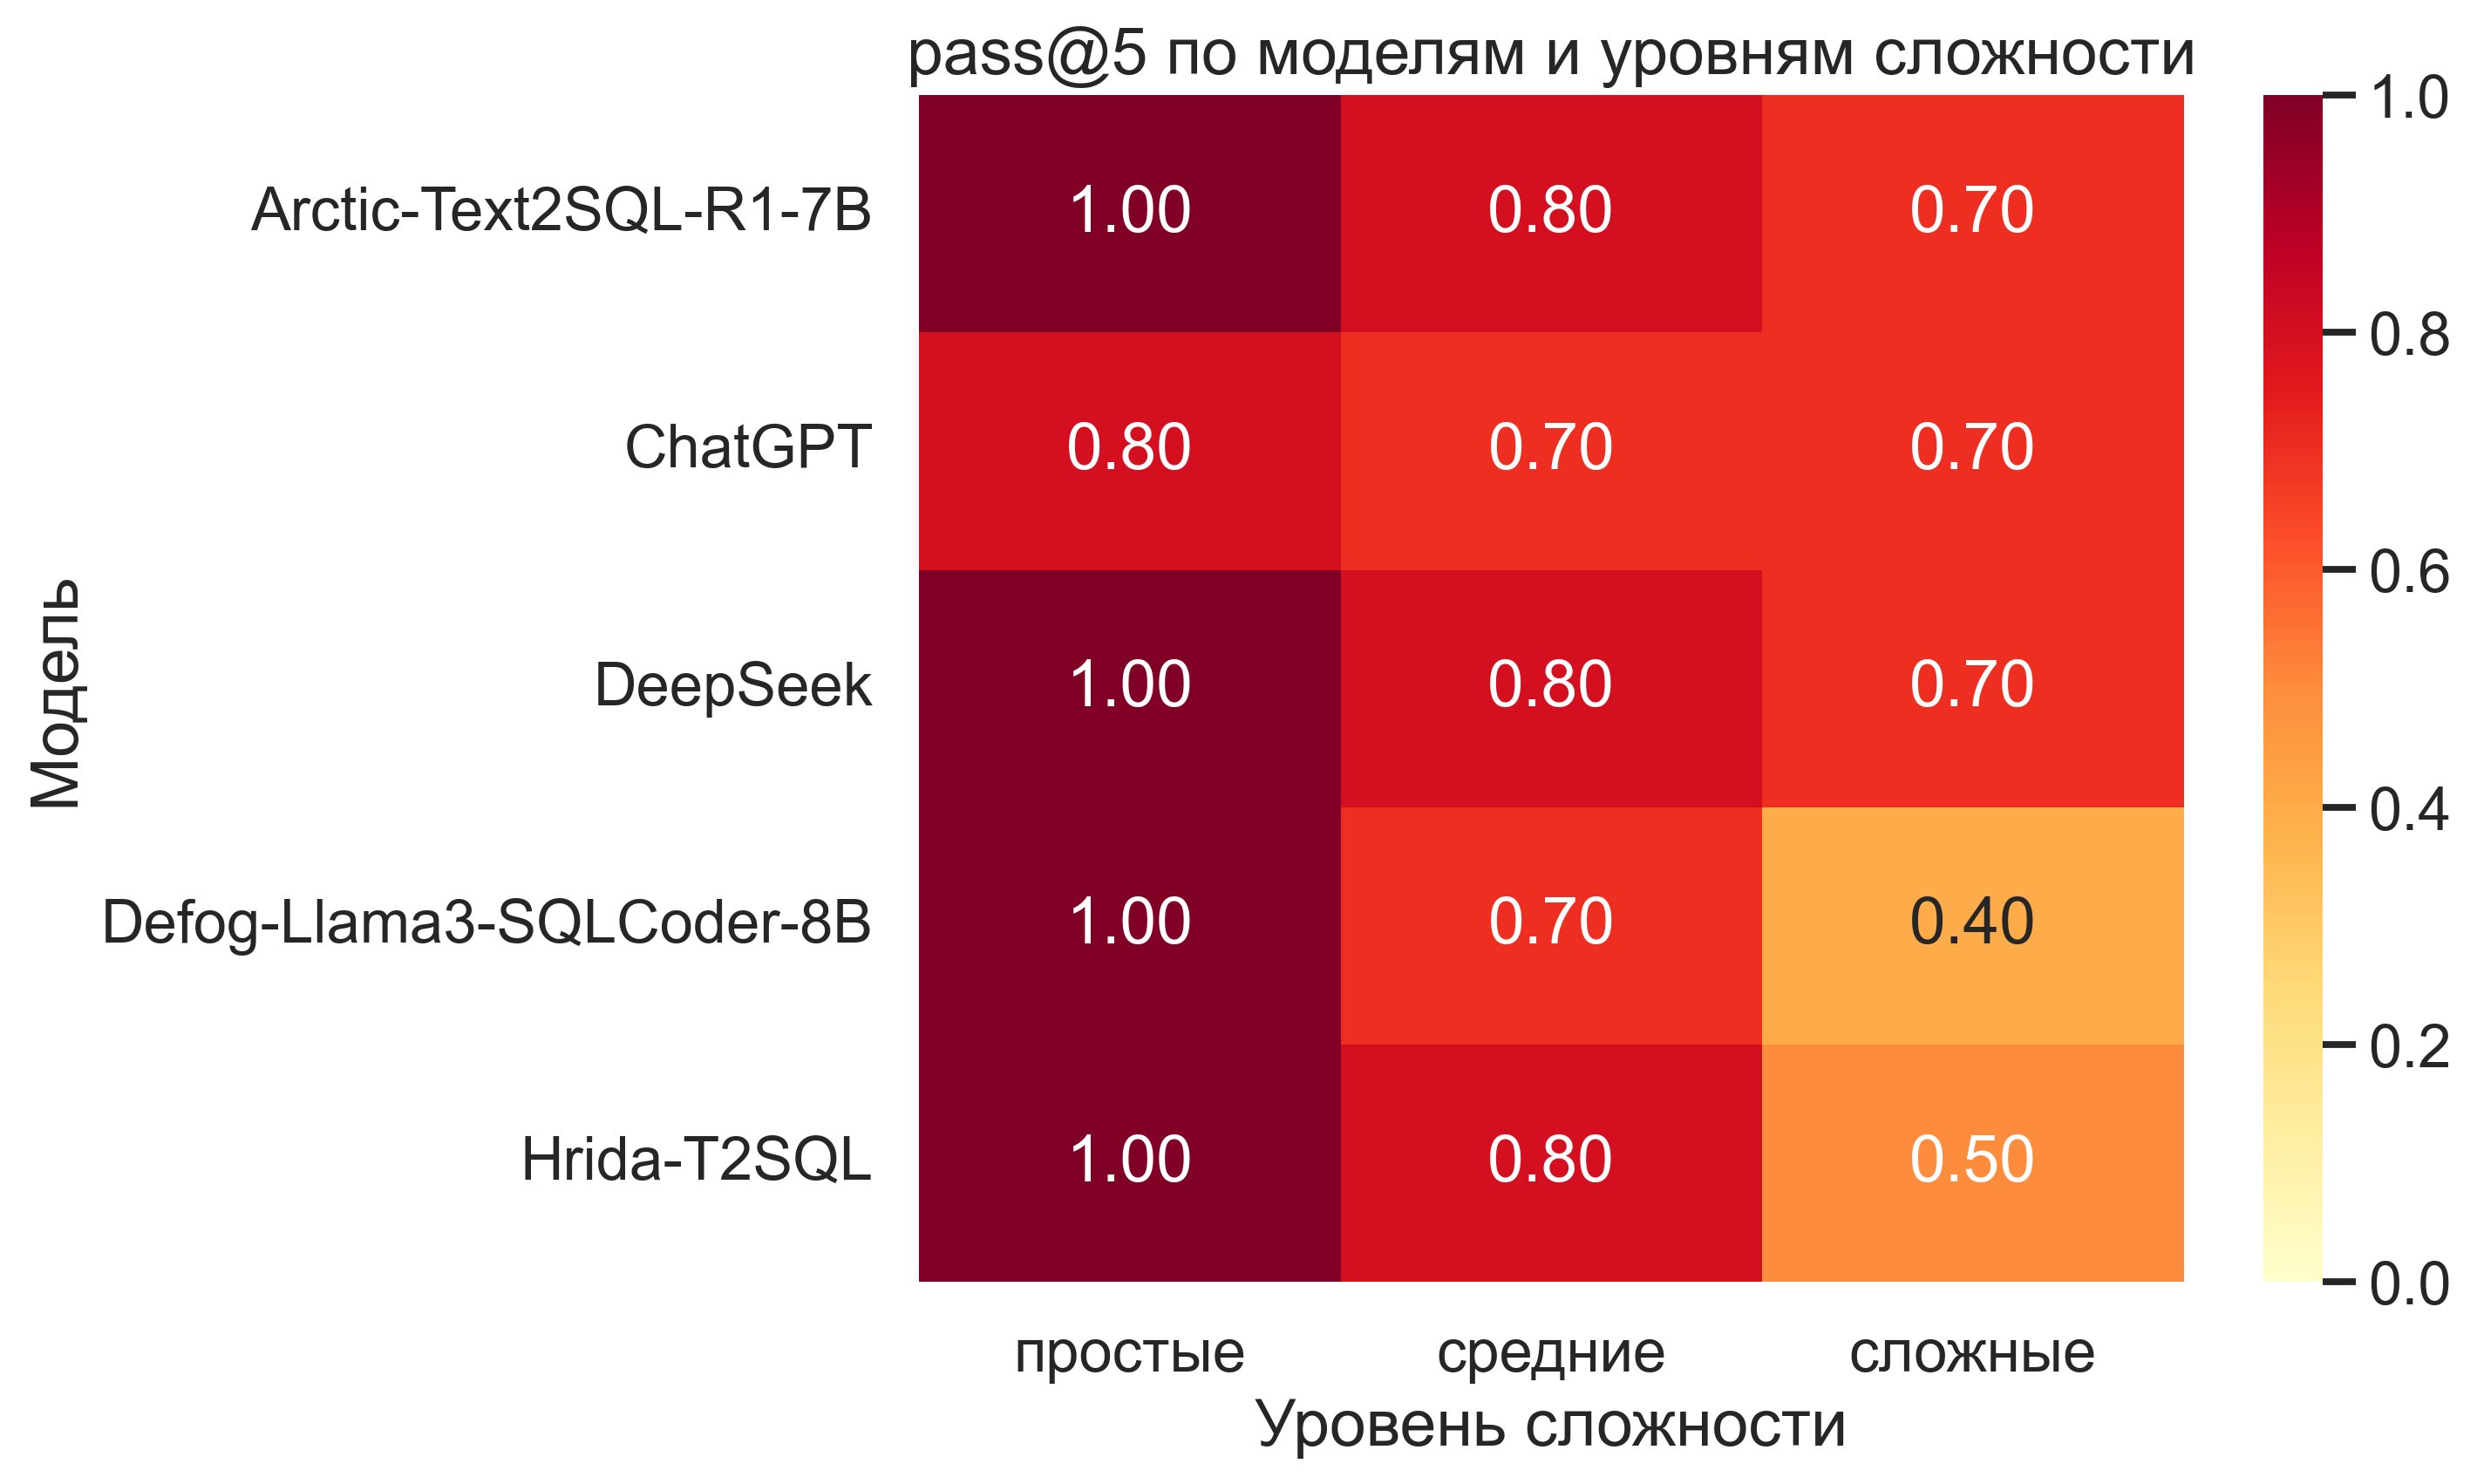

In [5]:
display(Markdown('### Материалы для ПРИЛОЖЕНИЯ Г: Pass@K'))

pass_table = pd.DataFrame()
pass_long_df = extract_passk_long(pass_summary)
if pass_summary.empty or pass_long_df.empty:
    show_missing_data_block('Данные для Pass@K не обнаружены', 'Нужен файл `results/nl2sql/metrics/pass_k/summary_metrics.csv` с колонками `pass@1`, `pass@3`, `pass@5`.')
else:
    pass_table = compact_metric_table(pass_summary, ['execution_accuracy', 'pass@1', 'pass@3', 'pass@5', 'Tinf', 'Tok', 'Cost'])
    pass_table = pass_table.sort_values(['Бенчмарк', 'Pass@5'], ascending=[True, False]).reset_index(drop=True)
    display_table('Таблица Г.1 — Агрегированные значения Pass@K по моделям и наборам данных', pass_table, 4)
    save_table(pass_table, 'appendix_g_table_1_passk_summary.csv', 'Таблица Г.1 — Агрегированные значения Pass@K по моделям и наборам данных', 4)

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.lineplot(data=pass_long_df, x='k', y='pass_at_k', hue='model_display_name', style='benchmark_ru', marker='o', ax=ax)
    ax.set_xlabel('Число попыток генерации K')
    ax.set_ylabel('Pass@K')
    ax.set_ylim(0, 1.05)
    ax.set_xticks(sorted(pass_long_df['k'].unique()))
    ax.legend(title='Модель / набор данных', bbox_to_anchor=(1.02, 1), loc='upper left')
    save_figure(fig, 'appendix_g_fig_1_passk_by_k', 'Рисунок Г.1 — Динамика Pass@K по значениям K для исследуемых моделей')

    max_k = int(pass_long_df['k'].max())
    pass_wide = pass_long_df.pivot_table(index=['model_display_name', 'benchmark_ru'], columns='k', values='pass_at_k').reset_index()
    pass_wide = pass_wide.rename(columns={1: 'Pass@1', max_k: f'Pass@{max_k}', 'model_display_name': 'Модель', 'benchmark_ru': 'Набор данных'})
    fig, ax = plt.subplots(figsize=(10, 5))
    compare_df = pass_wide.melt(id_vars=['Модель', 'Набор данных'], value_vars=['Pass@1', f'Pass@{max_k}'], var_name='Метрика', value_name='Значение')
    sns.barplot(data=compare_df, x='Модель', y='Значение', hue='Метрика', ax=ax)
    ax.set_xlabel('Модель')
    ax.set_ylabel('Значение метрики')
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='x', rotation=25)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment('right')
    ax.legend(title='Метрика', bbox_to_anchor=(1.02, 1), loc='upper left')
    save_figure(fig, 'appendix_g_fig_2_pass1_vs_passkmax', f'Рисунок Г.2 — Сравнение Pass@1 и Pass@{max_k} по моделям')

    gain_df = pass_wide.copy()
    gain_df['Прирост'] = gain_df[f'Pass@{max_k}'] - gain_df['Pass@1']
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=gain_df, x='Модель', y='Прирост', hue='Набор данных', ax=ax)
    ax.axhline(0.0, color='black', linestyle='--', linewidth=1)
    ax.set_xlabel('Модель')
    ax.set_ylabel('Абсолютный прирост')
    ax.tick_params(axis='x', rotation=25)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment('right')
    ax.legend(title='Набор данных', bbox_to_anchor=(1.02, 1), loc='upper left')
    save_figure(fig, 'appendix_g_fig_3_passk_gain', f'Рисунок Г.3 — Прирост качества генерации SQL при использовании Pass@{max_k}')

passk_difficulty_df = compute_passk_by_difficulty(pass_samples)
if passk_difficulty_df.empty:
    show_missing_data_block('Pass@K по уровням сложности', 'Нет достаточных sample-level данных с `difficulty` и `candidate_hits`.')
else:
    display_table('Таблица Г.2 — Значения Pass@K по уровням сложности', passk_difficulty_df, 4)
    save_table(passk_difficulty_df, 'appendix_g_table_2_passk_by_difficulty.csv', 'Таблица Г.2 — Значения Pass@K по уровням сложности', 4)

for title, src, dst in [
    ('Рисунок Г.4 — Время инференса в режиме Pass@K', RESULTS_DIR / 'figures' / 'pass_k' / 'eff_latency_ru.png', 'appendix_g_fig_4_passk_latency.png'),
    ('Рисунок Г.5 — Парные различия качества в режиме Pass@K', RESULTS_DIR / 'figures' / 'pass_k' / 'pairwise_delta_ru.png', 'appendix_g_fig_5_passk_pairwise_delta.png'),
    ('Рисунок Г.6 — Pass@K и прирост Pass@5 относительно EA в SEB', RESULTS_DIR / 'synthetic_benchmark' / 'figures' / 'synthetic_analysis' / 'seb_passk_and_gain_ru.png', 'appendix_g_fig_6_seb_passk_and_gain.png'),
    ('Рисунок Г.7 — Pass@K по уровням сложности SEB', RESULTS_DIR / 'synthetic_benchmark' / 'figures' / 'synthetic_analysis' / 'seb_passk_difficulty_heatmap_ru.png', 'appendix_g_fig_7_seb_passk_by_difficulty.png'),
]:
    copied = copy_existing_figure(src, dst, title)
    if copied is not None:
        display_png(title, copied)


## Приложение Д. Дополнительные материалы по анализу ошибок и экспертному слою


### Материалы для ПРИЛОЖЕНИЯ Д: анализ ошибок, экспертный слой и эффективность

**Таблица Д.1 — Сводное распределение типов ошибок по моделям**

Модель,Бенчмарк,Исход,Количество,Доля
ChatGPT 5.2,BIRD,корректный результат,561,0.365700
ChatGPT 5.2,BIRD,некорректный результат,965,0.629100
ChatGPT 5.2,BIRD,ошибка выполнения,2,0.001300
ChatGPT 5.2,BIRD,синтаксическая ошибка,2,0.001300
ChatGPT 5.2,BIRD,тайм-аут,4,0.002600
DeepSeek V3.2,BIRD,корректный результат,495,0.322700
DeepSeek V3.2,BIRD,некорректный результат,972,0.633600
DeepSeek V3.2,BIRD,ошибка выполнения,48,0.031300
DeepSeek V3.2,BIRD,синтаксическая ошибка,14,0.009100
DeepSeek V3.2,BIRD,тайм-аут,5,0.003300


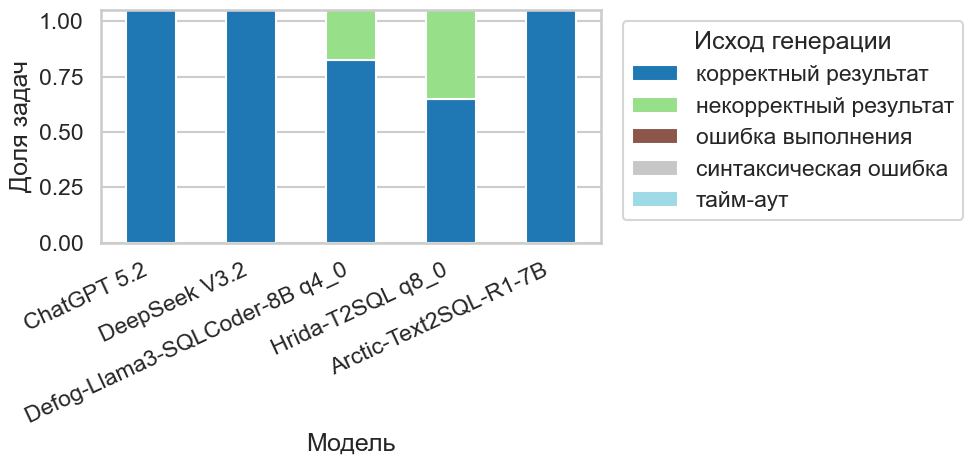

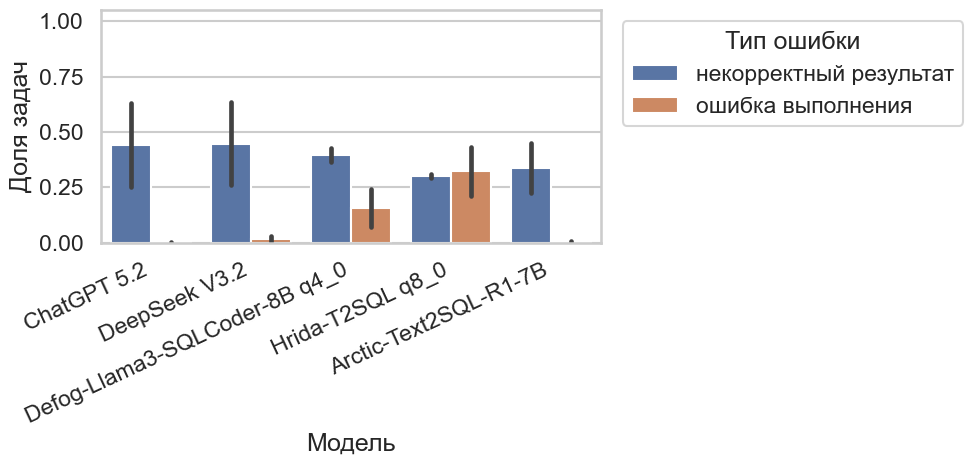

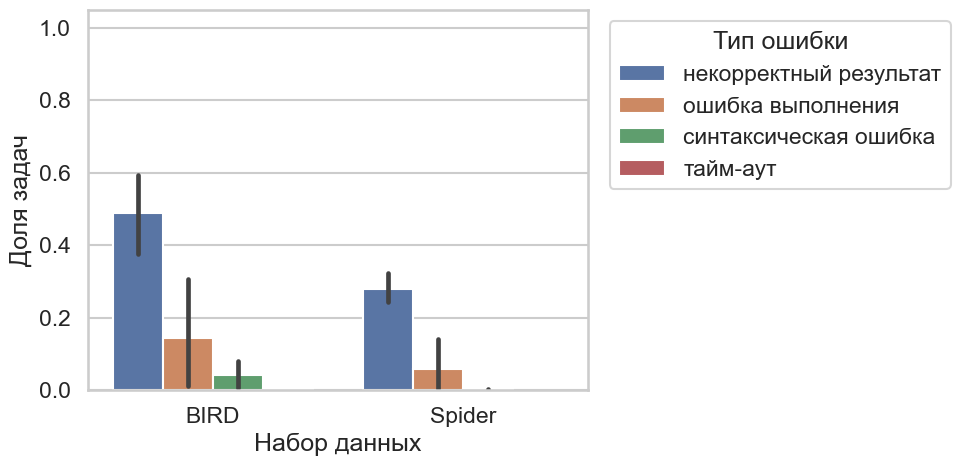

**Таблица Д.2 — Примеры ошибок генерации SQL**

Модель,Бенчмарк,ID примера,Сложность,Вопрос,Сгенерированный SQL,Эталонный SQL,Исход,Текст ошибки,Краткий комментарий
Arctic-Text2SQL-R1-7B,BIRD,bird_1,средние,Please list the lowest three eligible free rates for students aged 5-17 in continuation schools.,"SELECT `County Name`, `District Name`, `School Name`, (`Free Meal Count (Ages 5-17)` / `Enrollment (Ages 5-17)`) * 100 AS EligibleFreeRate FROM frpm WHERE `School Type` = 'Continuation School' ORDER BY EligibleFreeRate ASC LIMIT 3",SELECT `Free Meal Count (Ages 5-17)` / `Enrollment (Ages 5-17)` FROM frpm WHERE `Educational Option Type` = 'Continuation School' AND `Free Meal Count (Ages 5-17)` / `Enrollment (Ages 5-17)` IS NOT NULL ORDER BY `Free Meal Count (Ages 5-17)` / `Enrollment (Ages 5-17)` ASC LIMIT 3,некорректный результат,nan,"SQL выполнился, но результат не совпал с эталоном."
Arctic-Text2SQL-R1-7B,BIRD,bird_2,простые,Please list the zip code of all the charter schools in Fresno County Office of Education.,SELECT DISTINCT s.Zip FROM schools AS s INNER JOIN frpm AS f ON s.CDSCode = f.CDSCode WHERE s.Charter = 1 AND f.`District Type` = 'Fresno County Office of Education',SELECT T2.Zip FROM frpm AS T1 INNER JOIN schools AS T2 ON T1.CDSCode = T2.CDSCode WHERE T1.`District Name` = 'Fresno County Office of Education' AND T1.`Charter School (Y/N)` = 1,некорректный результат,nan,"SQL выполнился, но результат не совпал с эталоном."
Arctic-Text2SQL-R1-7B,BIRD,bird_4,средние,Please list the phone numbers of the direct charter-funded schools that are opened after 2000/1/1.,SELECT DISTINCT s.Phone FROM schools AS s INNER JOIN frpm AS f ON s.CDSCode = f.CDSCode WHERE f.`Charter School (Y/N)` = 1 AND s.OpenDate > '2000-01-01',SELECT T2.Phone FROM frpm AS T1 INNER JOIN schools AS T2 ON T1.CDSCode = T2.CDSCode WHERE T1.`Charter Funding Type` = 'Directly funded' AND T1.`Charter School (Y/N)` = 1 AND T2.OpenDate > '2000-01-01',некорректный результат,nan,"SQL выполнился, но результат не совпал с эталоном."
Arctic-Text2SQL-R1-7B,BIRD,bird_6,простые,"Among the schools with the SAT test takers of over 500, please list the schools that are magnet schools or offer a magnet program.",SELECT DISTINCT s.School FROM schools AS s INNER JOIN satscores AS ss ON s.CDSCode = ss.cds WHERE (s.Magnet = 1 OR ss.NumTstTakr > 500),SELECT T2.School FROM satscores AS T1 INNER JOIN schools AS T2 ON T1.cds = T2.CDSCode WHERE T2.Magnet = 1 AND T1.NumTstTakr > 500,некорректный результат,nan,"SQL выполнился, но результат не совпал с эталоном."
Arctic-Text2SQL-R1-7B,BIRD,bird_9,простые,"Among the schools with the average score in Math over 560 in the SAT test, how many schools are directly charter-funded?",SELECT COUNT(*) AS DirectlyCharterFundedCount FROM schools s INNER JOIN satscores ss ON s.CDSCode = ss.cds WHERE ss.AvgScrMath > 560 AND s.FundingType = 'Direct',SELECT COUNT(T2.`School Code`) FROM satscores AS T1 INNER JOIN frpm AS T2 ON T1.cds = T2.CDSCode WHERE T1.AvgScrMath > 560 AND T2.`Charter Funding Type` = 'Directly funded',некорректный результат,nan,"SQL выполнился, но результат не совпал с эталоном."
Arctic-Text2SQL-R1-7B,BIRD,bird_10,простые,"For the school with the highest average score in Reading in the SAT test, what is its FRPM count for students aged 5-17?",SELECT f.`FRPM Count (Ages 5-17)` FROM satscores s INNER JOIN frpm f ON s.cds = f.CDSCode WHERE s.rtype = 'Total' ORDER BY s.AvgScrRead DESC LIMIT 1,SELECT T2.`FRPM Count (Ages 5-17)` FROM satscores AS T1 INNER JOIN frpm AS T2 ON T1.cds = T2.CDSCode ORDER BY T1.AvgScrRead DESC LIMIT 1,некорректный результат,nan,"SQL выполнился, но результат не совпал с эталоном."
Arctic-Text2SQL-R1-7B,BIRD,bird_15,простые,Which active district has the highest average score in Reading?,"SELECT T2.dname AS DistrictName, AVG(T2.AvgScrRead) AS AverageReadingScore FROM schools AS T1 INNER JOIN satscores AS T2 ON T1.CDSCode = T2.cds WHERE T1.StatusType = 'Active' GROUP BY T2.dname ORDER BY AVG(T2.AvgScrRead) DESC LIMIT 1",SELECT T1.District FROM schools AS T1 INNE

**Рисунок Д.4 — Пересечение корректных ответов в режиме EA**

> Источник: `reports/appendix_assets/appendix_d_fig_4_correctness_overlap.png`

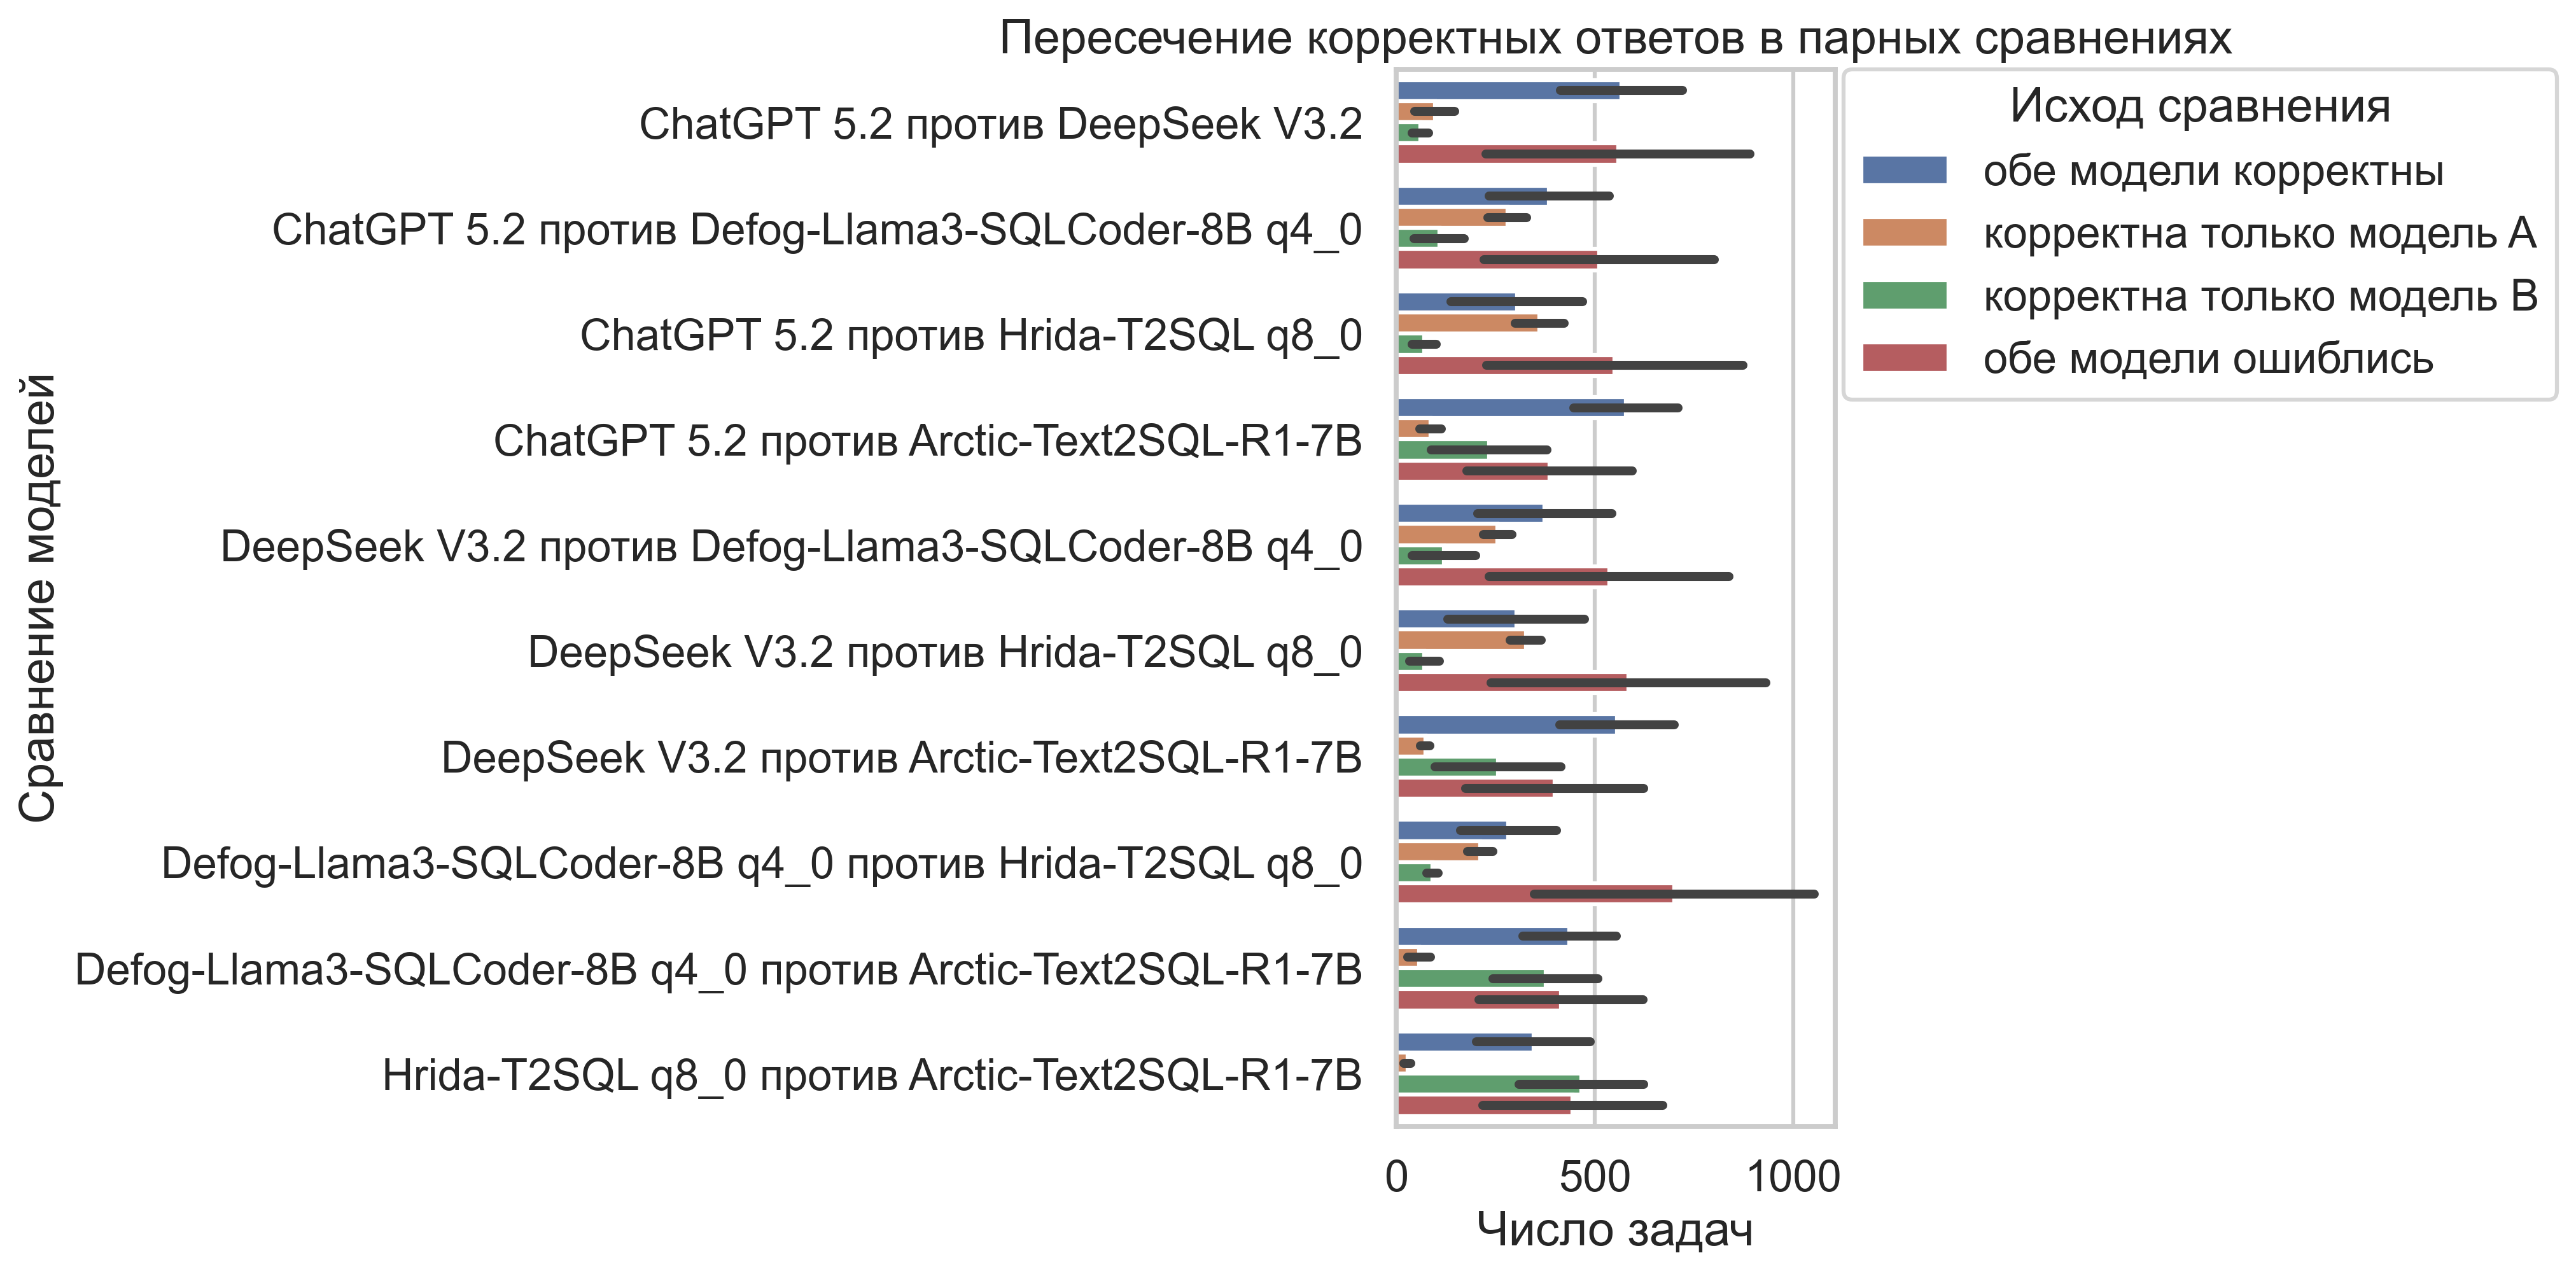

**Рисунок Д.10 — Стратификация Execution Accuracy по сложности и длине вопроса**

> Источник: `reports/appendix_assets/appendix_d_fig_10_ea_stratification.png`

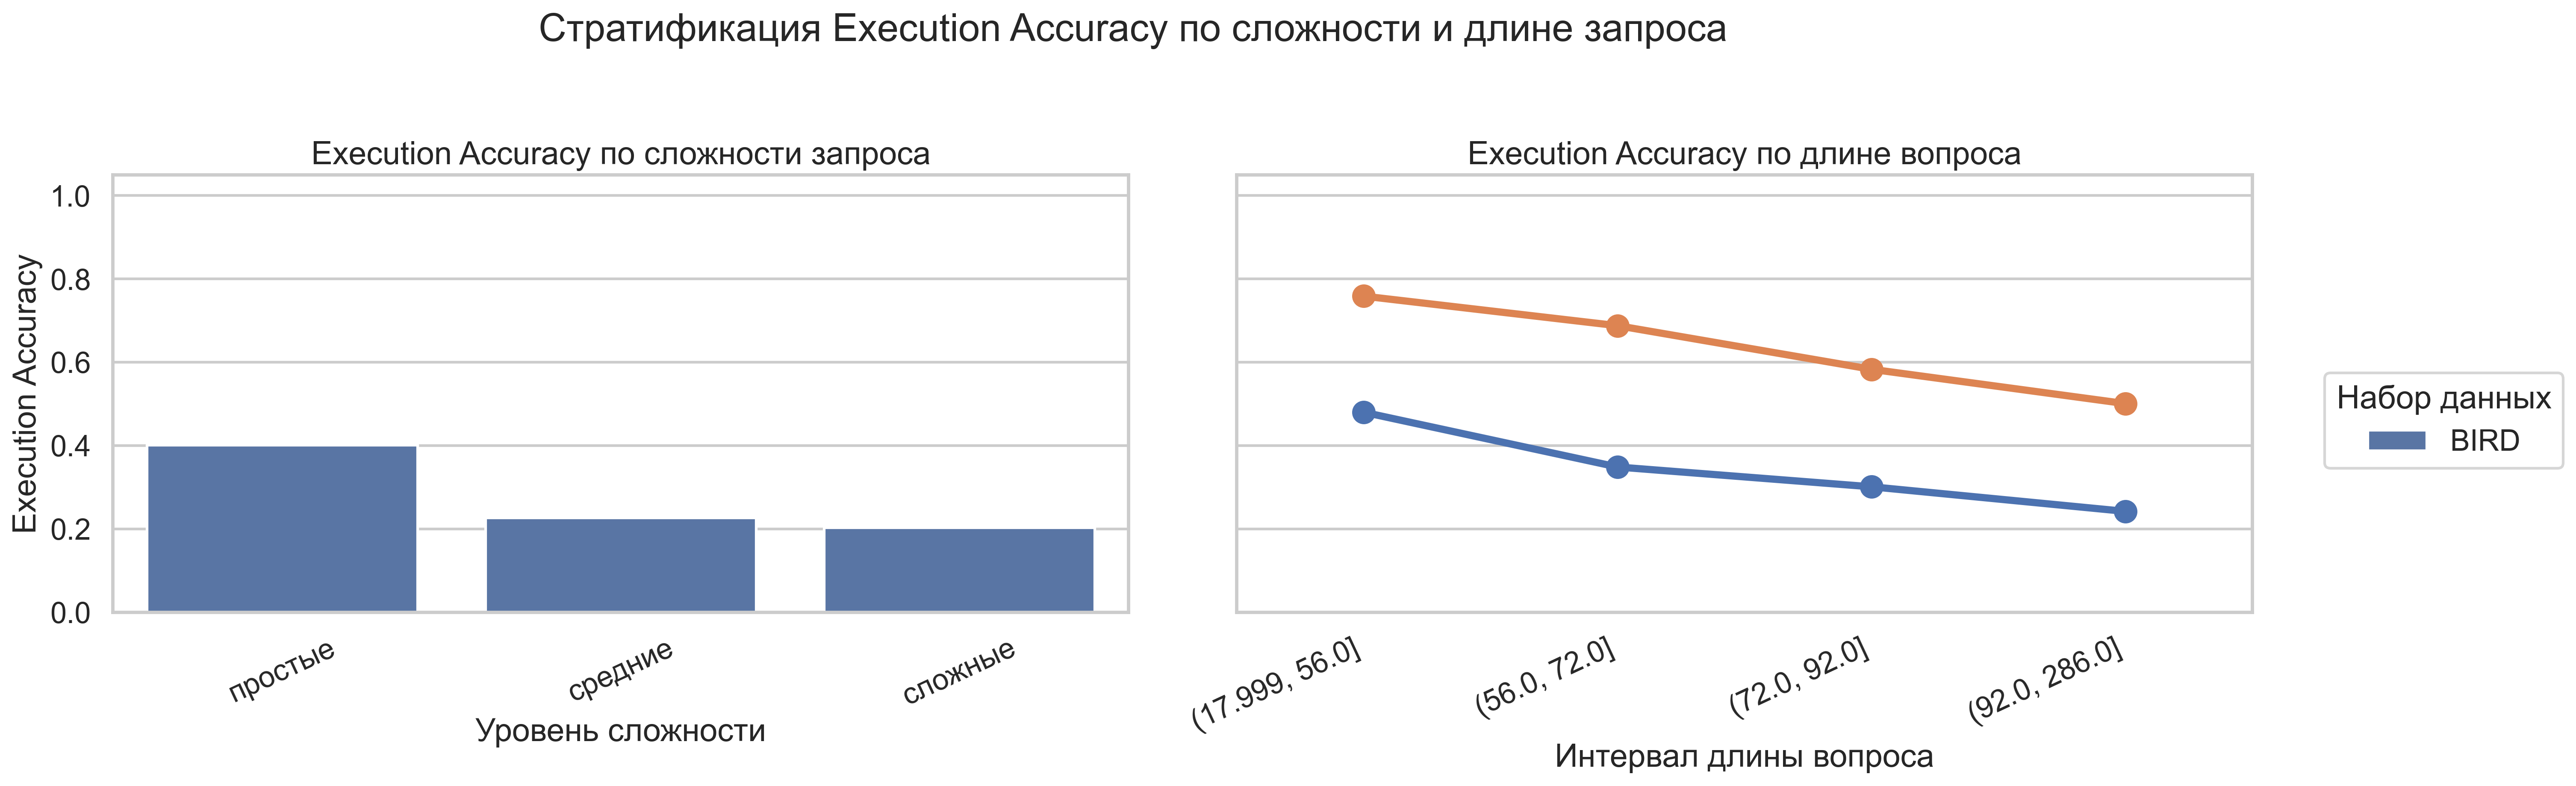

**Рисунок Д.11 — Структура исходов выполнения SQL на Spider и BIRD**

> Источник: `reports/appendix_assets/appendix_d_fig_11_sql_outcomes.png`

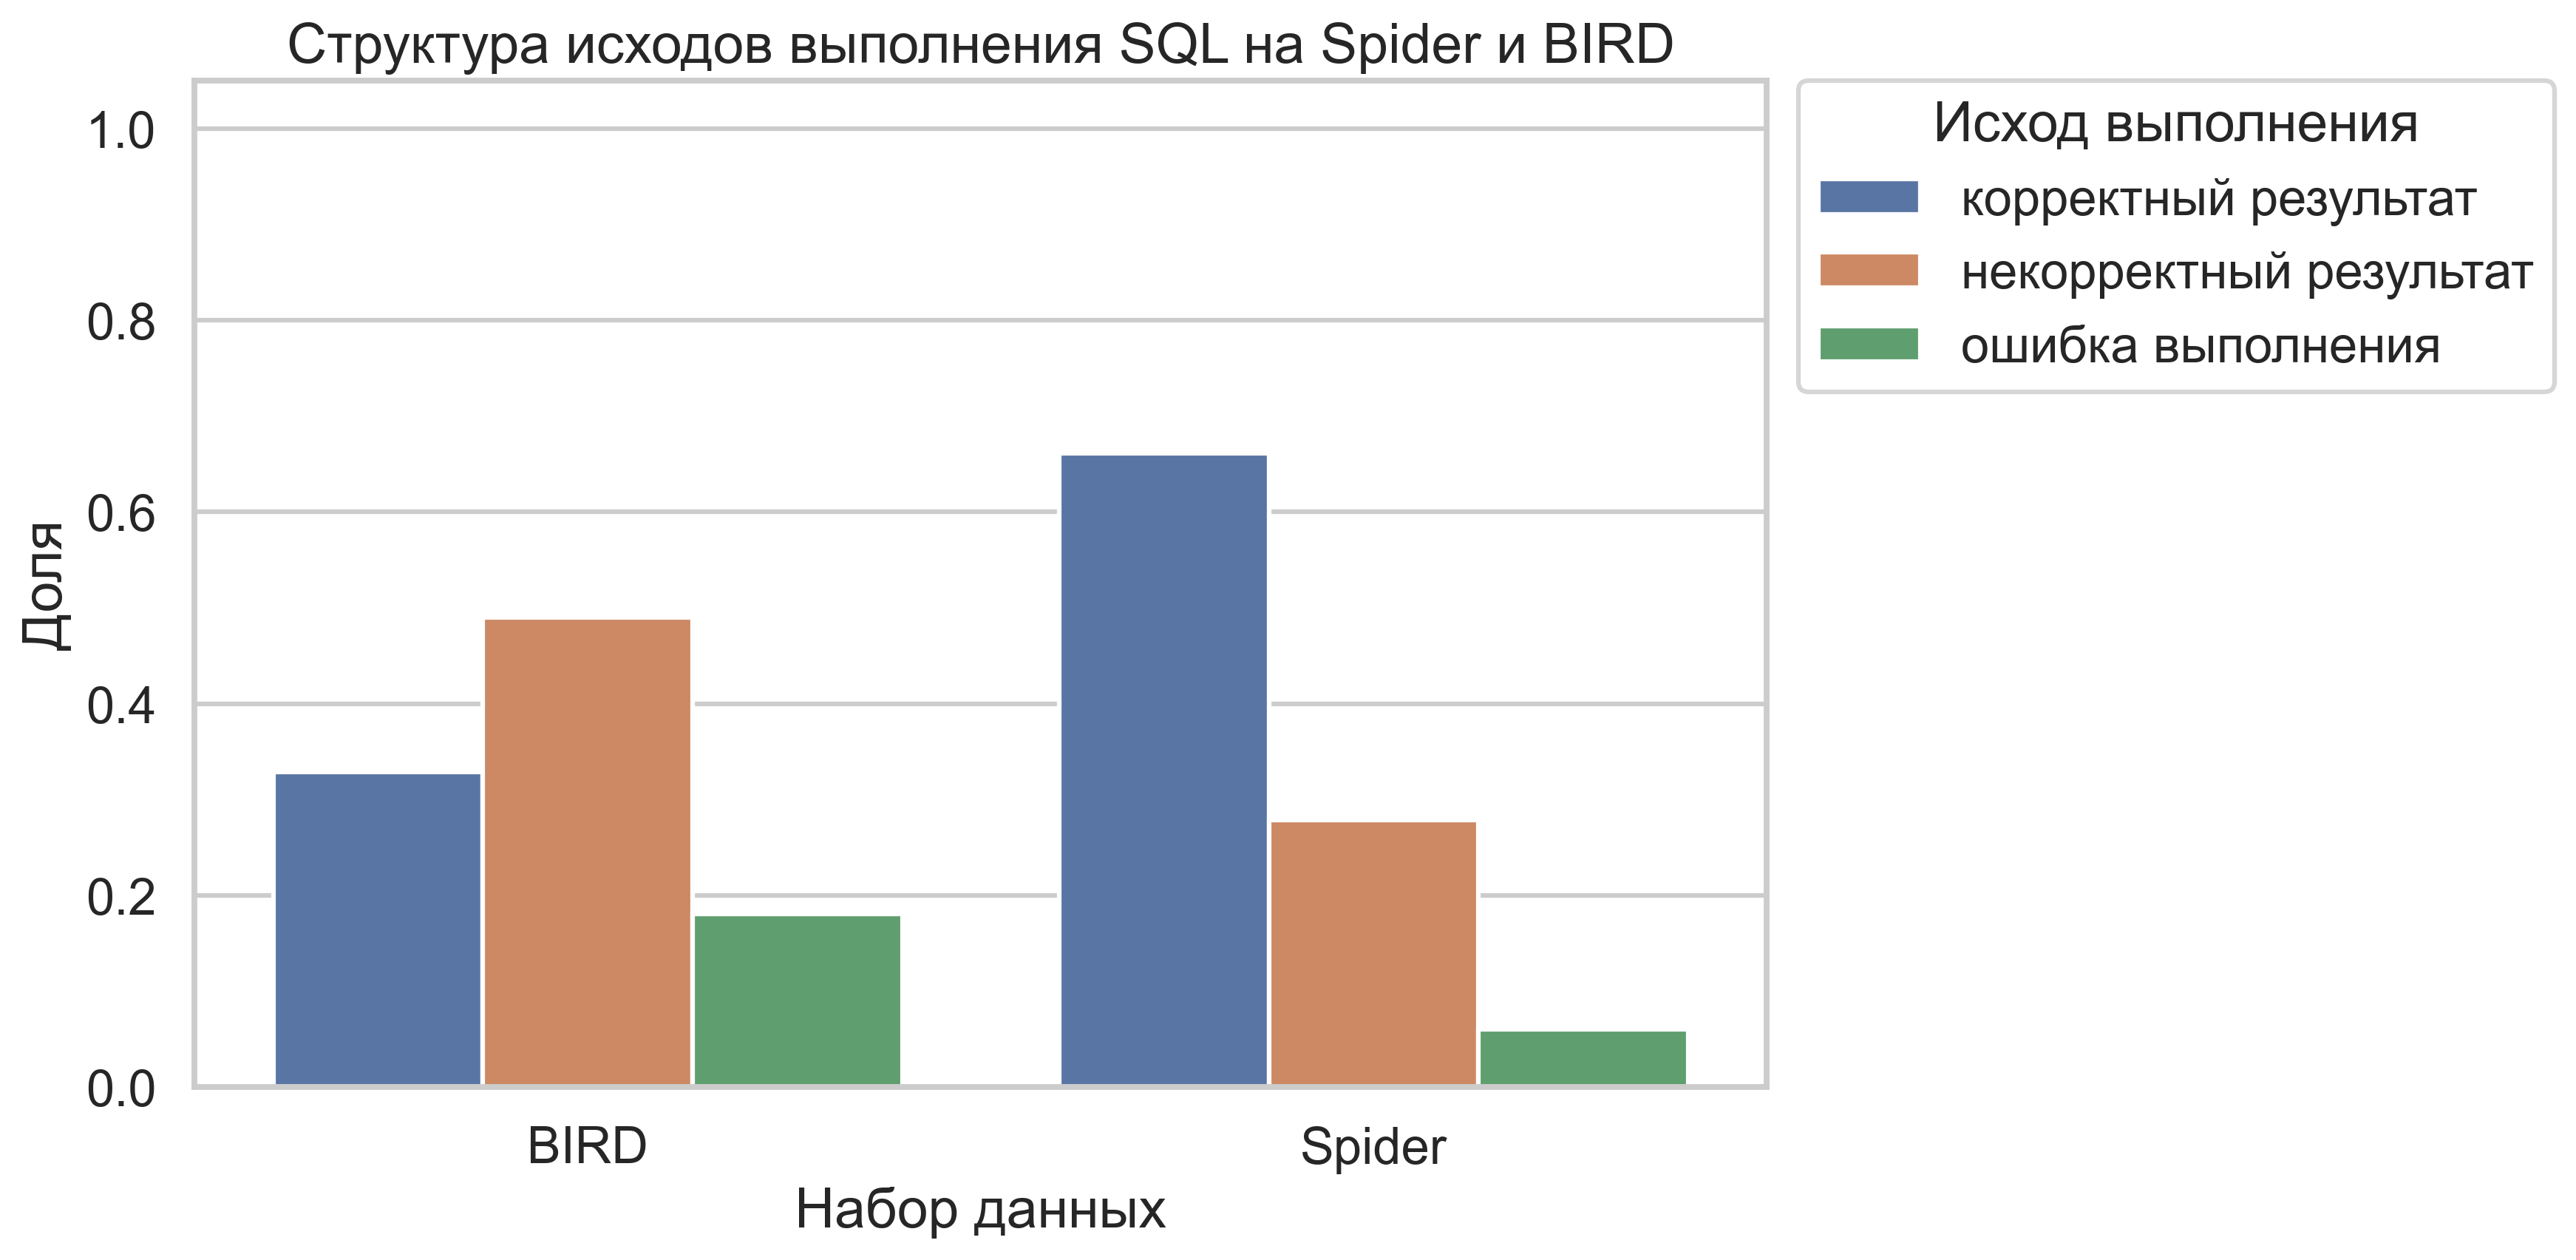

**Таблица Д.3 — Статус экспертного слоя**

Режим,Статус,Заполненных строк,Всего строк
EA,есть заполненные оценки,100,100
Pass@K,не входит в экспертный протокол,0,0


**Таблица Д.3а — Expert Score на 100 успешных EA-запросах**

Бенчмарк,Модель,N,Полнота,Эффективность,Читаемость,Expert Score,Эксперт 1,Эксперт 2
BIRD,Arctic-Text2SQL-R1-7B,10,4.850000,4.850000,4.900000,4.867000,4.900000,4.833000
BIRD,ChatGPT 5.2,10,4.450000,4.450000,4.500000,4.467000,4.400000,4.533000
BIRD,DeepSeek V3.2,10,4.700000,4.650000,4.750000,4.700000,4.733000,4.667000
BIRD,Defog-Llama3-SQLCoder-8B q4_0,10,4.900000,4.400000,4.400000,4.567000,4.533000,4.600000
BIRD,Hrida-T2SQL q8_0,10,4.300000,4.650000,4.450000,4.467000,4.433000,4.500000
Spider,Arctic-Text2SQL-R1-7B,10,4.800000,5.000000,4.800000,4.867000,4.867000,4.867000
Spider,ChatGPT 5.2,10,4.700000,4.800000,4.700000,4.733000,4.767000,4.700000
Spider,DeepSeek V3.2,10,4.800000,4.750000,4.800000,4.783000,4.800000,4.767000
Spider,Defog-Llama3-SQLCoder-8B q4_0,10,4.800000,4.500000,4.400000,4.567000,4.633000,4.500000
Spider,Hrida-T2SQL q8_0,10,5.000000,4.850000,4.800000,4.883000,4.900000,4.867000


**Таблица Д.3б — Согласие экспертов по Expert Score**

Критерий,N,Доля совпадений,Среднее абсолютное расхождение,Cohen's kappa
completeness,100,0.940000,0.060000,0.812000
efficiency,100,0.880000,0.120000,0.714000
readability,100,0.900000,0.100000,0.780000
expert_score_rounded,100,0.910000,0.080000,0.795000


**Таблица Д.4 — Сводка вычислительных характеристик моделей**

Модель,Бенчмарк,N,Execution Accuracy,"Время инференса, мс",Токены,"Стоимость, $",Eff,Eff normalized
ChatGPT 5.2,bird,1534,0.365700,2374.467500,1021.217100,0.001900,1018.706100,0.612700
DeepSeek V3.2,bird,1534,0.322700,3494.510600,1051.518300,0.000300,1363.808800,0.402000
Defog-Llama3-SQLCoder-8B q4_0,bird,1534,0.263400,733.315800,974.123200,0.000000,512.231700,0.175300
Hrida-T2SQL q8_0,bird,1534,0.155100,1081.159400,1440.481700,0.000000,756.492400,0.332200
Arctic-Text2SQL-R1-7B,bird,1534,0.538500,6038.118000,1335.371600,0.000000,2212.046900,0.568900
ChatGPT 5.2,spider,1034,0.742700,1895.343000,479.256300,0.000900,712.380200,0.262500
DeepSeek V3.2,spider,1034,0.736900,2965.675100,514.916800,0.000200,1044.177600,0.187100
Defog-Llama3-SQLCoder-8B q4_0,spider,1034,0.562900,531.061200,426.915900,0.000000,287.393100,0.002500
Hrida-T2SQL q8_0,spider,1034,0.491300,485.614800,668.450700,0.000000,346.219600,0.071500
Arctic-Text2SQL-R1-7B,spider,1034,0.771800,4854.238000,734.642200,0.000000,1676.664000,0.327100


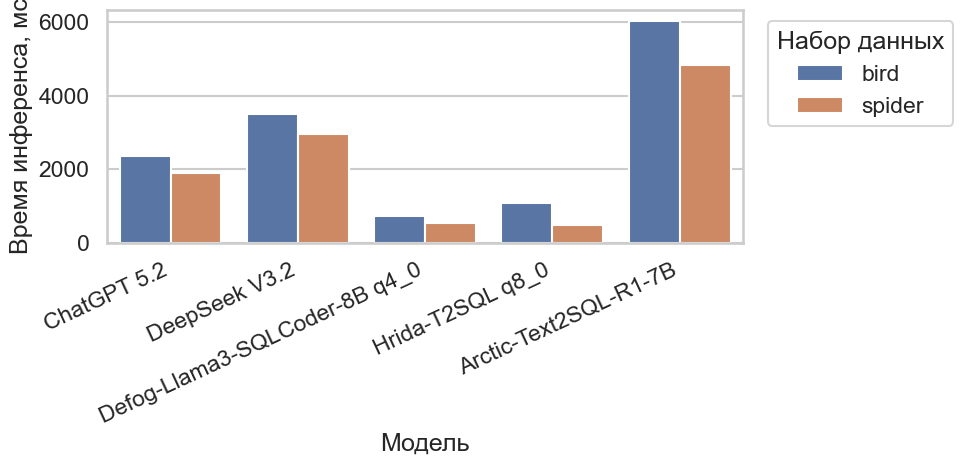

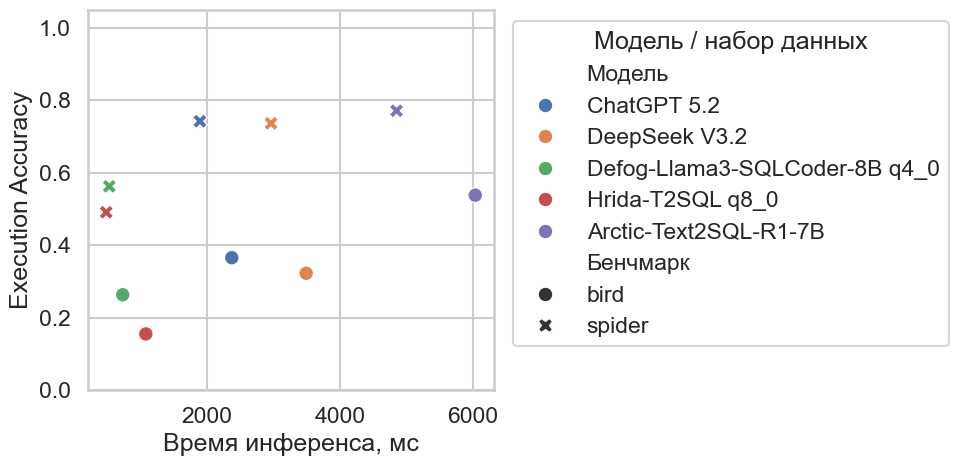

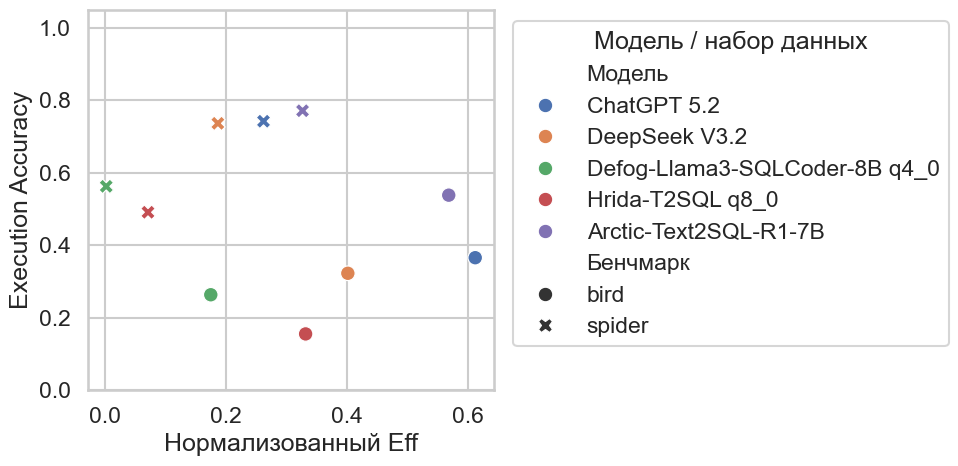

**Таблица Д.5 — Bootstrap-квантили EA по моделям и наборам данных**

Модель,Бенчмарк,Execution Accuracy,q05,q50,q95
Arctic-Text2SQL-R1-7B,BIRD,0.538500,0.515000,0.538800,0.559300
Arctic-Text2SQL-R1-7B,Spider,0.771800,0.749500,0.771800,0.792100
ChatGPT 5.2,BIRD,0.365700,0.346800,0.365700,0.385300
ChatGPT 5.2,Spider,0.742700,0.719500,0.742700,0.765000
DeepSeek V3.2,BIRD,0.322700,0.303100,0.322700,0.342200
DeepSeek V3.2,Spider,0.736900,0.714700,0.736900,0.759200
Defog-Llama3-SQLCoder-8B q4_0,BIRD,0.263400,0.245800,0.263400,0.282300
Defog-Llama3-SQLCoder-8B q4_0,Spider,0.562900,0.538700,0.562900,0.588000
Hrida-T2SQL q8_0,BIRD,0.155100,0.140200,0.155100,0.170100
Hrida-T2SQL q8_0,Spider,0.491300,0.465200,0.491300,0.515500


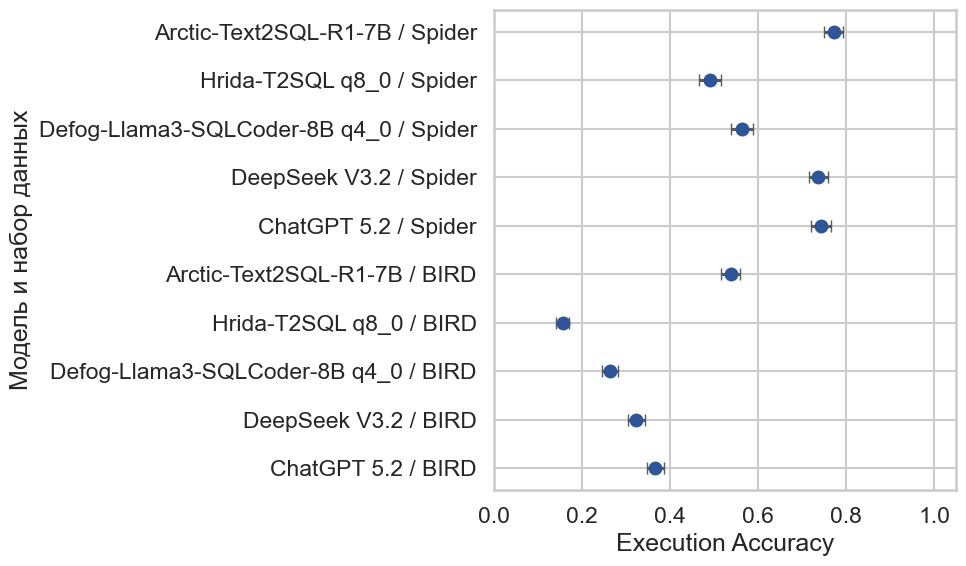

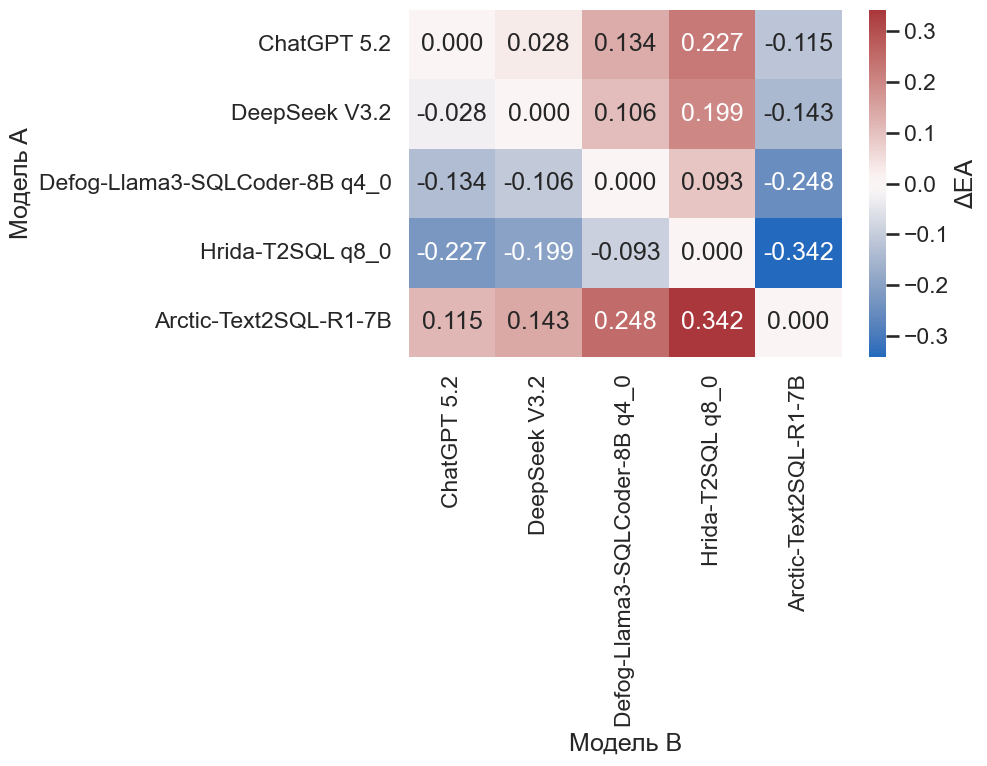

In [6]:
display(Markdown('### Материалы для ПРИЛОЖЕНИЯ Д: анализ ошибок, экспертный слой и эффективность'))

errors_df, error_summary = make_error_summary(ea_samples)
if error_summary.empty:
    show_missing_data_block('Анализ ошибок', 'Нет достаточных sample-level данных EA для основного корпуса моделей.')
else:
    display_table('Таблица Д.1 — Сводное распределение типов ошибок по моделям', error_summary, 4)
    save_table(error_summary, 'appendix_d_table_1_error_summary.csv', 'Таблица Д.1 — Сводное распределение типов ошибок по моделям', 4)

    fig, ax = plt.subplots(figsize=(10, 5))
    stacked = error_summary.pivot_table(index='Модель', columns='Исход', values='Доля', aggfunc='sum', fill_value=0)
    stacked = stacked.reindex(index=[m for m in MAIN_REPORT_MODELS if m in stacked.index])
    stacked.plot(kind='bar', stacked=True, ax=ax, colormap='tab20')
    ax.set_xlabel('Модель')
    ax.set_ylabel('Доля задач')
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='x', rotation=25)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment('right')
    ax.legend(title='Исход генерации', bbox_to_anchor=(1.02, 1), loc='upper left')
    save_figure(fig, 'appendix_d_fig_1_error_distribution', 'Рисунок Д.1 — Распределение исходов генерации SQL по моделям')

    main_error_types = error_summary[error_summary['Исход'].isin(['ошибка выполнения', 'некорректный результат'])].copy()
    if main_error_types.empty:
        show_missing_data_block('Основные типы ошибок', 'В данных не обнаружены категории execution_error/wrong_result.')
    else:
        fig, ax = plt.subplots(figsize=(10, 5))
        sns.barplot(data=main_error_types, x='Модель', y='Доля', hue='Исход', ax=ax)
        ax.set_xlabel('Модель')
        ax.set_ylabel('Доля задач')
        ax.set_ylim(0, 1.05)
        ax.tick_params(axis='x', rotation=25)
        for label in ax.get_xticklabels():
            label.set_horizontalalignment('right')
        ax.legend(title='Тип ошибки', bbox_to_anchor=(1.02, 1), loc='upper left')
        save_figure(fig, 'appendix_d_fig_2_error_types_by_model', 'Рисунок Д.2 — Сравнение основных типов ошибок генерации SQL')

    dataset_errors = error_summary[error_summary['Исход'] != 'корректный результат'].copy()
    if dataset_errors.empty:
        show_missing_data_block('Ошибки по наборам данных', 'В данных нет ошибок для построения распределения по benchmark/dataset.')
    else:
        fig, ax = plt.subplots(figsize=(10, 5))
        sns.barplot(data=dataset_errors, x='Бенчмарк', y='Доля', hue='Исход', ax=ax)
        ax.set_xlabel('Набор данных')
        ax.set_ylabel('Доля задач')
        ax.set_ylim(0, 1.05)
        ax.legend(title='Тип ошибки', bbox_to_anchor=(1.02, 1), loc='upper left')
        save_figure(fig, 'appendix_d_fig_3_errors_by_dataset', 'Рисунок Д.3 — Распределение ошибок по наборам данных')

    error_examples = errors_df[errors_df['outcome'] != 'correct'].copy()
    example_cols = ['Модель', 'Бенчмарк', 'sample_id', 'difficulty', 'question', 'first_pred_sql', 'gold_sql', 'Исход', 'first_pred_error']
    error_examples = error_examples[[col for col in example_cols if col in error_examples.columns]].head(20)
    error_examples = error_examples.rename(columns={
        'sample_id': 'ID примера',
        'difficulty': 'Сложность',
        'question': 'Вопрос',
        'first_pred_sql': 'Сгенерированный SQL',
        'gold_sql': 'Эталонный SQL',
        'first_pred_error': 'Текст ошибки',
    })
    if 'Сложность' in error_examples.columns:
        error_examples['Сложность'] = error_examples['Сложность'].map(DIFFICULTY_LABELS).fillna(error_examples['Сложность'])
    error_examples['Краткий комментарий'] = error_examples['Исход'].map({
        'ошибка выполнения': 'SQL не выполнился на целевой базе.',
        'некорректный результат': 'SQL выполнился, но результат не совпал с эталоном.',
        'пустой SQL': 'Модель не вернула исполнимый SQL-запрос.',
        'синтаксическая ошибка': 'Ошибка относится к синтаксису SQL.',
        'тайм-аут': 'Выполнение SQL завершилось по тайм-ауту.',
    }).fillna('Требуется ручная проверка.')
    display_table('Таблица Д.2 — Примеры ошибок генерации SQL', error_examples)
    save_table(error_examples, 'appendix_d_table_2_error_examples.csv', 'Таблица Д.2 — Примеры ошибок генерации SQL')

for title, src, dst in [
    ('Рисунок Д.4 — Пересечение корректных ответов в режиме EA', RESULTS_DIR / 'figures' / 'ea' / 'correctness_overlap_ru.png', 'appendix_d_fig_4_correctness_overlap.png'),
    ('Рисунок Д.10 — Стратификация Execution Accuracy по сложности и длине вопроса', RESULTS_DIR / 'figures' / 'final' / 'ea_stratification_ru.png', 'appendix_d_fig_10_ea_stratification.png'),
    ('Рисунок Д.11 — Структура исходов выполнения SQL на Spider и BIRD', RESULTS_DIR / 'figures' / 'final' / 'sql_outcomes_ru.png', 'appendix_d_fig_11_sql_outcomes.png'),
]:
    copied = copy_existing_figure(src, dst, title)
    if copied is not None:
        display_png(title, copied)

expert_sources = []
for mode, expert_df in [('EA', ea_expert), ('Pass@K', pass_expert)]:
    if mode == 'Pass@K':
        expert_sources.append({
            'Режим': mode,
            'Статус': 'не входит в экспертный протокол',
            'Заполненных строк': 0,
            'Всего строк': 0,
        })
        continue
    if expert_df.empty:
        expert_sources.append({'Режим': mode, 'Статус': 'файл отсутствует или пуст', 'Заполненных строк': 0, 'Всего строк': 0})
        continue
    score_cols = [col for col in ['completeness', 'efficiency', 'readability'] if col in expert_df.columns]
    scored_rows = int(expert_df[score_cols].notna().all(axis=1).sum()) if score_cols else 0
    status = 'есть заполненные оценки' if scored_rows else 'нет заполненных оценок'
    expert_sources.append({'Режим': mode, 'Статус': status, 'Заполненных строк': scored_rows, 'Всего строк': len(expert_df)})
expert_status_df = pd.DataFrame(expert_sources)
display_table('Таблица Д.3 — Статус экспертного слоя', expert_status_df)
save_table(expert_status_df, 'appendix_d_table_3_expert_layer_status.csv', 'Таблица Д.3 — Статус экспертного слоя')

if not ea_expert_by_model.empty:
    expert_model_table = ea_expert_by_model.rename(columns={
        'benchmark': 'Бенчмарк',
        'model_display_name': 'Модель',
        'n': 'N',
        'completeness': 'Полнота',
        'efficiency': 'Эффективность',
        'readability': 'Читаемость',
        'expert_score': 'Expert Score',
        'expert_1_score': 'Эксперт 1',
        'expert_2_score': 'Эксперт 2',
    })
    expert_model_table['Бенчмарк'] = expert_model_table['Бенчмарк'].map(BENCHMARK_LABELS).fillna(expert_model_table['Бенчмарк'])
    keep_cols = ['Бенчмарк', 'Модель', 'N', 'Полнота', 'Эффективность', 'Читаемость', 'Expert Score', 'Эксперт 1', 'Эксперт 2']
    expert_model_table = expert_model_table[[col for col in keep_cols if col in expert_model_table.columns]]
    display_table('Таблица Д.3а — Expert Score на 100 успешных EA-запросах', expert_model_table, 3)
    save_table(expert_model_table, 'appendix_d_table_3a_expert_score_by_model.csv', 'Таблица Д.3а — Expert Score на 100 успешных EA-запросах', 3)

if not ea_expert_agreement.empty:
    agreement_table = ea_expert_agreement.rename(columns={
        'criterion': 'Критерий',
        'n': 'N',
        'exact_agreement': 'Доля совпадений',
        'mean_abs_diff': 'Среднее абсолютное расхождение',
        'cohens_kappa': "Cohen's kappa",
    })
    display_table('Таблица Д.3б — Согласие экспертов по Expert Score', agreement_table, 3)
    save_table(agreement_table, 'appendix_d_table_3b_expert_agreement.csv', 'Таблица Д.3б — Согласие экспертов по Expert Score', 3)
elif expert_status_df['Заполненных строк'].sum() == 0:
    show_note('Экспертный слой: данные отсутствуют / не использовались в количественном анализе. Cohen’s Kappa не рассчитывается, потому что нет реальных экспертных меток и минимум двух независимых экспертов.')

compute_df = compact_metric_table(ea_summary, ['execution_accuracy', 'Tinf', 'Tok', 'Cost', 'Eff', 'Eff_normalized'])
if compute_df.empty:
    show_missing_data_block('Вычислительная эффективность', 'Нет summary-метрик EA с latency/tokens/cost/Eff.')
else:
    display_table('Таблица Д.4 — Сводка вычислительных характеристик моделей', compute_df, 4)
    save_table(compute_df, 'appendix_d_table_4_compute_summary.csv', 'Таблица Д.4 — Сводка вычислительных характеристик моделей', 4)

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=compute_df, x='Модель', y='Время инференса, мс', hue='Бенчмарк', ax=ax)
    ax.set_xlabel('Модель')
    ax.set_ylabel('Время инференса, мс')
    ax.tick_params(axis='x', rotation=25)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment('right')
    ax.legend(title='Набор данных', bbox_to_anchor=(1.02, 1), loc='upper left')
    save_figure(fig, 'appendix_d_fig_5_latency_by_model', 'Рисунок Д.5 — Время инференса по моделям')

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.scatterplot(data=compute_df, x='Время инференса, мс', y='Execution Accuracy', hue='Модель', style='Бенчмарк', s=110, ax=ax)
    ax.set_xlabel('Время инференса, мс')
    ax.set_ylabel('Execution Accuracy')
    ax.set_ylim(0, 1.05)
    ax.legend(title='Модель / набор данных', bbox_to_anchor=(1.02, 1), loc='upper left')
    save_figure(fig, 'appendix_d_fig_6_ea_vs_latency', 'Рисунок Д.6 — Соотношение Execution Accuracy и времени инференса')

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.scatterplot(data=compute_df, x='Eff normalized', y='Execution Accuracy', hue='Модель', style='Бенчмарк', s=110, ax=ax)
    ax.set_xlabel('Нормализованный Eff')
    ax.set_ylabel('Execution Accuracy')
    ax.set_ylim(0, 1.05)
    ax.legend(title='Модель / набор данных', bbox_to_anchor=(1.02, 1), loc='upper left')
    save_figure(fig, 'appendix_d_fig_7_ea_vs_eff', 'Рисунок Д.7 — Соотношение Execution Accuracy и нормализованной эффективности')

bootstrap_cols = ['model_display_name', 'benchmark', 'execution_accuracy', 'execution_accuracy_q05', 'execution_accuracy_q50', 'execution_accuracy_q95']
bootstrap_source = filter_main_models(ea_summary)
if bootstrap_source.empty or not validate_columns(bootstrap_source, bootstrap_cols, 'Bootstrap и статистическая устойчивость'):
    show_missing_data_block('Bootstrap и статистическая устойчивость', 'Нет bootstrap-квантилей q05/q50/q95 для EA.')
else:
    bootstrap_df = bootstrap_source[bootstrap_cols].copy().rename(columns={
        'model_display_name': 'Модель',
        'benchmark': 'Бенчмарк',
        'execution_accuracy': 'Execution Accuracy',
        'execution_accuracy_q05': 'q05',
        'execution_accuracy_q50': 'q50',
        'execution_accuracy_q95': 'q95',
    })
    bootstrap_df['Бенчмарк'] = bootstrap_df['Бенчмарк'].map(BENCHMARK_LABELS).fillna(bootstrap_df['Бенчмарк'])
    display_table('Таблица Д.5 — Bootstrap-квантили EA по моделям и наборам данных', bootstrap_df, 4)
    save_table(bootstrap_df, 'appendix_d_table_5_bootstrap_summary.csv', 'Таблица Д.5 — Bootstrap-квантили EA по моделям и наборам данных', 4)

    fig, ax = plt.subplots(figsize=(10, 6))
    plot_df = bootstrap_df.sort_values(['Бенчмарк', 'Модель']).reset_index(drop=True)
    y = np.arange(len(plot_df))
    x = plot_df['Execution Accuracy'].to_numpy()
    xerr = np.vstack([x - plot_df['q05'].to_numpy(), plot_df['q95'].to_numpy() - x])
    ax.errorbar(x, y, xerr=xerr, fmt='o', color='#2f5597', ecolor='0.35', capsize=4)
    ax.set_yticks(y)
    ax.set_yticklabels(plot_df['Модель'].astype(str) + ' / ' + plot_df['Бенчмарк'].astype(str))
    ax.set_xlabel('Execution Accuracy')
    ax.set_ylabel('Модель и набор данных')
    ax.set_xlim(0, 1.05)
    save_figure(fig, 'appendix_d_fig_8_ea_confidence_intervals', 'Рисунок Д.8 — Bootstrap-интервалы для Execution Accuracy')

pairwise_matrix = make_pairwise_delta_matrix(ea_samples)
if pairwise_matrix.empty:
    show_missing_data_block('Pairwise ΔEA heatmap', 'Недостаточно sample-level EA-исходов для парных сравнений.')
else:
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(pairwise_matrix, annot=True, fmt='.3f', cmap='vlag', center=0, ax=ax, cbar_kws={'label': 'ΔEA'})
    ax.set_xlabel('Модель B')
    ax.set_ylabel('Модель A')
    save_figure(fig, 'appendix_d_fig_9_pairwise_delta_heatmap', 'Рисунок Д.9 — Матрица парных различий ΔEA на совпадающих примерах')


## Краткая памятка по переносу в Word

- Использовать файлы из `reports/appendix_assets/`: PNG подходит для быстрой вставки, SVG — для векторного качества, CSV — для переноса таблиц.
- Все подписи к экспортированным материалам собраны в `reports/appendix_assets/appendix_captions.md`.
- Экспертный слой EA представлен как качественный аудит 100 успешных SQL-запросов; Pass@K остаётся без отдельной экспертной разметки и используется только через автоматические метрики.


## Итоговый отчёт по экспортированным материалам


In [7]:
captions_path = write_captions()

summary_rows = [
    {'Раздел': 'Notebook', 'Значение': rel(NOTEBOOK_PATH)},
    {'Раздел': 'Каталог экспорта', 'Значение': rel(ASSETS_DIR)},
    {'Раздел': 'Файл подписей', 'Значение': rel(captions_path)},
    {'Раздел': 'Найдено файлов данных', 'Значение': len(set(map(rel, FOUND_DATA_FILES)))},
    {'Раздел': 'Экспортировано графиков', 'Значение': len(EXPORTED_FIGURES)},
    {'Раздел': 'Экспортировано таблиц', 'Значение': len(EXPORTED_TABLES)},
]
display_table('Итоговая сводка экспорта', pd.DataFrame(summary_rows))

exported_figures_df = pd.DataFrame({'Файл': [rel(path) for path in EXPORTED_FIGURES]})
exported_tables_df = pd.DataFrame({'Файл': [rel(path) for path in EXPORTED_TABLES]})
missing_df = pd.DataFrame({'Диагностическое сообщение': MISSING_DATA}) if MISSING_DATA else pd.DataFrame({'Диагностическое сообщение': ['Отсутствующие обязательные данные не обнаружены.']})
manual_df = pd.DataFrame({'Блок ручной проверки': MANUAL_REVIEW}) if MANUAL_REVIEW else pd.DataFrame({'Блок ручной проверки': ['Перед вставкой в Word проверить нумерацию рисунков и таблиц относительно итогового текста отчёта.']})

display_table('Экспортированные графики', exported_figures_df)
display_table('Экспортированные таблицы', exported_tables_df)
display_table('Отсутствующие данные и TODO', missing_df)



**Итоговая сводка экспорта**

Раздел,Значение
Notebook,nl2sql/notebooks/06_appendix_materials.ipynb
Каталог экспорта,reports/appendix_assets
Файл подписей,reports/appendix_assets/appendix_captions.md
Найдено файлов данных,43
Экспортировано графиков,29
Экспортировано таблиц,9


**Экспортированные графики**

Файл
reports/appendix_assets/appendix_g_fig_1_passk_by_k.png
reports/appendix_assets/appendix_g_fig_1_passk_by_k.svg
reports/appendix_assets/appendix_g_fig_2_pass1_vs_passkmax.png
reports/appendix_assets/appendix_g_fig_2_pass1_vs_passkmax.svg
reports/appendix_assets/appendix_g_fig_3_passk_gain.png
reports/appendix_assets/appendix_g_fig_3_passk_gain.svg
reports/appendix_assets/appendix_g_fig_4_passk_latency.png
reports/appendix_assets/appendix_g_fig_5_passk_pairwise_delta.png
reports/appendix_assets/appendix_g_fig_6_seb_passk_and_gain.png
reports/appendix_assets/appendix_g_fig_7_seb_passk_by_difficulty.png


**Экспортированные таблицы**

Файл
reports/appendix_assets/appendix_g_table_1_passk_summary.csv
reports/appendix_assets/appendix_g_table_2_passk_by_difficulty.csv
reports/appendix_assets/appendix_d_table_1_error_summary.csv
reports/appendix_assets/appendix_d_table_2_error_examples.csv
reports/appendix_assets/appendix_d_table_3_expert_layer_status.csv
reports/appendix_assets/appendix_d_table_3a_expert_score_by_model.csv
reports/appendix_assets/appendix_d_table_3b_expert_agreement.csv
reports/appendix_assets/appendix_d_table_4_compute_summary.csv
reports/appendix_assets/appendix_d_table_5_bootstrap_summary.csv


**Отсутствующие данные и TODO**

Диагностическое сообщение
Отсутствующие обязательные данные не обнаружены.
